# Orbital Data Center: Cost and Life-Cycle Carbon of Compute — **v4 (reconciled)**

**Project:** Under what conditions can an Orbital Data Center (ODC) match a Terrestrial Data Center (TDC) on cost per unit compute (**LCOC**, \$/EFLOP) and on life-cycle carbon per unit compute (**LEOC**, kgCO₂e/EFLOP)?

**Method:** First-principles sizing of the PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1; the *same* mass budget → life-cycle carbon (GWP100) via a bottom-up Starship launch model plus subsystem embodied-carbon factors.

---

## What changed in v4

v3 had drifted into **two parallel physics models** (a financial `Scenario` and a `CarbonScenario`) that disagreed on the radiator temperature, the spine length, the Earth view factor and the radiator areal mass, plus a set of figure cells that had been regenerated several times without deleting their predecessors. v4 fixes both.

### 1. One source of truth
- `BASELINE` (a `Scenario`) now owns **every** geometry, mass and thermal parameter.
- `CarbonScenario` **copies** those fields from `BASELINE` at construction and adds only emission factors, TDC grid/facility parameters, and the launch vehicle.
- There is **one** implementation of `size_pv_array`, `size_radiator` and `mass_budget`; the carbon model's `c_*` names are aliases to it.
- A **consistency gate** asserts the two mass budgets are identical to machine precision. If anyone reintroduces drift, the notebook fails loudly.
- `CARBON_PRICE` and `GRID_INTENSITY_2026` are defined **once** and read by every carbon-priced figure. (v3 had \$100 in one cell and \$150 in three others; 0.40 tCO₂e/MWh in one and 0.446 in another.)

### 2. Orbit moved from 2,000 km → **800 km dawn-dusk SSO**
2,000 km sits **inside the inner proton belt** and no serious ODC concept proposes it. Everything downstream of the altitude (sun-synchronous inclination, orbital period, Earth view factor, **and the capacity factor**) is now **derived** from a single `ORBITAL_ALT_KM` knob rather than asserted. See the finding below.

### 3. Parameter corrections

| Parameter | v3 (financial) | v3 (carbon) | **v4** | Why |
|---|---|---|---|---|
| Altitude | 2,000 km | — | **800 km** | Van Allen; matches Starcloud's 600–850 km FCC band |
| Earth view factor `F_⊕` | 0.1757 | **0.10** | **0.2705** | derived from 800 km |
| Capacity factor `CF` | 0.9987 | — | **0.9727** | **derived** from an eclipse model, not asserted |
| Radiator temp `T_rad` | 70 °C | **80 °C** | **70 °C** | one value everywhere |
| Spine length `L` | √A_PV ≈ 520 m | **300 m** | **520 m** | one value everywhere |
| Radiator areal mass | 5.5 kg/m² | **9.2 kg/m²** | **6.25 kg/m²** | 5.0 Al + 1.25 BaSO₄ at the coating thickness the optics actually need |
| PV areal mass | 1.76 kg/m² | 1.76 kg/m² | **3.50 kg/m²** | bare cell stack → ROSA-class deployable array |
| IT mass density | 15,000 kg/MW | 15,000 kg/MW | 15,000 kg/MW | (fixed in v3; markdown was stale at 55,000) |
| PV areal cost | 23,500 \$/m² | — | **23,500 \$/m²** | NREL III-V TEA; markdown said 33,000 |

### 4. Figure cells de-duplicated
Kept the latest of each: the two combined paper figures, the sited-scenario composition, the market-share/Wright's-law cell (v2), the two heatmaps, the IT-capacity sweep. Deleted the standalone tornado, the standalone launch sweep, the standalone LCOC-over-time chart, the no-siting composition cell, the older single heatmap, and the 8d v1 cell. The tornado is now **carbon-inclusive** and feeds Combined Figure 2.

### 5. New: full markdown documentation of the carbon model (Section 8), matching Section 2 in depth.

---

## Notebook outline

1. Constants, **orbit module** (altitude → inclination, view factor, eclipse, CF)
2. Baseline ODC parameters (with sources and bottom-up build-ups)
3. Learning-rate scenarios
4. Physical sizing — **shared** by the cost and carbon models
   - **Figure 0:** orbit selection and the eclipse finding
5. LCOC calculation
6. Terrestrial DC baseline (rebuilt, shared-IT basis)
7. Time projection 2026–2045
8. **Life-cycle carbon model** (scope, ODC embodied, TDC, launch)
9. Figures
10. Summary

## 1. Constants, architecture, and the orbit module

### Locked architecture (no variation across scenarios)

- **100 MW** compute payload, training workload, 100% utilisation *when powered*
- **Dawn-dusk sun-synchronous LEO at 800 km** (LTAN 06:00). **Everything downstream of the altitude is derived, not asserted:** sun-synchronous inclination (98.59°), orbital period (100.7 min), Earth view factor (F_⊕ = 0.2705), and the **capacity factor (CF = 0.9727)** which now falls out of an explicit annual eclipse model.
- **15-year** ODC lifespan, **5-year** IT refresh (refreshes at years 0, 5, 10)
- PV and radiator are one-time launches at year 0 (no refresh)
- Single horizontal radiator beam, double-sided emission, co-located with the vertical PV array at mid-height
- Triple-junction GaAs PV cells on a **ROSA-class roll-out blanket**
- One fixed OPEX line: on-Earth operations labour (\$3.75M/yr, **identical** for ODC and TDC)
- Cooling only the compute module (PV thermally isolated from the radiator network)
- **Radiator operating temperature fixed at 70 °C** (sensitivity 60–80 °C). `T_rad` is treated as a *bounded design variable* rather than resolving the full junction-to-radiator resistance network (chip → TIM → cold plate → coolant → heat pipe → panel → surface). This follows Turyshev (2026), who operates at 350 K ≈ 77 °C and notes `T_rad` is upper-bounded by the allowable junction temperature minus a resistance budget. A ~60–100 °C accelerator junction (Li 2024) through a realistic ~20 °C conduction path lands near 70 °C. Fixing it avoids inventing a dozen poorly-constrained resistances for a subsystem worth ~0.1% of LCOC.
- **Thermally optimistic attitude:** the radiator panel is **edge-on to the Sun** (surface normal ⊥ solar vector), so direct solar projection onto the radiator ≈ 0 (Σcosθ ≈ 0). Best case for heat rejection per unit area.
- **PV cell temperature `T_PV` is derived, not assumed:** a steady-state radiative balance on the cell (absorbed solar − extracted electrical power = two-face IR emission) gives `T_PV ≈ 31.1 °C`.
- **No structural / bus mass overhead** (no spacecraft bus, ACS, propulsion, comms terminals). This is a known *understatement* of ODC mass. Turyshev's node boundary (34–59 kg/kW *including* bus) implies our PV + radiator + IT budget is a lower bound. **Flagged, not fixed.**
- **No eclipse batteries.** See Figure 0: at 800 km, riding through the eclipse costs ~500 t of battery + PV oversize to recover 2.7% of compute. The baseline derates instead. **This is a modelling choice with a quantified justification, not an oversight.**
- No radiator coating degradation (no UV / atomic-oxygen / dust accounting)
- No disposal or decommissioning costs
- No temperature gradient across the radiator (single `T_rad`)
- Data drop cost itself negligible (only the launch cost of the returned mass counts)

### Orbit module

Given only `ORBITAL_ALT_KM`, the next cell derives:

| Quantity | Method |
|---|---|
| Sun-synchronous inclination *i* | J2 nodal-precession condition: cos *i* = −Ω̇_sync · 2a² / (3 J₂ R⊕² n) |
| Orbital period *T* | 2π√(a³/μ) |
| Earth view factor F_⊕ | ½(1 − cos ρ), sin ρ = R⊕/(R⊕+h) — the **random-orientation / solid-angle** form. Our radiator is edge-on to the Sun and *not* nadir-locked, so this is the right form. A nadir-staring plate would see (R⊕/(R⊕+h))², about 3× larger. |
| β angle over the year | sin β = cos δ · sin *i* · sin(Ω − α) + sin δ · cos *i*, with (Ω − α) = 90° for LTAN 06:00 |
| Eclipse condition | eclipsed iff \|β\| < β\*, where sin β\* = R⊕/(R⊕+h) |
| Eclipse fraction per orbit | f_E = (1/π)·arccos[ √(h² + 2R⊕h) / ((R⊕+h)·cos β) ] |
| **Capacity factor** | CF = 1 − ⟨f_E⟩ over the year |

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import dataclass, replace, field
from typing import Dict, List
from scipy.optimize import brentq
import math, os
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1a. PHYSICAL CONSTANTS
# =============================================================================
SIGMA        = 5.670374419e-8   # Stefan-Boltzmann [W m^-2 K^-4]  (CODATA)
I_SUN        = 1361.0           # Solar constant / TSI [W m^-2]    (Kopp & Lean 2011)
T_EARTH_EFF  = 254.15           # Earth effective radiating temp [K] (NASA Earth Fact Sheet)
EARTH_ALBEDO = 0.306            # Earth Bond albedo                 (NASA Earth Fact Sheet)
R_EARTH_KM   = 6371.0           # Mean Earth radius [km]
MU_EARTH     = 398600.4418      # Earth GM [km^3 s^-2]
J2_EARTH     = 1.08263e-3       # Earth J2 zonal harmonic
OMEGA_SUNSYNC = 1.99106e-7      # Required nodal precession for sun-synchrony [rad/s]
                                #   = 360 deg / 365.2422 d

# =============================================================================
# 1b. ORBIT MODULE  -- everything downstream of the altitude choice is DERIVED
# =============================================================================
# The orbit is a dawn-dusk sun-synchronous orbit (LTAN 06:00). Given ONLY the
# altitude, this module derives:
#   - sun-synchronous inclination      (from the J2 nodal-precession condition)
#   - orbital period
#   - Earth view factor  F_earth       (radiator <-> Earth, random-orientation)
#   - the eclipse profile over a year  -> CAPACITY FACTOR
# Nothing else in the notebook hard-codes F_earth or CF.

ORBITAL_ALT_KM = 800.0    # <-- THE ONE ALTITUDE KNOB. Everything else follows.
LTAN_HOURS     = 6.0      # dawn-dusk (06:00 local time of ascending node)


def sso_inclination_deg(h_km: float) -> float:
    """Sun-synchronous inclination from the J2 nodal-precession condition."""
    a = R_EARTH_KM + h_km
    n = np.sqrt(MU_EARTH / a**3)                     # mean motion [rad/s]
    cos_i = -OMEGA_SUNSYNC * 2 * a**2 / (3 * J2_EARTH * R_EARTH_KM**2 * n)
    return float(np.degrees(np.arccos(cos_i)))


def orbital_period_s(h_km: float) -> float:
    a = R_EARTH_KM + h_km
    return float(2 * np.pi * np.sqrt(a**3 / MU_EARTH))


def earth_view_factor(h_km: float) -> float:
    """Radiator <-> Earth view factor, random-orientation (solid-angle) form:

        F = 1/2 * (1 - cos(rho)),   sin(rho) = R_E / (R_E + h)

    This is the fraction of the 4-pi sky filled by the Earth's disc. It is the
    right form for a radiator that is NOT nadir-locked (ours is edge-on to the
    Sun, tumbling in Earth-relative attitude). A nadir-staring plate would see
    F = (R_E/(R_E+h))^2, ~3x larger; we do not use that.
    """
    s = R_EARTH_KM / (R_EARTH_KM + h_km)
    return float(0.5 * (1.0 - np.sqrt(1.0 - s**2)))


def eclipse_profile(h_km: float, ltan_h: float = 6.0, n_days: int = 365) -> Dict[str, float]:
    """Annual eclipse profile for a sun-synchronous orbit at altitude h_km.

    Method (standard cylindrical-umbra approximation, spherical Earth):
      1. beta angle:  sin(beta) = cos(d)*sin(i)*sin(Omega - alpha) + sin(d)*cos(i)
         where d = solar declination and (Omega - alpha) is fixed by the LTAN.
         For a dawn-dusk orbit (LTAN 06:00) the orbit plane is ~normal to the
         Earth-Sun line, so Omega - alpha = 90 deg.
      2. The spacecraft is eclipsed at some point in the orbit iff
         |beta| < beta*, with sin(beta*) = R_E / (R_E + h).
      3. Eclipse fraction of the orbit:
             f_E = (1/pi) * arccos( sqrt(h^2 + 2*R_E*h) / ((R_E + h) * cos(beta)) )

    CAVEAT: cylindrical umbra, spherical Earth, no penumbra, no atmospheric
    refraction, no J2 oblateness in the shadow. These push the true eclipse-free
    floor UP (published dawn-dusk ODC concepts quote ~1,600 km; this model gives
    ~1,300-1,400 km). Deep inside the eclipsing regime (<1,000 km) the error is
    small, which is the regime we operate in.
    """
    a  = R_EARTH_KM + h_km
    i  = np.radians(sso_inclination_deg(h_km))
    T  = orbital_period_s(h_km)
    # LTAN 06:00 -> orbit plane normal ~ along the Earth-Sun line
    dOmega = np.radians(90.0 + (ltan_h - 6.0) * 15.0)
    frac = np.zeros(n_days)
    beta = np.zeros(n_days)
    for d in range(n_days):
        decl = np.radians(23.44) * np.sin(2 * np.pi * (d - 80) / 365.25)
        sb = (np.cos(decl) * np.sin(i) * np.sin(dOmega)
              + np.sin(decl) * np.cos(i))
        b  = np.arcsin(np.clip(sb, -1.0, 1.0))
        beta[d] = np.degrees(b)
        x = np.sqrt(h_km**2 + 2 * R_EARTH_KM * h_km) / (a * np.cos(b))
        frac[d] = 0.0 if x >= 1.0 else float(np.arccos(x) / np.pi)
    return {
        'altitude_km':      h_km,
        'inclination_deg':  sso_inclination_deg(h_km),
        'period_min':       T / 60.0,
        'beta_star_deg':    float(np.degrees(np.arcsin(R_EARTH_KM / a))),
        'beta_min_deg':     float(np.abs(beta).min()),
        'eclipse_days':     int((frac > 0).sum()),
        'max_eclipse_frac': float(frac.max()),
        'max_eclipse_min':  float(frac.max() * T / 60.0),
        'annual_eclipse_frac': float(frac.mean()),
        'capacity_factor':  float(1.0 - frac.mean()),
        'daily_frac':       frac,
    }


# ---- DERIVED orbit quantities (single source of truth) -----------------------
_ORBIT         = eclipse_profile(ORBITAL_ALT_KM, LTAN_HOURS)
F_EARTH        = earth_view_factor(ORBITAL_ALT_KM)
CAPACITY_FACTOR = _ORBIT['capacity_factor']
SSO_INCLINATION = _ORBIT['inclination_deg']
ORBIT_PERIOD_MIN = _ORBIT['period_min']

# =============================================================================
# 1c. ARCHITECTURE CONSTANTS
# =============================================================================
Q_COMPUTE          = 100e6      # 100 MW compute heat load [W]
LIFETIME_YR        = 15
REFRESH_INTERVAL   = 5          # IT refresh every 5 yr (years 0, 5, 10)
HOURS_PER_YEAR     = 8760
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600
ANNUAL_LABOR_COST  = 3.75e6     # on-Earth ops workforce [$/yr]: ~25 FTE x $150k loaded
                                #   (Uptime Institute 2024). IDENTICAL for ODC and TDC.

# =============================================================================
# 1d. GLOBAL ECONOMIC / CARBON CONFIG  -- referenced everywhere, defined ONCE
# =============================================================================
CARBON_PRICE        = 150.0     # $/tCO2e -- used by EVERY carbon-priced figure
GRID_INTENSITY_2026 = 0.40      # tCO2e/MWh -- US/global-average baseline grid
                                #   (== kgCO2e/kWh). Used by the carbon model AND
                                #   the carbon-priced projections.

print(f'ORBIT  ({ORBITAL_ALT_KM:.0f} km dawn-dusk SSO, LTAN {LTAN_HOURS:02.0f}:00)')
print(f'  sun-sync inclination : {SSO_INCLINATION:.2f} deg')
print(f'  orbital period       : {ORBIT_PERIOD_MIN:.1f} min')
print(f'  Earth view factor    : F_earth = {F_EARTH:.4f}')
print(f'  eclipse threshold    : beta* = {_ORBIT["beta_star_deg"]:.1f} deg   '
      f'(min annual beta = {_ORBIT["beta_min_deg"]:.1f} deg)')
print(f'  eclipse season       : {_ORBIT["eclipse_days"]} days/yr, '
      f'max {_ORBIT["max_eclipse_min"]:.1f} min/orbit')
print(f'  annual energy loss   : {_ORBIT["annual_eclipse_frac"]*100:.2f}%')
print(f'  => CAPACITY FACTOR   : CF = {CAPACITY_FACTOR:.4f}')

ORBIT  (800 km dawn-dusk SSO, LTAN 06:00)
  sun-sync inclination : 98.59 deg
  orbital period       : 100.7 min
  Earth view factor    : F_earth = 0.2705
  eclipse threshold    : beta* = 62.7 deg   (min annual beta = 58.0 deg)
  eclipse season       : 75 days/yr, max 16.8 min/orbit
  annual energy loss   : 2.73%
  => CAPACITY FACTOR   : CF = 0.9727


In [24]:
import matplotlib as mpl
import matplotlib.ticker as mticker

# ---- Academic journal styling (shared by all figures) -----------------------
mpl.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth'  : 0.8,
    'pdf.fonttype'    : 42,
    'ps.fonttype'     : 42,
})

# Tone + color constants (names kept for back-compat with later cells)
BG        = '#ffffff'   # paper white
INK       = '#1a1a1a'   # near-black foreground
WHITE     = INK         # legacy alias: 'WHITE' now means foreground ink
ODC_COLOR = '#0072B2'   # blue       (Okabe-Ito, colorblind-safe)
TDC_COLOR = '#D55E00'   # vermillion (Okabe-Ito, colorblind-safe)
ACCENT_R  = '#D55E00'   # tornado 'worse' direction
GRID      = '#cfcfcf'   # light grid
FONT      = 'serif'     # generic family -> no missing-font warnings


def _fmt_dollar(x, _):
    if x <= 0:   return ''
    if x >= 1:   return f'${x:,.0f}'
    s = f'{x:.4f}'.rstrip('0').rstrip('.')   # strip trailing zeros: 0.10 -> $0.1
    return f'${s}'


def _log_axis(axis):
    """Decade majors + within-decade minor tick marks (no minor labels)."""
    axis.set_major_locator(mticker.LogLocator(base=10.0))
    axis.set_minor_locator(
        mticker.LogLocator(base=10.0, subs=tuple(np.arange(2, 10)), numticks=100))
    axis.set_minor_formatter(mticker.NullFormatter())


def style_axes(ax, fig, title, subtitle=None, xlabel=None, ylabel=None,
               y_log=True, x_log=False, ylim=None, xlim=None,
               y_dollar=True, x_dollar=False, despine=True):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    if y_log:
        ax.set_yscale('log'); _log_axis(ax.yaxis)
    if x_log:
        ax.set_xscale('log'); _log_axis(ax.xaxis)
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)

    # gridlines at decades only; subdivisions are tick marks, not lines
    ax.grid(True,  which='major', color=GRID, alpha=0.8, linewidth=0.5)
    ax.grid(False, which='minor')
    ax.set_axisbelow(True)

    for side, sp in ax.spines.items():
        if despine and side in ('top', 'right'):
            sp.set_visible(False)
        else:
            sp.set_color(INK); sp.set_linewidth(0.8)

    if y_dollar: ax.yaxis.set_major_formatter(FuncFormatter(_fmt_dollar))
    if x_dollar: ax.xaxis.set_major_formatter(FuncFormatter(_fmt_dollar))

    ax.tick_params(which='major', length=5,   width=0.8, colors=INK, labelsize=9)
    ax.tick_params(which='minor', length=2.5, width=0.6, colors=INK)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)

    if title:
        ax.set_title(title, fontsize=11, fontfamily=FONT, color=INK,
                     pad=8, loc='left')
    if subtitle:
        ax.text(0.0, 1.01, subtitle, transform=ax.transAxes,
                fontsize=8.5, color=INK, fontfamily=FONT, alpha=0.8,
                va='bottom', ha='left')

## 1e. Finding: the "eclipse-free dawn-dusk SSO" is false below ~1,400 km

Every commercial orbital-data-center proposal justifies its orbit the same way: a dawn-dusk sun-synchronous orbit rides the terminator, so the spacecraft is in **continuous sunlight** and needs **no batteries**. Google's Project Suncatcher describes "continuous solar energy collection enabled by the dawn-dusk orbital path" at ~650 km. Starcloud's FCC filing is more careful, saying such orbits enable "near-continuous power generation, *reducing* dependence on batteries," across its 600–850 km shells.

**The geometry does not support the strong version of the claim.** A dawn-dusk SSO holds the orbit plane near-normal to the Earth–Sun line, but the Sun's declination swings ±23.44° over the year, so the β angle is *not* constant. It dips to ≈ 58° near the June solstice. The spacecraft escapes Earth's shadow only when |β| > β\*, and β\* = arcsin(R⊕/(R⊕+h)) **shrinks with altitude**. Below the altitude at which β\* drops under β_min ≈ 58°, there is an annual eclipse season.

Running the model over altitude:

| Alt (km) | i_sso | F_⊕ | β\* | Period | Eclipse days/yr | Max eclipse/orbit | Annual energy loss | **CF** |
|---|---|---|---|---|---|---|---|---|
| 500 | 97.39° | 0.313 | 68.0° | 94.5 min | 104 | 22.6 min | 5.53% | 0.945 |
| **650** *(Google Suncatcher)* | 97.98° | 0.290 | 65.2° | 97.6 min | **89** | **19.7 min** | 3.94% | 0.961 |
| **800** *(this work)* | **98.59°** | **0.2705** | **62.7°** | **100.7 min** | **75** | **16.8 min** | **2.73%** | **0.9727** |
| 850 *(Starcloud, top of band)* | 98.81° | 0.265 | 61.9° | 101.8 min | 70 | 15.9 min | 2.39% | 0.976 |
| 1,000 | 99.47° | 0.249 | 59.8° | 105.0 min | 56 | 13.0 min | 1.51% | 0.985 |
| 1,200 | 100.41° | 0.230 | 57.3° | 109.3 min | 36 | 8.5 min | 0.62% | 0.994 |
| **1,400** | 101.42° | 0.214 | 55.1° | 113.6 min | **0** | 0 | **0%** | **1.000** |
| 1,600 *(tether-architecture paper)* | 102.49° | 0.200 | 53.1° | 118.0 min | 0 | 0 | 0% | 1.000 |
| 2,000 *(v3, abandoned)* | 104.88° | 0.176 | 49.6° | 127.0 min | 0 | 0 | 0% | 1.000 |

**Consequences.**

1. **Every ODC concept at 500–1,000 km has an eclipse season.** Google at 650 km faces 89 eclipse days a year and up to 19.7 minutes of darkness per orbit. The "no batteries" framing is marketing, not geometry. Only the tether-architecture concept at ~1,600 km, which explicitly selects "the lower bound of DDSS altitudes… while still avoiding Earth's shadow," is actually eclipse-free — and pays for it in radiation dose and latency.
2. **The eclipse gap is cheaper to derate than to close.** At 800 km the worst-case eclipse is 16.8 min of a 100.7 min orbit. Riding through it at 100 MW needs 28 MWh (35 MWh installed at 80% DoD) ≈ **234 t of battery**, *and* 22.3 MW of recharge power during the sunlit arc, i.e. a **permanent +22% PV oversize** ≈ **+208 t of array** — about **440 t and ~\$0.7B of launch** to recover **2.7% of annual compute**. **The rational operator derates.** The v4 baseline therefore carries **CF = 0.9727 and zero batteries**, and Figure 0(B) shows the trade explicitly.
3. This also means Turyshev (2026) is the honest one in the literature: his node mass budget explicitly includes **eclipse storage** alongside PV and radiators.

### Why not just go to 1,400–2,000 km and be genuinely eclipse-free?

Because the eclipse-free floor sits **inside the inner Van Allen proton belt** (inner edge ~1,000 km). Google's own radiation qualification — a shielded Trillium TPU surviving a 5-year-equivalent dose under a 67 MeV proton beam — was run for **sun-synchronous LEO**, and that result does not transfer to 2,000 km. On top of that, natural orbital decay at 2,000 km takes centuries, which post-mission-disposal rules effectively forbid for a large constellation, and the extra altitude costs ΔV and downlink latency for no additional benefit. **The v3 choice of 2,000 km took the radiation and latency penalty of the high orbit while sitting 400 km above the altitude where the only benefit begins.**

### Caveat on the model

This uses the standard **cylindrical-umbra** approximation: spherical Earth, no penumbra, no atmospheric refraction, no J2 oblateness in the shadow geometry. All of these push the true eclipse-free floor **upward**, which is why published dawn-dusk concepts quote ~1,600 km while this model gives ~1,300–1,400 km. Deep inside the eclipsing regime (< 1,000 km), where we operate, the approximation error is small.

## 2. Baseline ODC parameters (2026, with sources)

All initial values are locked at 2026. The "Learning" column indicates whether the parameter evolves under a learning rate (Section 3) or stays constant over the 15-year mission.

### 2a. Learning parameters (evolve year over year)

| Parameter | Symbol | Value (2026) | Units | Learning | Source |
|---|---|---|---|---|---|
| Compute efficiency | γ | **6.0** | PFLOPS/kW | ✓ | Nøland et al. 2024 (IEEE Access) |
| Launch cost | — | **1,500** | \$/kg | ✓ | Roberts 2022 (CSIS), Starship class |
| PV BOL efficiency | η_BOL | **0.32** | — | ✓ | NASA SoA Small Spacecraft Power; Spectrolab TJ datasheet |
| PV areal cost | — | **23,500** | \$/m² | ✓ | NREL III-V TEA (at-scale). **Note:** v3 markdown said 33,000 (an unsourced "Alibaba" figure); the code has used 23,500. 23,500 is now the single value. Still the **largest single cost uncertainty** — see 2e. |
| IT cost density | — | **23,000,000** | \$/MW | ✓ (shared) | NVIDIA GB200 NVL72; SemiAnalysis TCO. **Shared with the TDC**, so it cancels in the ratio. |
| Radiator areal cost | — | **~231** | \$/m² | ✗ | Derived (2c). Commodity aluminium tracks the LME, not an experience curve. |

### 2b. PV array — ROSA-class roll-out blanket (**changed in v4**)

v3 used **1.76 kg/m²**, which is the *bare Spectrolab cell stack*. A 270,000 m² deployable array is not a bare cell stack; it is a **ROSA-class roll-out blanket** (Deployable Space Systems / Redwire, flown as iROSA on the ISS): cells + flexible polyimide substrate and harness + CFRP slit-tube booms.

| Layer | Areal mass | Carbon intensity | kgCO₂e/m² |
|---|---|---|---|
| Cell stack (Ge substrate + III-V epi + coverglass + interconnect) | 1.76 kg/m² | per-**area** LCA | **1,400** |
| Flexible blanket (polyimide film + mesh + harness) | 0.94 kg/m² | ~12 kgCO₂e/kg | 11 |
| CFRP slit-tube booms + roll-out mechanism | 0.80 kg/m² | ~30 kgCO₂e/kg (range 25–40) | 24 |
| **Array total** | **3.50 kg/m²** | | **~1,435** |

**The result worth reporting:** the ROSA structure roughly **doubles launch mass** (475 t → 945 t of PV) but adds only **~2.5% to embodied carbon**. The germanium wafer is mass-light and carbon-heavy; the structure is mass-heavy and carbon-light. For the PV array, **mass and embodied carbon are driven by two completely different things.**

**Flagged tension (do not bury this):** the 1,400 kgCO₂e/m² cell factor is a **Ge-substrate** LCA (Swart 2011; ~78% of the total is the germanium wafer). Real ROSA roadmaps point at **IMM (inverted metamorphic) thin cells**, which lift the epitaxial stack off and *discard the Ge wafer*. An IMM ROSA would drop PV embodied carbon to roughly **300–400 kgCO₂e/m²**, a ~4× cut on the single largest ODC embodied term. This is the **highest-leverage sensitivity in the entire carbon model** and is carried as a named scenario fork, not folded into the baseline.

### 2c. Radiator — Al honeycomb + BaSO₄-acrylic coating (**changed in v4**)

| Layer | Areal mass | Basis |
|---|---|---|
| Al facesheets + honeycomb core + embedded axially-grooved heat pipes | **5.00 kg/m²** | Juhasz (NASA/TP-1998-207427); Gilmore, *Spacecraft Thermal Control Handbook* (AIAA 2002) |
| BaSO₄-acrylic radiative-cooling coating, **400 µm** | **1.25 kg/m²** | Li, Peoples, Yao & Ruan, *ACS Appl. Mater. Interfaces* **13**, 21733 (2021) |
| **Total** | **6.25 kg/m²** | Inside Turyshev (2026)'s 2–10 kg/m² bracket |

**Why the coating got heavier.** The α_solar = 0.05 / ε_IR = 0.95 pair that the thermal model already assumes *is* the Li/Ruan BaSO₄-acrylic paint at 60 vol% loading — and that paint needs **~400 µm** to reach its headline 98.1% solar reflectance. v3 booked 0.5 kg/m² (≈200 µm at bulk BaSO₄ density), which would **not deliver those optics**. Using the real composite makeup:

> 60 vol% BaSO₄ (4.5 g/cm³) + 40 vol% acrylic binder (~1.15 g/cm³) → effective density **3.16 g/cm³**
> 400 µm × 3.16 g/cm³ = **1.26 kg/m²** (carried as 1.25)

Cost and carbon are **derived from this same bill of materials**, never hardcoded:

| | Al | Coating | Total |
|---|---|---|---|
| Cost | 5.0 kg/m² × \$40/kg = \$200/m² | 1.25 kg/m² × \$25/kg = \$31/m² | **~\$231/m²** |
| Carbon | 5.0 kg/m² × 17.3 kgCO₂e/kg = 86.5 | 1.25 kg/m² × 1.9 kgCO₂e/kg = 2.4 | **~89 kgCO₂e/m²** |

Al carbon intensity = IAI (2024) global-average primary aluminium **14.8 kgCO₂e/kg** + **2.5 kgCO₂e/kg** semi-fabrication adder (rolling, extrusion, honeycomb expansion/bonding, machining). Coating CI = 85.4 wt% BaSO₄ (~1.0) + 14.6 wt% acrylic resin (~7.0) ≈ **1.9 kgCO₂e/kg**. The coating is carbon-trivial either way; aluminium is ~97% of the radiator's embodied carbon.

### 2d. Fixed parameters

| Parameter | Symbol | Value | Units | Source |
|---|---|---|---|---|
| PV derating | — | 0.85 | — | NREL PVWatts |
| **PV areal mass** | — | **3.50** | kg/m² | **2b (ROSA array, changed from 1.76)** |
| **Radiator areal mass** | — | **6.25** | kg/m² | **2c (changed from 5.5 / 9.2)** |
| **IT mass density** | — | **15,000** | kg/MW | GB200 NVL72: 1,360 kg @ 120 kW = 11,300 kg/MW; DGX H100: 130.45 kg @ 10.2 kW = 12,700 kg/MW. 15,000 carries orbital packaging. **The old 55,000 was an arithmetic error** (AI-rack mass ÷ fleet-average 27 kW rack power). |
| Radiator spine length | L | **√A_PV ≈ 520** | m | Square PV array → side = √A_PV; recomputed each year in `size_radiator`. H = A_PV/(2L) = L/2, so h = 0.5. |
| **PV cell temperature** | **T_PV** | **31.1 (derived)** | °C | Radiative balance: (α_PV − η_BOL)·I_⊙ = (ε_front + ε_back)·σ·T_PV⁴, α_PV = 0.92, ε = 0.84 (Spectrolab) |
| **Radiator temperature** | **T_rad** | **70** | °C | Turyshev 2026 (350 K); Li 2024 (junction 60–100 °C). Sensitivity 60–80 °C. **Now 70 °C in BOTH model halves.** |
| Radiator solar absorptance | α_s | 0.05 | — | Li/Ruan 2021 BaSO₄ paint @ 400 µm; Fan et al. 2025 |
| Radiator IR emissivity | ε_IR | 0.95 | — | Li/Ruan 2021 BaSO₄ paint @ 400 µm; Fan et al. 2025 |
| PV IR emissivity (front/back) | ε_PV | 0.84 | — | Spectrolab TJ datasheet |
| **Earth view factor** | **F_⊕** | **0.2705 (derived)** | — | **½(1 − cos ρ) at 800 km. Was 0.1757 (2,000 km) / 0.10 (carbon half).** |
| **Capacity factor** | **CF** | **0.9727 (derived)** | — | **Annual eclipse model at 800 km dawn-dusk SSO. Was 0.9987.** |
| Discount rate | r | 0.10 | — | Nøland 2024 |
| Solar constant | I_⊙ | 1,361 | W/m² | Kopp & Lean (2011), GRL 38 L01706 |
| Earth albedo | α_⊕ | 0.306 | — | NASA Earth Fact Sheet (Bond albedo) |
| Earth effective radiating temp | T_⊕ | −19 °C (254.15 K) | — | NASA Earth Fact Sheet |
| Data drop mass / rate | — | 1,000 / 2 | kg / drops·yr⁻¹ | locked architecture |
| Annual labour (on-Earth ops) | — | 3.75 | \$M/yr | ~25 FTE × \$150k loaded (Uptime Institute 2024). **Identical for ODC and TDC.** |

> **Context (not a model driver):** chip junction temperature `T_chip ≈ 85 °C` is retained only to motivate the radiator-temperature discussion. With `T_rad` fixed, `T_chip` enters no calculation.

### 2e. Open flag: PV areal cost

At η = 0.32 and I_⊙ = 1,361 W/m², \$23,500/m² implies **~\$54/W** of BOL output. Real space PV runs far higher: silicon space arrays ~\$150/W, GaAs cells ~\$200/W, traditional space-qualified triple-junction arrays **\$200–400/W** (\$75k–150k/m²). The \$23,500/m² figure is an *at-scale mass-production* assumption, and PV is **~60% of ODC CAPEX**, so it dominates the headline. It is the top row of the tornado for a reason. **Two technology-consistent alternatives** (a scenario fork, not a tweak): keep TJ GaAs and raise cost to \$87k–348k/m², **or** switch to silicon at scale, dropping η to ~0.22 and raising areal mass.

In [25]:
# =============================================================================
# 2. Scenario dataclass + BASELINE  -- THE SINGLE SOURCE OF TRUTH
# -----------------------------------------------------------------------------
# Every geometry / mass / thermal parameter lives HERE and nowhere else. The
# carbon model (Section 8) constructs its scenario FROM this object, and an
# assertion cell checks the two mass budgets agree to machine precision.
# =============================================================================
@dataclass
class Scenario:
    name: str
    # Compute
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float
    T_rad_C: float; T_chip_C: float
    rad_areal_mass: float; rad_areal_cost: float
    L_rad: float                      # radiator/PV spine length [m]
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float
    # Capacity (MW). Present so the SAME geometry functions serve the carbon model.
    it_capacity_mw: float = Q_COMPUTE / 1e6


# -----------------------------------------------------------------------------
# 2a. PV cell steady-state temperature -- DERIVED from a radiative energy balance
# -----------------------------------------------------------------------------
#     (alpha_PV - eta_BOL) * I_sun  =  (eps_front + eps_back) * SIGMA * T_PV^4
ALPHA_SOLAR_PV = 0.92      # solar absorptance         (Spectrolab TJ datasheet)
EPS_PV_FRONT   = 0.84      # front-face IR emittance   (Spectrolab TJ datasheet)
EPS_PV_BACK    = 0.84      # back-face  IR emittance   (Spectrolab TJ datasheet)
_PV_ETA_BOL_0  = 0.32
T_PV_EQUIL_C = (((ALPHA_SOLAR_PV - _PV_ETA_BOL_0) * I_SUN
                 / ((EPS_PV_FRONT + EPS_PV_BACK) * SIGMA)) ** 0.25) - 273.15

# -----------------------------------------------------------------------------
# 2b. RADIATOR build-up  -- mass, cost AND carbon all derive from ONE bill of materials
# -----------------------------------------------------------------------------
# Aluminium honeycomb panel (facesheets + core + embedded axially-grooved heat
# pipes) carrying a BaSO4-acrylic radiative-cooling coating.
#
# COATING THICKNESS IS NOT FREE. The alpha_s = 0.05 / eps_IR = 0.95 pair the
# thermal model assumes is the Li/Peoples/Yao/Ruan (2021) BaSO4-acrylic paint at
# 60 vol% loading, and that paint needs ~400 um to reach 98.1% solar reflectance.
# The v3 notebook assumed 0.5 kg/m2 (~200 um at bulk BaSO4 density), which would
# NOT deliver those optics. Fixed here.
#
#   composite density = 0.60 * 4500 (BaSO4) + 0.40 * 1150 (acrylic) = 3160 kg/m3
#   400 um * 3160 kg/m3 = 1.26 kg/m2  -> carried as 1.25 kg/m2
RAD_AL_AREAL_MASS    = 5.00     # kg/m^2  Al facesheets + honeycomb + heat pipes
BASO4_COAT_THICK_UM  = 400.0    # um      thickness needed for alpha=0.05 / eps=0.95
BASO4_COMPOSITE_RHO  = 3160.0   # kg/m^3  60 vol% BaSO4 (4500) + 40 vol% acrylic (1150)
RAD_COAT_AREAL_MASS  = 1.25     # kg/m^2  = 400 um x 3160 kg/m3 (1.26, carried as 1.25)
RAD_AREAL_MASS       = RAD_AL_AREAL_MASS + RAD_COAT_AREAL_MASS      # 6.25 kg/m^2
                                # Turyshev (2026) brackets radiators at 2-10 kg/m2. OK.

C_AL_FAB_PER_KG      = 40.0     # $/kg  fabricated/qualified Al panel (LME ~$3.6/kg x ~10)
C_COAT_PER_KG        = 25.0     # $/kg  applied high-performance radiative-cooling paint
RAD_AREAL_COST       = (RAD_AL_AREAL_MASS * C_AL_FAB_PER_KG
                        + RAD_COAT_AREAL_MASS * C_COAT_PER_KG)       # ~$231/m^2

# carbon intensities (used by Section 8; defined here so mass and carbon CANNOT diverge)
CI_AL_KGCO2E_PER_KG    = 17.3   # IAI 2023 global primary Al 14.8 + 2.5 semi-fab adder
CI_COAT_KGCO2E_PER_KG  = 1.9    # 85.4 wt% BaSO4 (~1.0) + 14.6 wt% acrylic resin (~7.0)
RAD_KGCO2E_M2 = (RAD_AL_AREAL_MASS * CI_AL_KGCO2E_PER_KG
                 + RAD_COAT_AREAL_MASS * CI_COAT_KGCO2E_PER_KG)      # ~89 kgCO2e/m^2

# -----------------------------------------------------------------------------
# 2c. PV ARRAY build-up (ROSA-class roll-out blanket)
# -----------------------------------------------------------------------------
# v3 used 1.76 kg/m2 = the BARE Spectrolab cell stack. A deployable 270,000 m2
# array is a ROSA-class roll-out blanket: cell stack + flexible polyimide
# substrate/harness + CFRP slit-tube booms. Array-level areal mass = 3.5 kg/m2.
#
# KEY RESULT: the structure is mass-heavy but carbon-light; the germanium wafer
# is mass-light but carbon-heavy. So going 1.76 -> 3.5 kg/m2 DOUBLES launch mass
# and launch carbon while moving embodied carbon by only ~2.5%.
PV_CELL_AREAL_MASS    = 1.76    # kg/m^2  cell stack + coverglass + interconnect (Spectrolab)
PV_BLANKET_AREAL_MASS = 0.94    # kg/m^2  polyimide substrate + mesh + harness
PV_BOOM_AREAL_MASS    = 0.80    # kg/m^2  CFRP slit-tube booms + roll-out mechanism
PV_AREAL_MASS         = (PV_CELL_AREAL_MASS + PV_BLANKET_AREAL_MASS
                         + PV_BOOM_AREAL_MASS)                        # 3.50 kg/m^2

PV_CELL_KGCO2E_M2    = 1400.0   # per m^2 of CELL AREA (Swart 2011 Ge wafer + Mohr 2007
                                #   MOVPE). ~78% of this is the Ge substrate.
CI_POLYIMIDE_PER_KG  = 12.0     # kgCO2e/kg  polyimide film / harness
CI_CFRP_PER_KG       = 30.0     # kgCO2e/kg  cured carbon-fibre composite (range 25-40)
PV_STRUCT_KGCO2E_M2  = (PV_BLANKET_AREAL_MASS * CI_POLYIMIDE_PER_KG
                        + PV_BOOM_AREAL_MASS * CI_CFRP_PER_KG)        # ~35 kgCO2e/m^2
PV_KGCO2E_M2 = PV_CELL_KGCO2E_M2 + PV_STRUCT_KGCO2E_M2                # ~1,435 kgCO2e/m^2

# -----------------------------------------------------------------------------
# 2d. BASELINE (2026)
# -----------------------------------------------------------------------------
_A_PV_0 = Q_COMPUTE / (0.32 * 0.85 * I_SUN)      # for the spine-length seed

BASELINE = Scenario(
    name                = 'Baseline 2026',
    # ---- Learning parameters -------------------------------------------------
    gamma_PFLOPS_per_kW = 6.0,             # PFLOPS/kW   (Noland 2024)
    launch_cost_per_kg  = 1_500.0,         # $/kg        (Roberts 2022 / CSIS)
    pv_eff_BOL          = 0.32,            # -           (NASA Space PV / Spectrolab)
    pv_areal_cost       = 23_500.0,        # $/m^2       (NREL III-V TEA at scale)
    # ---- No-learning cost parameters ----------------------------------------
    rad_areal_cost      = RAD_AREAL_COST,  # $/m^2  ~231 (commodity Al -> no Wright tailwind)
    it_cost_per_MW      = 23e6,            # $/MW   SHARED with TDC (GB200 + SemiAnalysis)
    # ---- Fixed parameters ----------------------------------------------------
    pv_derating         = 0.85,            # NREL PVWatts
    pv_areal_mass       = PV_AREAL_MASS,   # kg/m^2 3.50  ROSA-class array (2c)
    rad_areal_mass      = RAD_AREAL_MASS,  # kg/m^2 6.25  (2b)
    it_mass_density     = 15_000.0,        # kg/MW  GB200 NVL72 ~11.3k; 15k w/ orbital packaging
    T_PV_C              = T_PV_EQUIL_C,    # C  DERIVED (~31.1)
    alpha_solar_rad     = 0.05,            # Li/Ruan 2021 BaSO4 paint @ 400 um
    eps_IR              = 0.95,            # Li/Ruan 2021 BaSO4 paint @ 400 um
    discount_rate       = 0.10,            # Noland 2024
    F_earth             = F_EARTH,         # DERIVED from ORBITAL_ALT_KM (Section 1b)
    T_rad_C             = 70.0,            # C  bounded design variable (Turyshev 350 K)
    T_chip_C            = 85.0,            # C  CONTEXT ONLY (not a model driver)
    eps_PV_back         = EPS_PV_BACK,
    L_rad               = float(np.sqrt(_A_PV_0)),   # square PV array -> spine = sqrt(A_PV) ~520 m
    data_mass_per_drop  = 1_000.0,
    data_drops_per_year = 2.0,
    data_fixed_cost     = 0.0,
    it_capacity_mw      = Q_COMPUTE / 1e6,
)

print(f'PV cell temperature (radiative balance)   T_PV = {T_PV_EQUIL_C:6.1f} C')
print(f'Radiator areal mass  = {RAD_AL_AREAL_MASS:.2f} (Al) + {RAD_COAT_AREAL_MASS:.2f} (BaSO4 @ '
      f'{BASO4_COAT_THICK_UM:.0f} um) = {RAD_AREAL_MASS:.2f} kg/m^2')
print(f'Radiator areal cost  = ${RAD_AREAL_COST:.0f}/m^2   |  areal carbon = {RAD_KGCO2E_M2:.1f} kgCO2e/m^2')
print(f'PV areal mass        = {PV_CELL_AREAL_MASS:.2f} (cells) + {PV_BLANKET_AREAL_MASS:.2f} (blanket) + '
      f'{PV_BOOM_AREAL_MASS:.2f} (booms) = {PV_AREAL_MASS:.2f} kg/m^2')
print(f'PV areal carbon      = {PV_CELL_KGCO2E_M2:,.0f} (cells) + {PV_STRUCT_KGCO2E_M2:.0f} (structure) = '
      f'{PV_KGCO2E_M2:,.0f} kgCO2e/m^2   [structure = {PV_STRUCT_KGCO2E_M2/PV_KGCO2E_M2*100:.1f}%]')
print(f'\nBASELINE: gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW, launch=${BASELINE.launch_cost_per_kg:,.0f}/kg, '
      f'T_rad={BASELINE.T_rad_C:.0f}C, F_earth={BASELINE.F_earth:.4f}, L_rad={BASELINE.L_rad:.0f} m, '
      f'CF={CAPACITY_FACTOR:.4f}')

PV cell temperature (radiative balance)   T_PV =   31.1 C
Radiator areal mass  = 5.00 (Al) + 1.25 (BaSO4 @ 400 um) = 6.25 kg/m^2
Radiator areal cost  = $231/m^2   |  areal carbon = 88.9 kgCO2e/m^2
PV areal mass        = 1.76 (cells) + 0.94 (blanket) + 0.80 (booms) = 3.50 kg/m^2
PV areal carbon      = 1,400 (cells) + 35 (structure) = 1,435 kgCO2e/m^2   [structure = 2.5%]

BASELINE: gamma=6.0 PFLOPS/kW, launch=$1,500/kg, T_rad=70C, F_earth=0.2705, L_rad=520 m, CF=0.9727


## 3. Learning-rate scenarios

Future-state uncertainty enters through learning rates applied to the parameters in Section 2a. The shaded band on time-series plots spans **Pessimistic ↔ Optimistic**; the central line uses **Baseline**.

### Time-based rates rooted in experience curves

We project **in calendar time (%/yr)** because the model marches year by year, but every cost rate is **rooted in a Wright's-law experience curve** (% cost reduction per doubling of cumulative capacity) combined with a stated doubling cadence τ (years per doubling):

$$ r_{\text{yr}} = 1 - (1 - \mathrm{LR}_{\text{doubling}})^{1/\tau} $$

Section 9d uses the Wright's-law form directly, tying ODC cost to market-share-driven cumulative deployment.

| Parameter | Optimistic | **Baseline** | Pessimistic | Experience-curve root & source |
|---|---|---|---|---|
| Launch cost (\$/kg) | −20%/yr | **−12%/yr** | −4%/yr | LR ≈ 15%/doubling (conservative 85% aerospace progress ratio). Baseline ⇔ ~1.3 yr/doubling (Starship ramp); pessimistic ⇔ ~4 yr/doubling. Level anchored on CSIS Roberts 2022. |
| PV areal cost (\$/m²) | −10%/yr | **−6%/yr** | −2%/yr | LR = 20%/doubling — **Swanson's law**. Baseline ⇔ ~3.6 yr/doubling for the smaller, less-mature space III-V market. |
| Compute efficiency γ | +22%/yr | **+15%/yr** | +7%/yr | Epoch AI: leading ML-hardware energy efficiency +40%/yr. We deliberately scale **below** the historical rate, assuming deceleration toward thermodynamic limits. **Applies to ODC and TDC equally** (same chips) — it sets the level, not the ratio. |
| PV efficiency (abs. pp) | +0.4 pp/yr | **+0.3 pp/yr** | +0.2 pp/yr | Commercial space 3J ≈ 30–32% AM0; lab record 34.2% AM0. **Capped at 35% AM0** (practical 3J ceiling). |
| **IT cost (\$/MW)** | **−8%/yr** | **−8%/yr** | **−8%/yr** | **SHARED, single rate** (`IT_COST_LR`), applied identically to ODC and TDC. It therefore **cancels in the ratio** and can never pair a fast-ODC-IT edge against a slow-TDC-IT edge. Its value sets the absolute level only. |
| **IT mass density (kg/MW)** | −5%/yr | **−3%/yr** | **0%/yr** | **ODC-ONLY** (the TDC launches nothing), so it does **not** cancel — this is the genuine ODC optimism lever. Floored at 5,000 kg/MW (silicon + heatsinks + power delivery). |
| Terrestrial facility CAPEX (\$/kW) | −4%/yr | **−2%/yr** | −0.5%/yr | Mature construction; slow incremental gains. **TDC facility only, not TDC IT.** |
| **Electricity price (\$/MWh)** | **\$100** | **\$150** | **\$250** | **TDC-ONLY** scenario level (the ODC pays no grid power), so it widens the TDC band without touching the ODC band. Nøland Table 5 baseline ≈ 2023 US wholesale. |
| Radiator areal cost | 0% | 0% | 0% | **No learning.** Fabricated commodity aluminium tracks the LME, not an experience curve. Immaterial anyway (~0.1% of LCOC). |

**Why IT cost carries a *shared* rate rather than zero.** Flat IT cost is defensible because the compute-cost improvement is already delivered through **γ**; giving γ *and* \$/MW separate declines would double-count. But in v3 the TDC's *bundled* Nøland CAPEX quietly let its IT decline while the ODC's *broken-out* IT did not — a hidden asymmetry. Making the rate a single shared constant kills the asymmetry regardless of what value it takes.

In [26]:
# =============================================================================
# REPLACES: CELL 7  (the `@dataclass class LearningRates` + LR_* scenarios)
# CHANGES in this revision:
#   - IT cost learning is now a SINGLE shared rate, IT_COST_LR, identical in every
#     scenario and applied to BOTH the ODC and the TDC (cell 16). It therefore
#     drops out of both bands and can never pair a fast-ODC-IT edge against a
#     slow-TDC-IT edge. Its value only sets the absolute level, not the ratio.
#   - electricity price is now a scenario lever (elec_price, $/MWh). This is a
#     genuinely TDC-ONLY uncertainty (the ODC pays no grid power), so it widens
#     the TDC band without touching the ODC band. Direction follows the existing
#     "faster progress = cheaper" convention: optimistic = cheaper grid. Flip
#     opt/pess if you'd rather read the bands as "best/worst case for ODC".
#   - it_mass_dens stays the ODC-only optimism lever; pessimistic carries none.
# =============================================================================
@dataclass
class LearningRates:
    name:         str
    launch:       float   # annual decline (ODC) e.g. 0.12 = -12%/yr
    pv_cost:      float   # annual decline (ODC)
    rad_cost:     float   # 0.0 -- radiator areal cost has NO learning
    it_cost:      float   # SHARED single rate (set = IT_COST_LR below); out of the band
    gamma_growth: float   # annual growth; ODC and TDC equally
    pv_eff_pp:    float   # additive percentage points / yr (capped at 0.35 in evolve)
    terr_capex:   float   # decline on the TDC FACILITY capex only
    it_mass_dens: float   # ODC-ONLY: annual decline in IT kg/MW (floored in evolve)
    elec_price:   float = 150.0   # TDC-ONLY grid price [$/MWh] for this scenario

# Single shared IT-cost learning rate (both architectures, all scenarios).
# Value sets absolute level only -- it cancels in the ODC/TDC ratio.
IT_COST_LR = 0.08

LR_OPTIMISTIC = LearningRates(
    name='Optimistic',
    launch=0.20, pv_cost=0.10, rad_cost=0.0, it_cost=IT_COST_LR,
    gamma_growth=0.15, pv_eff_pp=0.004, terr_capex=0.04,
    it_mass_dens=0.05, elec_price=100.0,   # cheap grid
)
LR_BASELINE = LearningRates(
    name='Baseline',
    launch=0.12, pv_cost=0.06, rad_cost=0.0, it_cost=IT_COST_LR,
    gamma_growth=0.15, pv_eff_pp=0.003, terr_capex=0.02,
    it_mass_dens=0.03, elec_price=150.0,   # Noland baseline (~2023 US wholesale)
)
LR_PESSIMISTIC = LearningRates(
    name='Pessimistic',
    launch=0.04, pv_cost=0.02, rad_cost=0.0, it_cost=IT_COST_LR,
    gamma_growth=0.15, pv_eff_pp=0.002, terr_capex=0.005,
    it_mass_dens=0.0, elec_price=250.0,    # constrained / premium grid
)
LR_SCENARIOS = [LR_OPTIMISTIC, LR_BASELINE, LR_PESSIMISTIC]

## 4. Physical sizing — one implementation, two callers

PV area is sized to deliver `Q_COMPUTE` after BOL efficiency and derating (single-sided, normal incidence):

$$A_{\mathrm{PV}} = \frac{Q_{\mathrm{compute}}}{\eta_{\mathrm{BOL}} \cdot \eta_{\mathrm{derate}} \cdot I_{\odot}}$$

The **radiator** is a single horizontal $W \times L$ beam (double-sided emission) co-located with the vertical PV array at mid-height. Because the beam sits at the array's midpoint, both faces see the **same** PV view factor — the top face sees the upper half of the array, the bottom face the lower half:

$$F_{\mathrm{PV}} = F_{12}(h,\,w), \quad h = H/L,\quad w = W/L, \quad H = \frac{A_{\mathrm{PV}}}{2L}$$

Net heat rejection per unit one-face area, summed over both faces (edge-on Sun design point, $\Sigma\cos\theta \approx 0$):

$$q_{\mathrm{net}}(w) = \underbrace{2\varepsilon_r \sigma T_r^4}_{\text{gross 2-sided emission}} - \underbrace{2\varepsilon_r\varepsilon_{\mathrm{PV}}\,F_{12}(h,w)\,\sigma T_{\mathrm{PV}}^4}_{\text{PV re-absorbed}} - \underbrace{\varepsilon_r \sigma T_\oplus^4 F_\oplus}_{\text{Earth IR}} - \underbrace{\alpha_s\,a_\oplus\,I_\odot F_\oplus}_{\text{Earth albedo}}$$

Because $F_{12}$ depends on $w$ and $A = wL^2$, the area is **implicit**. The spine length is set by the PV footprint — a *square* array of area $A_{\mathrm{PV}}$ has side $L=\sqrt{A_{\mathrm{PV}}} \approx 520$ m, giving $h = 0.5$; `brentq` solves for $w^\ast$:

$$f(w) = q_{\mathrm{net}}(w)\cdot w L^2 - Q_{\mathrm{compute}} = 0 \implies A_{\mathrm{rad}} = w^\ast L^2$$

The residual is monotone increasing in $w$ (a wider radiator sees less PV and more deep space), guaranteeing a unique root. $F_{12}$ is the Howell/Siegel adjacent perpendicular-rectangle view factor (plates touching at the shared edge $L$).

*(Notation: $\varepsilon_r = \alpha_{\mathrm{IR}}$ is the radiator IR emissivity/absorptance per Kirchhoff's law.)*

### Effect of moving 2,000 km → 800 km

The Earth view factor rises from 0.1757 to **0.2705**, so the parasitic loads grow: Earth IR from 39.5 → **60.8 W/m²** and albedo from 3.7 → **5.6 W/m²**. Net cooling falls from ~1,211 to **~1,190 W/m²** and the radiator grows by only **~1.8%**. The orbit change is *thermally* cheap. The expensive consequences are the **capacity factor** (Section 1e) and the PV/radiator **areal-mass** corrections (Section 2b–2c).

> **Architectural note:** `size_pv_array`, `size_radiator` and `mass_budget` are **duck-typed**. They read attribute names (`pv_eff_BOL`, `T_rad_C`, `F_earth`, …) that both `Scenario` and `CarbonScenario` expose, so the carbon model calls the *identical* functions via the `c_*` aliases. There is exactly one copy of this physics in the notebook, and the consistency gate in Section 8 proves the two halves agree.

In [27]:
# =============================================================================
# 4. Physical sizing -- ONE implementation, used by BOTH the cost and carbon models
# -----------------------------------------------------------------------------
# These functions are duck-typed: they read attributes (pv_eff_BOL, T_rad_C,
# F_earth, ...) that BOTH Scenario and CarbonScenario expose under the SAME
# names. The `c_*` aliases at the bottom are what the carbon model calls, so
# there is literally one copy of the physics in the notebook.
# =============================================================================
def F_perp_adjacent(h, w):
    """View factor: horizontal W x L plate -> perpendicular L x H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ~ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def q_compute(s) -> float:
    """Compute/heat load [W]. Reads it_capacity_mw if present, else the global."""
    cap = getattr(s, 'it_capacity_mw', None)
    return (cap * 1e6) if cap is not None else Q_COMPUTE


def size_pv_array(s) -> float:
    return q_compute(s) / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def size_radiator(s, verbose: bool = False) -> float:
    """Self-consistent radiator area: single horizontal beam, double-sided emission.
    Beam sits at mid-height of the vertical PV array, so both faces see equal
    F_PV = F_12(h, w). Spine L = sqrt(A_PV) (square array) -> h = 0.5.
    brentq solves for the width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    Q    = q_compute(s)
    A_PV = size_pv_array(s)
    L    = np.sqrt(A_PV)
    H    = A_PV / (2 * L)
    h    = H / L                       # = 0.5 for a square array

    def q_net(w):
        F_pv = F_perp_adjacent(h, w)
        q_ir = (2*s.eps_IR*SIGMA*T_r**4                                  # gross 2-sided emission
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4            # PV re-absorbed, both faces
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)               # Earth IR
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth     # Earth albedo
        return q_ir - q_alb

    w_star = brentq(lambda w: q_net(w) * (w * L**2) - Q, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q, F_pv = q_net(w_star), F_perp_adjacent(h, w_star)
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face, both equal): {F_pv:.4f}')
        print(f'  Heat balance (W/m^2 of one-face area), F_earth = {s.F_earth:.4f}:')
        print(f'    Gross emission (2-sided): +{2*s.eps_IR*SIGMA*T_r**4:>7.1f}')
        print(f'    PV re-absorbed (2 faces): -{2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4:>7.1f}')
        print(f'    Earth IR:                 -{s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth:>7.1f}')
        print(f'    Earth albedo:             -{s.alpha_solar_rad*EARTH_ALBEDO*I_SUN*s.F_earth:>7.2f}')
        print(f'    Net cooling:              +{q:>7.1f}')
    return A_rad


def mass_budget(s) -> Dict[str, float]:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    return {
        'A_PV':     A_PV,
        'A_rad':    A_rad,
        'PV':       A_PV  * s.pv_areal_mass,
        'Radiator': A_rad * s.rad_areal_mass,
        'IT':       (q_compute(s) / 1e6) * s.it_mass_density,
        'Total':    (A_PV * s.pv_areal_mass + A_rad * s.rad_areal_mass
                     + (q_compute(s) / 1e6) * s.it_mass_density),
    }


# --- aliases used by the carbon model: ONE physics implementation, two callers --
c_size_pv_array = size_pv_array
c_size_radiator = size_radiator
c_mass_budget   = mass_budget
c_q_compute     = q_compute

print(f'Verification: F_perp_adjacent(1, 1) = {F_perp_adjacent(1, 1):.5f}  (expect 0.20004)\n')
print(f'Physical sizing (2026 baseline, {ORBITAL_ALT_KM:.0f} km):')
A_PV  = size_pv_array(BASELINE)
print(f'  PV array:  {A_PV:>10,.0f} m^2  ({A_PV/5350:.1f} football fields)')
A_rad = size_radiator(BASELINE, verbose=True)
print(f'  Radiator:  {A_rad:>10,.0f} m^2  ({A_rad/5350:.1f} football fields)')
mb = mass_budget(BASELINE)
print('\nMass budget (tonnes):')
for k in ['PV', 'Radiator', 'IT', 'Total']:
    print(f'  {k:10s} {mb[k]/1000:>9,.1f} t   ({mb[k]/mb["Total"]*100:4.1f}%)')
print(f'  Launches @100 t/flight: {np.ceil(mb["Total"]/1000/100):.0f}')

Verification: F_perp_adjacent(1, 1) = 0.20004  (expect 0.20004)

Physical sizing (2026 baseline, 800 km):
  PV array:     270,130 m^2  (50.5 football fields)
  Geometry: L=520 m, H=259.9 m, h=0.500, W=161.7 m (w=0.3112)
  F_PV (per face, both equal): 0.3065
  Heat balance (W/m^2 of one-face area), F_earth = 0.2705:
    Gross emission (2-sided): + 1493.8
    PV re-absorbed (2 faces): -  237.7
    Earth IR:                 -   60.8
    Earth albedo:             -   5.63
    Net cooling:              + 1189.7
  Radiator:      84,058 m^2  (15.7 football fields)

Mass budget (tonnes):
  PV             945.5 t   (31.8%)
  Radiator       525.4 t   (17.7%)
  IT           1,500.0 t   (50.5%)
  Total        2,970.8 t   (100.0%)
  Launches @100 t/flight: 30


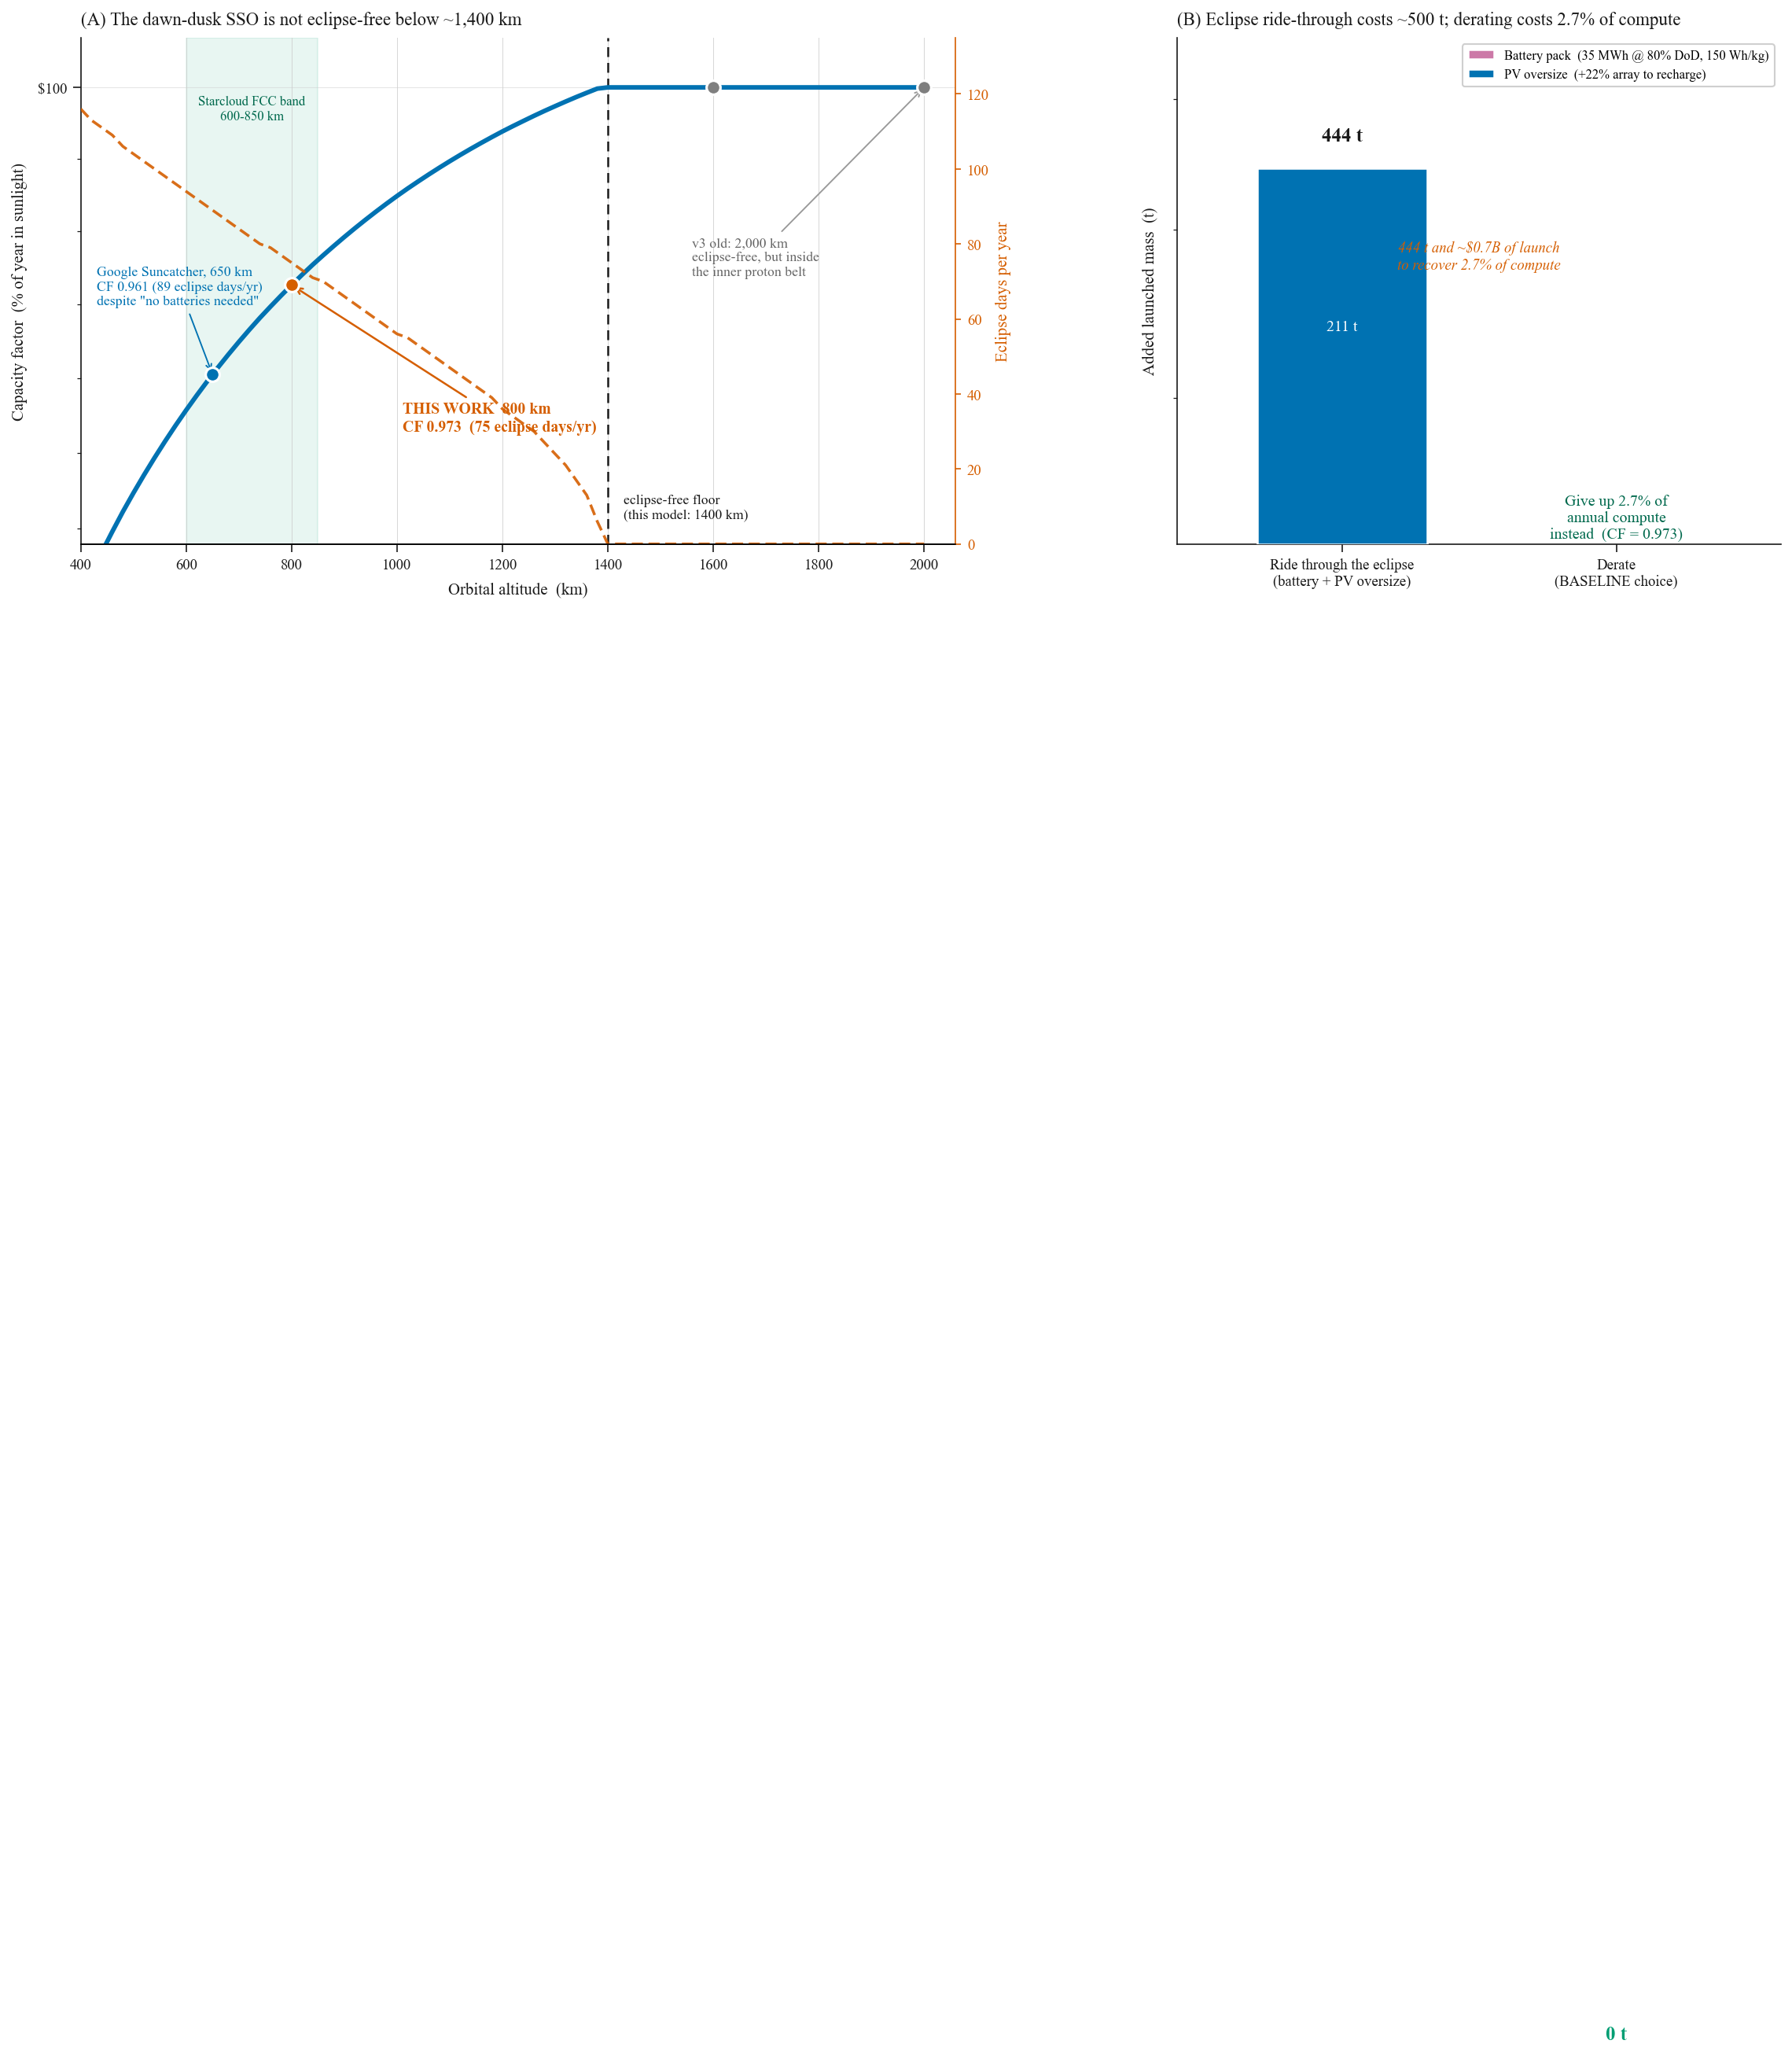

Eclipse-free floor (this model)     : 1,400 km
Ride-through energy @ 800 km      : 28.0 MWh (35.1 MWh installed @ 80% DoD)
  battery mass                      : 234 t
  recharge power -> PV oversize     : 22.3 MW  (+22% array = +211 t)
  TOTAL added mass                  : 444 t  (+15% on a 2,971 t system)
  compute recovered                 : 2.7%
  => BASELINE DERATES. CF = 0.9727, zero battery mass.


In [28]:
# =============================================================================
# FIGURE 0.  Orbit selection:  "eclipse-free dawn-dusk SSO" is FALSE below ~1,400 km
# -----------------------------------------------------------------------------
# (A) Capacity factor and eclipse-season length vs altitude, published ODC
#     concepts annotated. The eclipse-free floor falls out of the model.
# (B) Mass cost of closing the eclipse gap at 800 km (battery + PV oversize)
#     versus simply derating compute. Derating wins by ~500 t, which is WHY the
#     baseline carries no batteries.
# =============================================================================
alts   = np.arange(400, 2001, 20.0)
prof   = [eclipse_profile(float(h)) for h in alts]
cf_a   = np.array([p['capacity_factor'] for p in prof]) * 100
days_a = np.array([p['eclipse_days'] for p in prof])
_free  = alts[days_a == 0]
ALT_ECLIPSE_FREE = float(_free[0]) if len(_free) else float('nan')

fig = plt.figure(figsize=(15.5, 5.8))
fig.patch.set_facecolor(BG)
gs = fig.add_gridspec(1, 2, left=0.055, right=0.985, top=0.88, bottom=0.14,
                      wspace=0.30, width_ratios=[1.45, 1.0])
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])

# ------------------------------------------------------------------- (A) -----
axA.axvspan(600, 850, color='#009E73', alpha=0.09, zorder=0)
axA.plot(alts, cf_a, color=ODC_COLOR, lw=2.8, zorder=5)
axA.axvline(ALT_ECLIPSE_FREE, color=INK, ls=(0, (5, 3)), lw=1.2, zorder=3)
axA.text(ALT_ECLIPSE_FREE + 30, 94.1,
         f'eclipse-free floor\n(this model: {ALT_ECLIPSE_FREE:.0f} km)',
         fontsize=8.5, color=INK, fontfamily=FONT, va='bottom')
axA.text(725, 99.55, 'Starcloud FCC band\n600-850 km', ha='center', fontsize=8,
         color='#00694d', fontfamily=FONT)

for _name, _h, _c in [('Google Suncatcher', 650, '#0072B2'),
                      ('THIS WORK', 800, '#D55E00'),
                      ('Tether paper', 1600, '#7f7f7f'),
                      ('v3 old', 2000, '#7f7f7f')]:
    _p = eclipse_profile(float(_h))
    axA.plot(_h, _p['capacity_factor'] * 100, 'o', ms=8.5, color=_c, zorder=8,
             markeredgecolor=BG, markeredgewidth=1.5)

_g = eclipse_profile(650.0)
axA.annotate(f'Google Suncatcher, 650 km\nCF {_g["capacity_factor"]:.3f} '
             f'({_g["eclipse_days"]} eclipse days/yr)\ndespite "no batteries needed"',
             xy=(650, _g['capacity_factor'] * 100), xytext=(430, 97.0),
             fontsize=8.5, color='#0072B2', fontfamily=FONT,
             arrowprops=dict(arrowstyle='->', color='#0072B2', lw=0.9))
axA.annotate(f'THIS WORK  800 km\nCF {CAPACITY_FACTOR:.3f}  '
             f'({_ORBIT["eclipse_days"]} eclipse days/yr)',
             xy=(800, CAPACITY_FACTOR * 100), xytext=(1010, 95.3),
             fontsize=9.5, color='#D55E00', fontfamily=FONT, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#D55E00', lw=1.2))
axA.annotate('v3 old: 2,000 km\neclipse-free, but inside\nthe inner proton belt',
             xy=(2000, 100.0), xytext=(1560, 97.4), fontsize=8.5, color='#666666',
             fontfamily=FONT, arrowprops=dict(arrowstyle='->', color='#999999', lw=0.9))

axA2 = axA.twinx()
axA2.plot(alts, days_a, color=ACCENT_R, lw=1.7, ls=(0, (4, 2)), alpha=0.9, zorder=2)
axA2.set_ylabel('Eclipse days per year', color=ACCENT_R, fontfamily=FONT, fontsize=10)
axA2.tick_params(axis='y', colors=ACCENT_R, labelsize=9)
axA2.set_ylim(0, 135)
for _s in ['top', 'left']:
    axA2.spines[_s].set_visible(False)
axA2.spines['right'].set_color(ACCENT_R)

style_axes(axA, fig, title='(A) The dawn-dusk SSO is not eclipse-free below ~1,400 km',
           xlabel='Orbital altitude  (km)',
           ylabel='Capacity factor  (% of year in sunlight)',
           xlim=(400, 2060), ylim=(93.8, 100.7))
axA.grid(axis='y', color=GRID, alpha=0.5, lw=0.5)

# ------------------------------------------------------------------- (B) -----
_p    = _ORBIT
_T_h  = _p['period_min'] / 60.0
E_MWh = (Q_COMPUTE / 1e6) * (_p['max_eclipse_min'] / 60.0)   # ride-through energy [MWh]
DOD, ETA_RT, BATT_WH_KG = 0.80, 0.90, 150.0                  # DoD, round-trip eff, pack sp. energy
E_INSTALLED   = E_MWh / DOD
M_BATTERY_T   = E_INSTALLED * 1e6 / BATT_WH_KG / 1000.0
P_RECHARGE_MW = E_MWh / (_T_h * (1 - _p['max_eclipse_frac'])) / ETA_RT
PV_OVERSIZE   = P_RECHARGE_MW / (Q_COMPUTE / 1e6)
M_PV_EXTRA_T  = mb['PV'] / 1000.0 * PV_OVERSIZE
M_RIDE_T      = M_BATTERY_T + M_PV_EXTRA_T
COMPUTE_GAIN  = (1.0 - CAPACITY_FACTOR) * 100                 # % of compute recovered

axB.bar(0, M_BATTERY_T, width=0.62, color='#CC79A7', edgecolor=BG, lw=1.2, zorder=3,
        label=f'Battery pack  ({E_INSTALLED:.0f} MWh @ {DOD*100:.0f}% DoD, {BATT_WH_KG:.0f} Wh/kg)')
axB.bar(0, M_PV_EXTRA_T, bottom=M_BATTERY_T, width=0.62, color='#0072B2', edgecolor=BG,
        lw=1.2, zorder=3, label=f'PV oversize  (+{PV_OVERSIZE*100:.0f}% array to recharge)')
axB.bar(1, 0.0, width=0.62, color='#009E73', edgecolor=BG, lw=1.2, zorder=3)

axB.text(0, M_RIDE_T + 18, f'{M_RIDE_T:,.0f} t', ha='center', va='bottom',
         fontsize=12, fontweight='bold', color=INK, fontfamily=FONT)
axB.text(0, M_BATTERY_T / 2, f'{M_BATTERY_T:,.0f} t', ha='center', va='center',
         fontsize=9.5, color='white', fontfamily=FONT)
axB.text(0, M_BATTERY_T + M_PV_EXTRA_T / 2, f'{M_PV_EXTRA_T:,.0f} t', ha='center',
         va='center', fontsize=9.5, color='white', fontfamily=FONT)
axB.text(1, 18, '0 t', ha='center', va='bottom', fontsize=12, fontweight='bold',
         color='#009E73', fontfamily=FONT)
axB.text(1, M_RIDE_T * 0.55,
         f'Give up {COMPUTE_GAIN:.1f}% of\nannual compute\ninstead  (CF = {CAPACITY_FACTOR:.3f})',
         ha='center', va='center', fontsize=9.5, color='#00694d', fontfamily=FONT)
axB.text(0.5, M_RIDE_T * 0.86,
         f'{M_RIDE_T:,.0f} t and ~${M_PV_EXTRA_T*1000*BASELINE.launch_cost_per_kg/1e9 + M_BATTERY_T*1000*BASELINE.launch_cost_per_kg/1e9:.1f}B of launch\n'
         f'to recover {COMPUTE_GAIN:.1f}% of compute',
         ha='center', va='center', fontsize=9, color=ACCENT_R, fontfamily=FONT, style='italic')

axB.set_xticks([0, 1])
axB.set_xticklabels(['Ride through the eclipse\n(battery + PV oversize)',
                     'Derate\n(BASELINE choice)'], fontfamily=FONT, fontsize=9.5, color=INK)
axB.legend(loc='upper right', frameon=True, framealpha=1.0, edgecolor=GRID,
           facecolor='white', fontsize=8, prop={'family': FONT, 'size': 8})
style_axes(axB, fig, title='(B) Eclipse ride-through costs ~500 t; derating costs 2.7% of compute',
           ylabel='Added launched mass  (t)', xlim=(-0.6, 1.6), ylim=(0, M_RIDE_T * 1.25))
axB.grid(axis='y', color=GRID, alpha=0.5, lw=0.5)
axB.grid(axis='x', alpha=0)

plt.show()

print(f'Eclipse-free floor (this model)     : {ALT_ECLIPSE_FREE:,.0f} km')
print(f'Ride-through energy @ {ORBITAL_ALT_KM:.0f} km      : {E_MWh:.1f} MWh '
      f'({E_INSTALLED:.1f} MWh installed @ {DOD*100:.0f}% DoD)')
print(f'  battery mass                      : {M_BATTERY_T:,.0f} t')
print(f'  recharge power -> PV oversize     : {P_RECHARGE_MW:.1f} MW  (+{PV_OVERSIZE*100:.0f}% array '
      f'= +{M_PV_EXTRA_T:,.0f} t)')
print(f'  TOTAL added mass                  : {M_RIDE_T:,.0f} t  '
      f'(+{M_RIDE_T/(mb["Total"]/1000)*100:.0f}% on a {mb["Total"]/1000:,.0f} t system)')
print(f'  compute recovered                 : {COMPUTE_GAIN:.1f}%')
print(f'  => BASELINE DERATES. CF = {CAPACITY_FACTOR:.4f}, zero battery mass.')

## 5. LCOC calculation

Following Nøland et al. (2024) Eq. 1. Electricity on orbit is free ($\alpha p k t = 0$); OPEX reduces to a single fixed labour line. Annual compute is scaled by the **derived** orbital capacity factor CF = 0.9727 (Section 1e):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma\, k\, t / (1+r)^i} $$

Cost streams:

- **Hardware:** PV + radiator + IT at year 0; IT refreshes at years 5 and 10.
- **Launch:** full system mass at year 0; IT-only mass at each refresh.
- **Data:** per-drop return-mass launch cost only (fixed drop cost taken as negligible).
- **Labour:** fixed on-Earth operations workforce (\$3.75M/yr), applied **identically** to the ODC and the TDC so the comparison is apples-to-apples.

In [29]:
# --- MODEL CELL (v4 fix): read q_compute(s) everywhere, never the raw global ---
# ROOT CAUSE of the false IT-capacity crossing: build_cash_flows read the
# Q_COMPUTE *global* for cost_IT and annual_eflop read it too, while mass_budget
# read the scenario *field* via q_compute(s). Under the capacity sweep those two
# sources diverged, producing a spurious ~1/capacity ODC slope that crossed the
# TDC. Routing EVERY capacity reference through q_compute(s) makes the whole cost
# stack scale linearly, so ODC LCOC flattens to a floor ABOVE the TDC (no cross).

def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]. Reads q_compute(s), not the global."""
    return (q_compute(s) / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV  = mb['A_PV']  * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT  = (q_compute(s) / 1e6) * s.it_cost_per_MW          # <-- was Q_COMPUTE global
    launch_year0   = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT']    * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry]   += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    labor = np.full(LIFETIME_YR, ANNUAL_LABOR_COST)
    return {'hardware': hardware, 'launch': launch, 'data': data, 'labor': labor,
            'total': hardware + launch + data + labor}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s, k_load=CAPACITY_FACTOR))
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost    = (cf['total']     * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
        'Labor':    (cf['labor']    * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

baseline_result = calculate_lcoc(BASELINE)
print(f'2026 baseline ODC LCOC:  ${baseline_result["lcoc"]:.4f}/EFLOP')
print(f'NPV of total cost:       ${baseline_result["npv_cost"]/1e9:.2f}B')
print(f'\nCost breakdown:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

2026 baseline ODC LCOC:  $0.1153/EFLOP
NPV of total cost:       $17.76B

Cost breakdown:
  Hardware   $0.0713/EFLOP   ( 61.8%)
  Launch     $0.0436/EFLOP   ( 37.8%)
  Data       $0.0002/EFLOP   (  0.1%)
  Labor      $0.0002/EFLOP   (  0.2%)


## 6. Terrestrial DC baseline — rebuilt on a shared-IT basis

Nøland et al. (2024) Table 5 gives a **lumped** $c = \$10{,}000$/kW CAPEX with $d = 10\%$ annual O&M, $\alpha = 1.12$ (PUE), $p = \$150$/MWh, $r = 10\%$, $n = 15$ yr, $k = 1$.

**That lumped number cannot be the whole data center.** It is *less than the IT hardware alone* (\$23,000/kW for GB200-class compute), which is the tell that it never included modern accelerators. Using it as-is silently gave the TDC GB200 compute at pre-GB200, GPU-agnostic cost while the ODC paid full GB200 IT capex — a ~2.5× penalty on the ODC that was pure accounting artefact.

The rebuild splits it into two terms:

1. **Shared IT capex** = `it_cost_per_MW`, *identical to the ODC's*, refreshed at years 0, 5, 10 exactly like the ODC and the carbon model.
2. **Terrestrial facility (balance-of-plant) capex**: shell + MEP + power + cooling + land. Nøland's \$10,000/kW is **relabelled** as this facility-only figure.

O&M (`d`) now applies to the **facility only**, because IT replacement is captured explicitly by the refresh. (The old code folded GPU replacement into `d` on the lumped capex, which double-counts once IT is split out.)

| | \$/kW |
|---|---|
| TDC facility (shell + MEP + power + cooling + land) | 10,000 |
| TDC IT (shared with ODC) | 23,000 |
| **TDC fully loaded** | **33,000** |

This reconciles against the independent industry figure of **\$30–40M/MW** for a fully-loaded AI facility (of which more than half is GPUs). The pieces add up, which is the whole point of splitting the lumped number.

**Effect:** TDC 2026 LCOC went from ~\$0.019/EFLOP to **~\$0.049/EFLOP**, and the ODC/TDC ratio from ~6.4× to **~2.5×**. The original Nøland lumped form is retained as `terrestrial_lcoc_noland` **solely** to reproduce the paper's \$1.16/EFLOP citation anchor at γ = 0.1. It is not used for the comparison.

Computed at the **same γ as the ODC** for an apples-to-apples comparison, with the **same** \$3.75M/yr labour line on both sides.

In [30]:
# =============================================================================
# REPLACES: CELL 14  (the `terrestrial_lcoc(...)` function + verification prints)
# CHANGES vs current notebook -- THIS IS THE TDC COST-MODEL REBUILD:
#   - The old single lumped `c_per_kW = $10,000` (which silently delivered GB200
#     compute at pre-GB200, GPU-agnostic cost, while the ODC paid full GB200 IT)
#     is split into TWO terms:
#         (1) a SHARED IT capex = it_cost_per_MW, identical to the ODC, refreshed
#             every IT_REFRESH_YEARS (years 0,5,10) like the ODC and carbon model;
#         (2) a terrestrial FACILITY (balance-of-plant) capex: shell + MEP +
#             power + cooling + land. Noland's $10k/kW is RELABELED as this
#             facility-only figure (it is less than the $23k/kW IT alone, which
#             is the tell that it never included modern IT).
#   - O&M (d) now applies to the FACILITY only, NOT to IT, because IT replacement
#     is captured explicitly by the 5-yr refresh. (The old code folded GPU
#     replacement into d on the lumped capex -> double-counting once IT is split.)
#   - The original Noland lumped form is KEPT as `terrestrial_lcoc_noland(...)`
#     solely to reproduce the paper's $1.16/EFLOP citation anchor at gamma=0.1.
# Requires BASELINE (cell 5) to be defined first.
# =============================================================================

# ---- TDC facility (balance-of-plant) parameters -----------------------------
FACILITY_COST_PER_KW = 10_000.0   # $/kW  shell+MEP+power+cooling+land (Noland 2024 lumped, relabeled facility-only)
FACILITY_OM_FRAC     = 0.10       # frac/yr  O&M on FACILITY capex only (IT refresh is explicit)
IT_REFRESH_YEARS     = 5          # GPU refresh cadence (matches ODC build_cash_flows and carbon model)


def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     it_cost_per_MW:   float = None,                 # SHARED with ODC; defaults to BASELINE
                     facility_per_kW:  float = FACILITY_COST_PER_KW,
                     d_facility:       float = FACILITY_OM_FRAC,
                     alpha_PUE:        float = 1.12,
                     p_per_MWh:        float = 150,
                     r_wacc:           float = 0.10,
                     n_years:          int   = 15,
                     k_load:           float = 1.0,
                     refresh_years:    int   = IT_REFRESH_YEARS,
                     labor_per_kW_yr:  float = ANNUAL_LABOR_COST / (Q_COMPUTE / 1e3)) -> float:
    """Rebuilt terrestrial LCOC in $/EFLOP.

    Decomposed CAPEX = shared IT (refreshed) + terrestrial facility (BoP).
    The shared IT term is identical to the ODC's it_cost_per_MW, so it -- and any
    IT learning rate applied to it -- largely cancels in the ODC/TDC ratio. What
    remains is the real comparison: ODC's PV+radiator+launch vs TDC's facility +
    lifetime grid electricity.
    """
    if it_cost_per_MW is None:
        it_cost_per_MW = BASELINE.it_cost_per_MW          # shared default
    it_per_kW = it_cost_per_MW / 1000.0
    df = np.array([1.0 / (1 + r_wacc)**i for i in range(n_years)])

    # (1) shared IT capex, refreshed every refresh_years (years 0, 5, 10, ...)
    it_cf = np.zeros(n_years)
    for yr in range(0, n_years, refresh_years):
        it_cf[yr] += it_per_kW
    npv_it = (it_cf * df).sum()

    # (2) facility capex (year 0) + facility O&M + electricity + shared labor
    annual_elec  = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_om    = d_facility * facility_per_kW            # O&M on FACILITY only
    annual_labor = labor_per_kW_yr
    npv_facility = facility_per_kW + ((annual_om + annual_elec + annual_labor) * df).sum()

    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    npv_costs      = npv_it + npv_facility
    npv_compute    = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000               # $/PFLOP -> $/EFLOP


def terrestrial_lcoc_noland(gamma_PFLOPS_per_kW: float,
                            c_per_kW: float  = 10_000,
                            d_frac: float    = 0.10,
                            alpha_PUE: float = 1.12,
                            p_per_MWh: float = 150,
                            r_wacc: float    = 0.10,
                            n_years: int     = 15,
                            k_load: float    = 1.0) -> float:
    """ORIGINAL Noland et al. 2024 Eq. 1 lumped form. KEPT ONLY to reproduce the
    paper's reported $1.16/EFLOP citation anchor. Do NOT use for the comparison."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1 / (1 + r_wacc)**i for i in range(n_years)])
    npv_costs   = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000


# --- Citation check: reproduce the paper's number with the ORIGINAL lumped form -
verify = terrestrial_lcoc_noland(0.1)
print(f'Noland citation check @ gamma=0.1 (lumped): ${verify:.3f}/EFLOP   (paper: $1.16)')

# --- Rebuilt TDC at the analysis efficiency ----------------------------------
tdc_baseline = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW)
print(f'\nRebuilt TDC @ gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW: ${tdc_baseline:.4f}/EFLOP')
print(f'  TDC CAPEX = facility ${FACILITY_COST_PER_KW/1000:.0f}k/kW + shared IT '
      f'${BASELINE.it_cost_per_MW/1e6:.0f}k/kW = ${(FACILITY_COST_PER_KW + BASELINE.it_cost_per_MW/1000)/1000:.0f}k/kW total')
print(f'ODC / TDC ratio (2026): {baseline_result["lcoc"]/tdc_baseline:.2f}x')

Noland citation check @ gamma=0.1 (lumped): $1.163/EFLOP   (paper: $1.16)

Rebuilt TDC @ gamma=6.0 PFLOPS/kW: $0.0487/EFLOP
  TDC CAPEX = facility $10k/kW + shared IT $23k/kW = $33k/kW total
ODC / TDC ratio (2026): 2.37x


## 7. Time projection, 2026 → 2045

Each learning-rate scenario is applied to the baseline year over year, producing three trajectories (Optimistic / Baseline / Pessimistic) for both the ODC and the TDC.

**What moves the ratio and what does not:**

| Lever | ODC | TDC | Cancels in the ratio? |
|---|---|---|---|
| γ (compute efficiency) | ✓ | ✓ | **Yes** — same chips. Sets the level, not the gap. |
| IT cost \$/MW | ✓ | ✓ | **Yes** — single shared rate by construction. |
| IT **mass** density kg/MW | ✓ | — | **No.** The TDC launches nothing. This is the genuine ODC lever. |
| Launch cost \$/kg | ✓ | — | **No.** |
| PV cost and efficiency | ✓ | — | **No.** |
| Facility capex \$/kW | — | ✓ | **No.** |
| Electricity price \$/MWh | — | ✓ | **No.** The ODC pays no grid power. |

So the ODC/TDC gap over time is driven by **launch + PV learning (helping the ODC)** against **facility capex decline and electricity price (setting the TDC floor)**. Mass density is the ODC-side optimism lever and matters most early, when launch is still expensive.

In [31]:
# =============================================================================
# REPLACES: CELL 16  (evolve_scenario + terrestrial_evolved + projection loop)
# CHANGES in this revision:
#   - terrestrial_evolved now passes p_per_MWh=lr.elec_price, wiring in the new
#     TDC-only electricity-price lever (opt $100 / base $150 / pess $250).
#   - IT cost declines at the SHARED rate lr.it_cost (= IT_COST_LR, identical in
#     all scenarios) on BOTH sides, so it sets the level but leaves both bands.
#   - IT mass density declines at lr.it_mass_dens (ODC-only, floored). PV eff
#     capped at 0.35.
# Requires cell 14 (terrestrial_lcoc, FACILITY_COST_PER_KW) defined first.
# =============================================================================

# Physical floor on IT mass density [kg/MW]. FLAG: rough guardrail, tune freely.
IT_MASS_DENSITY_FLOOR = 5_000.0


def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Evolve s_base year_offset years forward under learning rates lr.
      - IT $/MW declines at lr.it_cost (= IT_COST_LR, shared/uniform; out of band).
      - IT mass density declines at lr.it_mass_dens (ODC-only; floored).
      - PV BOL efficiency capped at 0.35; radiator areal cost held fixed."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        pv_eff_BOL          = min(0.35, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr.it_cost)**year_offset,     # shared rate
        it_mass_density     = max(IT_MASS_DENSITY_FLOOR,
                                  s_base.it_mass_density * (1 - lr.it_mass_dens)**year_offset),  # ODC-only
        # rad_areal_cost: intentionally unchanged
    )


def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    """Rebuilt TDC projection. Facility capex learns at lr.terr_capex; the shared
    IT term learns at lr.it_cost (same as ODC); electricity price is the scenario
    level lr.elec_price; gamma grows equally. The ODC is unaffected by elec_price
    and terr_capex -- those are the TDC-specific band drivers."""
    gamma_t    = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    facility_t = FACILITY_COST_PER_KW   * (1 - lr.terr_capex)**year_offset
    it_t       = BASELINE.it_cost_per_MW * (1 - lr.it_cost)**year_offset   # shared with ODC
    return terrestrial_lcoc(gamma_t, it_cost_per_MW=it_t,
                            facility_per_kW=facility_t, p_per_MWh=lr.elec_price)


# Project each LR scenario forward
START_YEAR, END_YEAR = 2026, 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

odc_by_lr: Dict[str, np.ndarray] = {}
tdc_by_lr: Dict[str, np.ndarray] = {}

for lr in LR_SCENARIOS:
    odc_vals, tdc_vals = [], []
    for yo in year_offsets:
        ev = evolve_scenario(BASELINE, yo, lr)
        odc_vals.append(calculate_lcoc(ev)['lcoc'])
        tdc_vals.append(terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr))
    odc_by_lr[lr.name] = np.array(odc_vals)
    tdc_by_lr[lr.name] = np.array(tdc_vals)

# Convenience aliases
odc_nom = odc_by_lr['Baseline']
odc_hi  = odc_by_lr['Optimistic']     # lower LCOC = cheaper
odc_lo  = odc_by_lr['Pessimistic']    # higher LCOC = more expensive
tdc_nom = tdc_by_lr['Baseline']
tdc_hi  = tdc_by_lr['Optimistic']
tdc_lo  = tdc_by_lr['Pessimistic']

print(f'{"Year":>6s}  {"ODC Base":>10s}  {"ODC Opt":>10s}  {"ODC Pes":>10s}  '
      f'{"TDC Base":>10s}  {"TDC Opt":>10s}  {"TDC Pes":>10s}  {"ratio":>8s}')
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    print(f'{label:>6s}  ${odc_nom[idx]:>9.4f}  ${odc_hi[idx]:>9.4f}  ${odc_lo[idx]:>9.4f}  '
          f'${tdc_nom[idx]:>9.4f}  ${tdc_hi[idx]:>9.4f}  ${tdc_lo[idx]:>9.4f}  '
          f'{odc_nom[idx]/tdc_nom[idx]:>7.2f}x')

  Year    ODC Base     ODC Opt     ODC Pes    TDC Base     TDC Opt     TDC Pes     ratio
  2026  $   0.1153  $   0.1153  $   0.1153  $   0.0487  $   0.0461  $   0.0539     2.37x
  2030  $   0.0440  $   0.0361  $   0.0548  $   0.0226  $   0.0207  $   0.0260     1.94x
  2035  $   0.0135  $   0.0095  $   0.0219  $   0.0089  $   0.0077  $   0.0108     1.52x
  2040  $   0.0044  $   0.0028  $   0.0088  $   0.0036  $   0.0030  $   0.0047     1.20x
  2045  $   0.0015  $   0.0008  $   0.0036  $   0.0015  $   0.0012  $   0.0021     0.95x


# 8. Life-cycle carbon model (GWP100)

The carbon half mirrors the cost half **exactly**: same geometry, same masses, same refresh cadence, same mission length. The only things it adds are emission factors and the launch vehicle.

## 8.0 Scope and boundaries

| | ODC | TDC |
|---|---|---|
| **Embodied** | PV array, radiator, IT (3 generations) | Core & shell, MEP, IT (3 generations) |
| **Transport** | **Launch** (Starship, bottom-up; see 8c) | *not modelled* (truck/ship freight ≪ 1%) |
| **Operational** | **Zero** (solar power on orbit) | **Grid electricity** × PUE × 15 yr |
| **End of life** | *not modelled* | *not modelled* |

- **Metric:** GWP100, cradle-to-gate for hardware, cradle-to-grave for launch.
- **Functional unit:** 100 MW of IT capacity operated for 15 years. Divided by lifetime compute this gives **LEOC** (kgCO₂e/EFLOP), the carbon twin of LCOC.
- **IT embodied is identical on both sides** — same chips, same PCF, same refresh — so the comparison isolates **launch vs facility + grid**, not chip differences. This is deliberate and is what makes the twin metric honest.
- **Not modelled, and known to matter:** end-of-life and de-orbit; stratospheric water vapour and black carbon from launch (held out of the baseline as a *named sensitivity*, see 8c); atomic-oxygen / UV degradation of the coating; spacecraft bus and battery mass.

## 8.1 Structural asymmetry the reader must understand

The ODC's carbon is **~100% embodied + launch**; the TDC's is **~96% operational** at a 0.40 tCO₂e/MWh grid. That means:

- The comparison is **entirely a function of grid carbon intensity.** On a coal grid the ODC wins on carbon easily; on a French or Icelandic grid it cannot win at any plausible carbon price. Every carbon result in this notebook must be read as a function of grid intensity, which is why Section 9 leads with the **(grid intensity × electricity price) plane** rather than a single number.
- The 96/4 split inverts on clean grids (≈81/19 for a France-equivalent grid; ≈61/39 near zero), consistent with Falk et al. (2025), whose finding that the use phase is ~96% of climate impact for grid-powered AI infrastructure this model reproduces at 0.40 tCO₂e/MWh.

## 8a. ODC embodied carbon

### PV array (the hotspot)

Carbon per m² of array = **cell stack** (per unit *area*) + **ROSA structure** (per unit *mass*):

| Term | Value | Basis |
|---|---|---|
| Ge substrate | ~1,100 kgCO₂e/m² (**~78%**) | Swart et al. (2011), *Resour. Conserv. Recycl.* 55, 1119 — LCI supplied by Umicore. 100 mm wafer, 150 µm, 6.16 g, 216 MJ CED (122–253 MJ across fab grids), ~75% of CED is electricity. **127 wafers/m²** → 27.5 GJ/m², converted at ~0.40 kgCO₂e/kWh. |
| MOVPE epitaxy + III-V precursors | ~220 kgCO₂e/m² (~15%) | Mohr et al. (2007), *Prog. Photovolt.* 15, 163 — MOVPE growth is ~⅔ of module CED; ~8.6 GJ/m² total → ~5.7 GJ/m² epitaxy. |
| Metallisation, ARC, processing | ~60 kgCO₂e/m² (~4%) | Scaled from the non-growth processing share in Mohr et al. (2007). |
| Coverglass + interconnect | ~40 kgCO₂e/m² (~3%) | Engineering estimate (~100 µm coverglass + adhesive + Ag interconnect). |
| **Cell-stack subtotal** | **~1,400 kgCO₂e/m²** | |
| Polyimide blanket + harness | 0.94 kg/m² × 12 = **11** | ROSA blanket substrate |
| CFRP booms + roll-out mechanism | 0.80 kg/m² × 30 = **24** | CFRP CI range 25–40 kgCO₂e/kg; even a 2× error moves the total <2% |
| **PV array total** | **~1,435 kgCO₂e/m²** | |

**There is no published cradle-to-gate LCA of a 1-sun Ge-substrate space triple-junction cell.** This figure is synthesised bottom-up, with the dominant term resting on a single primary source (Swart 2011). Published *concentrator* space-PV LCAs report deceptively low values (16.4–18.4 gCO₂e/kWh for 4J HCPV, Payet & Greffe 2019) because optical concentration lets one wafer cover hundreds of times its area. **A 1-sun orbital array receives no such benefit, so the full per-m² substrate burden applies.** Payet & Greffe independently identify germanium as the dominant driver of their resource-depletion impact, corroborating the substrate-dominated result.

For scale: terrestrial c-Si modules are ~420–810 kgCO₂e/kWp (Reichel et al. 2022); the space TJ cell is **several times higher per kWp**.

**Sensitivity (the big one):** an **IMM thin-cell ROSA** discards the Ge wafer → PV embodied drops to **~300–400 kgCO₂e/m²**, roughly 4×. Carried as a named fork.

### Radiator

| Term | Value | Basis |
|---|---|---|
| Aluminium (5.0 kg/m²) | 5.0 × 17.3 = **86.5 kgCO₂e/m²** (**~97%**) | IAI (2024) global-average primary Al **14.8 kgCO₂e/kg** (cradle-to-gate range 4.5–22; EU primary ~6.6 per European Aluminium) + **2.5 kgCO₂e/kg** semi-fab adder |
| BaSO₄-acrylic coating (1.25 kg/m²) | 1.25 × 1.9 = **2.4 kgCO₂e/m²** (~3%) | 85.4 wt% BaSO₄ (ground barite 0.1–0.3; precipitated grades higher — central 1.0, benchmarked against PCC ~0.85 per Joo et al. 2024) + 14.6 wt% acrylic resin (~7.0) |
| **Radiator total** | **~89 kgCO₂e/m²** | |

The range is driven **almost entirely by aluminium smelter grid intensity** (clean hydro/EU vs coal-heavy). The BaSO₄ factor has essentially no leverage. No dedicated BaSO₄-paint LCA exists; the coating is carbon-trivial either way, so this uncertainty does not affect the result.

**Context:** the radiator is ~16× lighter than the PV cell per m² (89 vs 1,435 kgCO₂e/m²) and far lighter per kg (~14 vs ~410 kgCO₂e/kg). **The PV array is the embodied hotspot of the spacecraft; the radiator is a secondary, aluminium-dominated term.**

### IT (shared with the TDC)

| Parameter | Value | Units | Source |
|---|---|---|---|
| Node power | 10.4 | kW/node | sets node count from capacity |
| GPU baseboard PCF | 2,274 | kgCO₂e/node | NVIDIA HGX B200 product carbon footprint |
| Host server PCF | 1,300 | kgCO₂e/node | HGX B200 PCF / server LCA |
| Refresh interval | 5 | yr | 3 generations over a 15-yr mission (years 0, 5, 10) |

Methodology follows Falk et al. (2025), *More than Carbon* (arXiv:2509.00093); per-node figures from the NVIDIA HGX B200 PCF summary (reported embodied intensity ~0.50 gCO₂e per FLOPS, 24% below H100).

## 8b. TDC carbon

TDC life-cycle carbon = **operational (grid)** + **facility embodied (core & shell + MEP)** + **IT embodied (refreshed)**. The facility and operational assumptions trace to one anchor study:

> **Alissa, H., Nick, T., Raniwala, A., et al. (2025).** *Using life cycle assessment to drive innovation for sustainable cool clouds.* **Nature 641**, 331–338. doi:10.1038/s41586-025-08832-3

### Operational (grid)

Annual operational carbon = `it_capacity_mw` × `pue` × `load_factor` × 8760 h × `grid_intensity`, decayed by `grid_decarb` per year.

| Parameter | Variable | Value | Units | Source |
|---|---|---|---|---|
| Power usage effectiveness | `pue` | 1.12 | — | Alissa 2025 (Microsoft reports PUE as low as 1.12) |
| Load factor | `load_factor` | 1.0 | — | model assumption — 100% utilisation, matched to the ODC |
| **Grid carbon intensity** | `grid_intensity` | **0.40** | tCO₂e/MWh | **baseline; see note (a)** |
| Grid decarbonisation | `grid_decarb` | 0.0 | /yr | flat grid by default; IEA WEO scenarios applied in the projection figure |

**(a)** 0.40 tCO₂e/MWh (≡ 400 gCO₂/kWh) is a round baseline near the global / US-average grid. Reference points used in the figures: **US average ~0.37**, **France ~0.05**, **Iceland ~0.028**, **coal Appalachia ~0.60+**. Because TDC operational carbon scales **linearly** with this value and it is ~96% of the TDC total, **grid intensity is the single dominant parameter of the entire carbon comparison.** *(Open item before submission: pin this to a specific citable source — IEA, Ember, or EPA eGRID.)*

### Facility embodied

Floor area = `it_capacity_mw` × 1000 / `power_density_kw_m2`; embodied = area × intensity.

| Parameter | Variable | Value | Units | Source |
|---|---|---|---|---|
| Power density | `power_density_kw_m2` | 2.0 | kW/m² | facility design assumption — see note (b) |
| Core & shell intensity | `shell_kgco2e_m2` | 650 | kgCO₂e/m² | Alissa 2025 (facility LCA) |
| MEP intensity | `mep_kgco2e_m2` | 400 | kgCO₂e/m² | Alissa 2025 (facility LCA) |

**(b)** A stated W/m² can mean an isolated rack or the whole building, and extrapolating rack density to full floor area overstates it by 2–4×. The Alissa per-m² factors are over **gross building area**, so they must be paired with a **building** density, not a rack density. Peer-reviewed AI-era US data-center work (Siddik/Shehabi/Marston) finds ~92 W/ft² ≈ **1.0 kW/m²** whole-building, with the literature average ~1.6 kW/m². **The 2.0 kW/m² used here is on the high side**; dropping to 1.0 doubles floor area and roughly doubles building/MEP embodied — but since those are a small slice of the TDC total (which is 96% operational), it barely moves the headline. *(Open item: confirm whether 2.0 and the 650/400 factors all come from Alissa 2025 or a mix.)*

## 8c. Launch carbon — bottom-up Starship model

Launch is **not** a market number; it is built from physics in four non-overlapping terms and divided by delivered payload. This is the deliberate methodological counterpart to the *price*-based \$1,500/kg in the cost model (see the note at the end).

$$ C_{\text{launch}} = \underbrace{\frac{E_{\text{SH}}}{N_{\text{SH}}} + \frac{E_{\text{SS}}}{N_{\text{SS}}}}_{\text{(1) vehicle, amortised}} + \underbrace{c_{\text{prop}} \cdot m_{\text{prop}}}_{\text{(2) propellant production}} + \underbrace{C_{\text{comb}}}_{\text{(3) combustion}} + \underbrace{C_{\text{reentry}}}_{\text{(4) re-entry NO}_x} $$

| Term | Model | Value | Source |
|---|---|---|---|
| **(1) Vehicle embodied**, amortised over reuse | Two-bin material model: stainless structure at CI = 6 kgCO₂e/kg, Ni-superalloy engines at CI = 40 kgCO₂e/kg. Super Heavy 275 t dry (33 Raptors × 1.6 t), Starship 120 t dry (6 Raptors). Amortised over **N_SH = 100**, **N_SS = 25** flights. | ~**120 t**/launch | Engine CI = stack of ingot (~14) + gas atomisation (~5–25) + AM/machining energy, anchored on Torres-Carrillo's Inconel 718 SLM LCA and a Dartmouth/Cambridge AM review. **Not** a linear mass extrapolation from Falcon 9. |
| **(2) Propellant production** | 4,600 t methalox (O/F = 3.6) at **2.5 kgCO₂e/kg** | ~**11,500 t** | Miraux et al. (2022) — 2–2.7 kgCO₂e/kg for LOx + LCH₄ production |
| **(3) Combustion** | Flat per-launch figure, **inclusive of static fires and landing burns** | **4,646 t** | FAA / NASA Kennedy Environmental Assessment |
| **(4) Re-entry NO_x** | 13.2 kgCO₂e per kg of **non-reusable** re-entering mass | **0** (baseline) | Dirty Bits model. **Off by default:** the vehicle is reused, not expended, so there is no ablated mass per delivery. |
| **Total** | | **~16,200 tCO₂e/launch** | **Validates against Miraux (2022)'s published ~16,700 t.** |

**(1) and (2) are separate, non-overlapping terms.** Propellant *production* (making the LOx and LCH₄) and *combustion* (burning it) are distinct physical processes and are counted once each.

### The three-paper ladder (why the literature disagrees by 100×)

| Study | Per-launch | What it counts |
|---|---|---|
| Dirty Bits | ~3,200 t | **combustion only** |
| **Miraux (2022)** | **~16,700 t** | combustion + propellant production + vehicle, **aviation-proxy** characterisation factors |
| Dominguez Calabuig | ~**megatons** | same physics, but a **stratospheric** characterisation factor for high-altitude H₂O |

**The gap between Miraux and Dominguez is entirely one choice: the characterisation factor for high-altitude water vapour.** Methalox combustion is water-rich, and water injected into the stratosphere is a far more potent forcer than the same water in the troposphere. GWP-100 does not natively handle this, and the literature has not converged.

**Our baseline follows Miraux** (aviation-proxy CFs, `ODC_FORCING_MULT = 1.0`). **Stratospheric water vapour and black carbon are held out of the baseline as named sensitivity functions**, not silently omitted. A multiplier on ODC launch forcing is exposed in the projection figure so a reviewer can see the Dominguez branch directly. **If the stratospheric CF is right, the ODC's carbon case collapses**, and this notebook says so rather than hiding it.

### Payload and launch count

| Parameter | Value | Note |
|---|---|---|
| Payload to orbit | **100 t** | **Optimistic assumption, explicitly flagged.** 100 t is the *reference LEO* figure (~200–400 km). Reaching an 800 km SSO costs additional ΔV, so real deliverable payload is lower and the launch count (and launch carbon) is a **lower bound**. Carried as-is by decision; a payload derate would scale launch carbon roughly linearly. |
| Initial launches | ⌈total mass / 100 t⌉ | full system: PV + radiator + IT |
| Refresh launches | ⌈IT mass / 100 t⌉ × 2 | IT only, at years 5 and 10 |

### Why launch **carbon** is bottom-up while launch **cost** is a market price

This asymmetry is deliberate and defensible:

- **Carbon has no market.** There is no price for a tonne of launch CO₂e, so the only way to get a number is to build it from physics.
- **Cost does have a market**, and LCOC is a *cost-to-the-buyer* metric. An ODC operator does not pay SpaceX's marginal cost; it pays SpaceX's **price**. The TDC side is price-based throughout: \$150/MWh is a market electricity price, not the bottom-up cost of generating a MWh; \$23M/MW is NVIDIA's price, not TSMC's marginal cost. **A bottom-up launch cost paired with a price-based TDC would be the *inconsistent* choice.**
- Where a bottom-up cost genuinely earns its keep is as the **floor of the learning curve**. Propellant (~4,600 t at ~\$0.15–0.25/kg ≈ \$0.7–1.2M) plus amortised vehicle plus refurb/ops lands near **\$5–10M per launch ≈ \$50–100/kg** at full reuse — 15–30× below today's \$1,500/kg price. That gap *is* margin plus development amortisation plus low flight rate, and it is exactly what the learning curve walks down. **The launch-cost sweep in Combined Figure 2 spans \$50–5,000/kg, so both regimes are visible.**

In [32]:
# =============================================================================
# 8. LIFE-CYCLE CARBON MODEL (GWP100)
# -----------------------------------------------------------------------------
# CarbonScenario carries ONLY (a) emission factors, (b) TDC grid/facility params,
# (c) the Starship launch vehicle. Every GEOMETRY / MASS / THERMAL field is
# COPIED FROM `BASELINE` at construction time, so the two halves of the model
# cannot drift apart. An assertion at the bottom proves it.
#
# Sources: Alissa et al. 2025 Nature 641:331 (facility LCA); Falk et al. 2025 +
# NVIDIA HGX B200 PCF (IT embodied); Miraux 2022 + FAA/NASA KSC EA (Starship);
# IAI 2023 (aluminium); Swart 2011 + Mohr 2007 (PV); Li/Ruan 2021 (BaSO4 coat).
# =============================================================================
CAPACITY_MW = Q_COMPUTE / 1e6
FOOTBALL_M2 = 5350.0          # human-scale print helper
os.makedirs('carbon_figs', exist_ok=True)


@dataclass
class CarbonScenario:
    # ---- capacity / mission (copied from the architecture constants) ----------
    it_capacity_mw:   float = CAPACITY_MW
    mission_years:    int   = LIFETIME_YR
    it_refresh_years: int   = REFRESH_INTERVAL

    # ---- GEOMETRY / THERMAL: copied from BASELINE, never typed twice ----------
    pv_eff_BOL:      float = BASELINE.pv_eff_BOL
    pv_derating:     float = BASELINE.pv_derating
    pv_areal_mass:   float = BASELINE.pv_areal_mass
    T_rad_C:         float = BASELINE.T_rad_C
    T_PV_C:          float = BASELINE.T_PV_C
    L_rad:           float = BASELINE.L_rad
    eps_IR:          float = BASELINE.eps_IR
    eps_PV_back:     float = BASELINE.eps_PV_back
    alpha_solar_rad: float = BASELINE.alpha_solar_rad
    F_earth:         float = BASELINE.F_earth
    rad_areal_mass:  float = BASELINE.rad_areal_mass
    it_mass_density: float = BASELINE.it_mass_density

    # ---- EMISSION FACTORS (the carbon model's own inputs) ---------------------
    pv_kgco2e_m2:  float = PV_KGCO2E_M2    # 1,435 = 1,400 cells + 35 ROSA structure
    rad_kgco2e_m2: float = RAD_KGCO2E_M2   # ~89   = 5.0 Al x 17.3 + 1.25 coat x 1.9

    # ---- IT embodied (shared ODC/TDC: apples-to-apples) -----------------------
    node_power_kw:        float = 10.4
    gpu_baseboard_kgco2e: float = 2274.0   # NVIDIA HGX B200 PCF
    host_server_kgco2e:   float = 1300.0   # HGX B200 PCF / server LCA

    # ---- TDC facility / operation --------------------------------------------
    pue:                 float = 1.12                  # Alissa 2025
    load_factor:         float = 1.0
    grid_intensity:      float = GRID_INTENSITY_2026   # tCO2e/MWh == kgCO2e/kWh
    grid_decarb:         float = 0.0
    power_density_kw_m2: float = 2.0
    shell_kgco2e_m2:     float = 650.0                 # Alissa 2025
    mep_kgco2e_m2:       float = 400.0                 # Alissa 2025

    # ---- ODC launch vehicle (Starship; Miraux 2022 + FAA EA) ------------------
    sh_dry_t:        float = 275.0
    ss_dry_t:        float = 120.0
    n_raptor_sh:     int   = 33
    n_raptor_ss:     int   = 6
    raptor_mass_t:   float = 1.6
    propellant_t:    float = 4600.0
    o_f_ratio:       float = 3.6
    payload_cap_t:   float = 100.0     # payload to the 800 km SSO (see caveat in markdown)
    n_sh_reuse:      float = 100.0
    n_ss_reuse:      float = 25.0
    ci_steel:        float = 6.0       # kgCO2e/kg stainless 304L
    ci_engine:       float = 40.0      # kgCO2e/kg Ni-superalloy (ingot + atomisation + AM)
    ci_prop_prod:    float = 2.5       # kgCO2e/kg methalox production (Miraux 2022)
    combustion_ea_t: float = 4646.0    # tCO2e/launch (FAA/NASA KSC EA; ascent+tests+landing)
    include_reentry: bool  = False     # reused vehicle -> ~0 per delivery


# ================================================================ IT helpers ==
def it_quantities(s) -> dict:
    nodes = s.it_capacity_mw * 1000.0 / s.node_power_kw
    gens  = math.ceil(s.mission_years / s.it_refresh_years)
    per_gen_t = nodes * (s.gpu_baseboard_kgco2e + s.host_server_kgco2e) / 1000.0
    return {'nodes': nodes, 'generations': gens,
            'per_gen_t': per_gen_t, 'all_gens_t': per_gen_t * gens}


# =================================================================== TDC model ==
def tdc_carbon(s) -> dict:
    it   = it_quantities(s)
    area = s.it_capacity_mw * 1000.0 / s.power_density_kw_m2
    shell = area * s.shell_kgco2e_m2 / 1000.0
    mep   = area * s.mep_kgco2e_m2   / 1000.0

    yrs = list(range(s.mission_years))
    emb = [0.0] * s.mission_years
    op  = [0.0] * s.mission_years
    emb[0] += shell + mep
    for g in range(it['generations']):
        yr = g * s.it_refresh_years
        if yr < s.mission_years:
            emb[yr] += it['per_gen_t']
    annual_mwh = s.it_capacity_mw * s.pue * s.load_factor * 8760.0
    for y in yrs:
        op[y] = annual_mwh * s.grid_intensity * (1 - s.grid_decarb) ** y

    emb_total, op_total = sum(emb), sum(op)
    return {
        'breakdown': {'IT (all gens)': it['all_gens_t'],
                      'Core & shell': shell, 'MEP': mep},
        'embodied_total': emb_total, 'operational_total': op_total,
        'total': emb_total + op_total, 'floor_area_m2': area,
        'profile': {'years': yrs, 'embodied_spike': emb, 'operational': op,
                    'cum_embodied': np.cumsum(emb).tolist(),
                    'cum_operational': np.cumsum(op).tolist(),
                    'cum_total': np.cumsum(np.array(emb) + np.array(op)).tolist()},
    }


# =================================================================== ODC model ==
def odc_per_launch(s) -> dict:
    """Per-launch carbon for a REUSED Starship delivery [tCO2e].
    Four physical terms (see markdown 8c):
      (1) vehicle embodied, amortised over reuse
      (2) propellant PRODUCTION
      (3) COMBUSTION (ascent + static fires + landing burns)
      (4) re-entry NOx  [off by default: the vehicle is reused, not expended]
    Validates against Miraux (2022) ~16,700 tCO2e/launch."""
    eng_sh = s.n_raptor_sh * s.raptor_mass_t
    eng_ss = s.n_raptor_ss * s.raptor_mass_t
    emb_sh = (s.sh_dry_t - eng_sh) * s.ci_steel + eng_sh * s.ci_engine
    emb_ss = (s.ss_dry_t - eng_ss) * s.ci_steel + eng_ss * s.ci_engine
    vehicle = emb_sh / s.n_sh_reuse + emb_ss / s.n_ss_reuse
    prop = s.ci_prop_prod * s.propellant_t
    comb = s.combustion_ea_t
    terms = {'Vehicle (amortized)': vehicle,
             'Propellant production': prop,
             'Combustion': comb}
    if s.include_reentry:
        terms['Re-entry'] = 13.2 * s.payload_cap_t
    detail = {
        'sh_struct': (s.sh_dry_t - eng_sh) * s.ci_steel / s.n_sh_reuse,
        'sh_eng':    eng_sh * s.ci_engine / s.n_sh_reuse,
        'ss_struct': (s.ss_dry_t - eng_ss) * s.ci_steel / s.n_ss_reuse,
        'ss_eng':    eng_ss * s.ci_engine / s.n_ss_reuse,
        'lox': prop * 0.5, 'methane': prop * 0.5,
    }
    return {'terms': terms, 'per_launch_t': sum(terms.values()), 'detail': detail}


def odc_hardware_embodied(s) -> dict:
    it = it_quantities(s)
    return {'IT (all gens)': it['all_gens_t'],
            'PV array':      size_pv_array(s) * s.pv_kgco2e_m2  / 1000.0,
            'Radiator':      size_radiator(s) * s.rad_kgco2e_m2 / 1000.0}


def odc_carbon(s) -> dict:
    it = it_quantities(s)
    mb = mass_budget(s)                 # <-- the SHARED sizing function
    pl = odc_per_launch(s)
    per_launch = pl['per_launch_t']

    it_mass_t = mb['IT'] / 1000.0
    cap = s.payload_cap_t
    n_init           = math.ceil(mb['Total'] / 1000.0 / cap)
    n_refresh_each   = math.ceil(it_mass_t / cap)
    n_refresh_events = it['generations'] - 1
    n_launches = n_init + n_refresh_each * n_refresh_events

    launch_initial = n_init * per_launch
    launch_refresh = n_refresh_each * n_refresh_events * per_launch

    emb = odc_hardware_embodied(s)
    emb_total = sum(emb.values())

    yrs = list(range(s.mission_years))
    emb_spike = [0.0] * s.mission_years
    lau_spike = [0.0] * s.mission_years
    emb_spike[0] += emb['PV array'] + emb['Radiator']
    lau_spike[0] += launch_initial
    for g in range(it['generations']):
        yr = g * s.it_refresh_years
        if yr < s.mission_years:
            emb_spike[yr] += it['per_gen_t']
            if g > 0:
                lau_spike[yr] += n_refresh_each * per_launch

    return {
        'breakdown': emb,
        'launch_initial': launch_initial, 'launch_refresh': launch_refresh,
        'launch_total': launch_initial + launch_refresh,
        'embodied_total': emb_total,
        'total': launch_initial + launch_refresh + emb_total,
        'n_launches': n_launches, 'n_init': n_init,
        'per_launch_t': per_launch, 'per_launch_detail': pl,
        'mass_budget': mb,
        'profile': {'years': yrs, 'embodied_spike': emb_spike, 'launch_spike': lau_spike,
                    'cum_total': np.cumsum(np.array(emb_spike) + np.array(lau_spike)).tolist()},
    }


# ==================================================================== RESULTS ==
carbon_scenario   = CarbonScenario()
odc_carbon_result = odc_carbon(carbon_scenario)
tdc_carbon_result = tdc_carbon(carbon_scenario)

# ---- CONSISTENCY GATE: the two model halves MUST agree on geometry and mass ---
_mb_fin = mass_budget(BASELINE)
_mb_car = mass_budget(carbon_scenario)
for _k in ['A_PV', 'A_rad', 'PV', 'Radiator', 'IT', 'Total']:
    assert abs(_mb_fin[_k] - _mb_car[_k]) < 1e-6, (
        f'MODEL DRIFT in {_k}: financial={_mb_fin[_k]:.6f} vs carbon={_mb_car[_k]:.6f}')
print('CONSISTENCY GATE PASSED: financial and carbon mass budgets are identical.\n')

_o, _t = odc_carbon_result, tdc_carbon_result
print(f'Per-launch carbon         : {_o["per_launch_t"]:>10,.0f} tCO2e   '
      f'(Miraux 2022 reports ~16,700)')
print(f'Launches (initial/total)  : {_o["n_init"]:>10.0f} / {_o["n_launches"]:.0f}\n')
print(f'{"":24s} {"ODC":>14s} {"TDC":>14s}')
print(f'{"Embodied  [tCO2e]":24s} {_o["embodied_total"]:>14,.0f} {_t["embodied_total"]:>14,.0f}')
print(f'{"Launch    [tCO2e]":24s} {_o["launch_total"]:>14,.0f} {0:>14,.0f}')
print(f'{"Operational [tCO2e]":24s} {0:>14,.0f} {_t["operational_total"]:>14,.0f}')
print(f'{"TOTAL     [tCO2e]":24s} {_o["total"]:>14,.0f} {_t["total"]:>14,.0f}')
print(f'{"ODC / TDC ratio":24s} {_o["total"]/_t["total"]:>14.2f}x')
print(f'\nODC launch share of total : {_o["launch_total"]/_o["total"]*100:.1f}%')
print(f'TDC grid share of total   : {_t["operational_total"]/_t["total"]*100:.1f}%  '
      f'(at {carbon_scenario.grid_intensity:.2f} tCO2e/MWh)')

CONSISTENCY GATE PASSED: financial and carbon mass budgets are identical.

Per-launch carbon         :     16,222 tCO2e   (Miraux 2022 reports ~16,700)
Launches (initial/total)  :         30 / 60

                                    ODC            TDC
Embodied  [tCO2e]               498,279        155,596
Launch    [tCO2e]               973,338              0
Operational [tCO2e]                   0      5,886,720
TOTAL     [tCO2e]             1,471,618      6,042,316
ODC / TDC ratio                    0.24x

ODC launch share of total : 66.1%
TDC grid share of total   : 97.4%  (at 0.40 tCO2e/MWh)


Verification: F_perp_adjacent(1,1) = 0.20004 (expect 0.20004)

CARBON MODEL  -  100 MW IT, 15 yr mission, grid 0.40 tCO2e/MWh

PHYSICAL SIZING
  PV array :      270,130 m^2  (50.5 football fields)
  Geometry: L=520 m, H=259.9 m, h=0.500, W=161.7 m (w=0.3112)
  F_PV (per face, both equal): 0.3065
  Heat balance (W/m^2 of one-face area), F_earth = 0.2705:
    Gross emission (2-sided): + 1493.8
    PV re-absorbed (2 faces): -  237.7
    Earth IR:                 -   60.8
    Earth albedo:             -   5.63
    Net cooling:              + 1189.7
  Radiator :       84,058 m^2  (15.7 football fields)
  Mass budget (t): PV 945, Radiator 525, IT 1,500, Total 2,971

TDC CARBON (tCO2e)
  IT (all gens)   :      103,096
  Core & shell    :       32,500
  MEP             :       20,000
  Embodied total  :      155,596
  Operational     :    5,886,720
  TOTAL           :    6,042,316  (6.04 Mt)

ODC CARBON (tCO2e)
  Launches: 60  @ 16,222 t/launch
  Launch initial  :      486,669
  Launch refresh

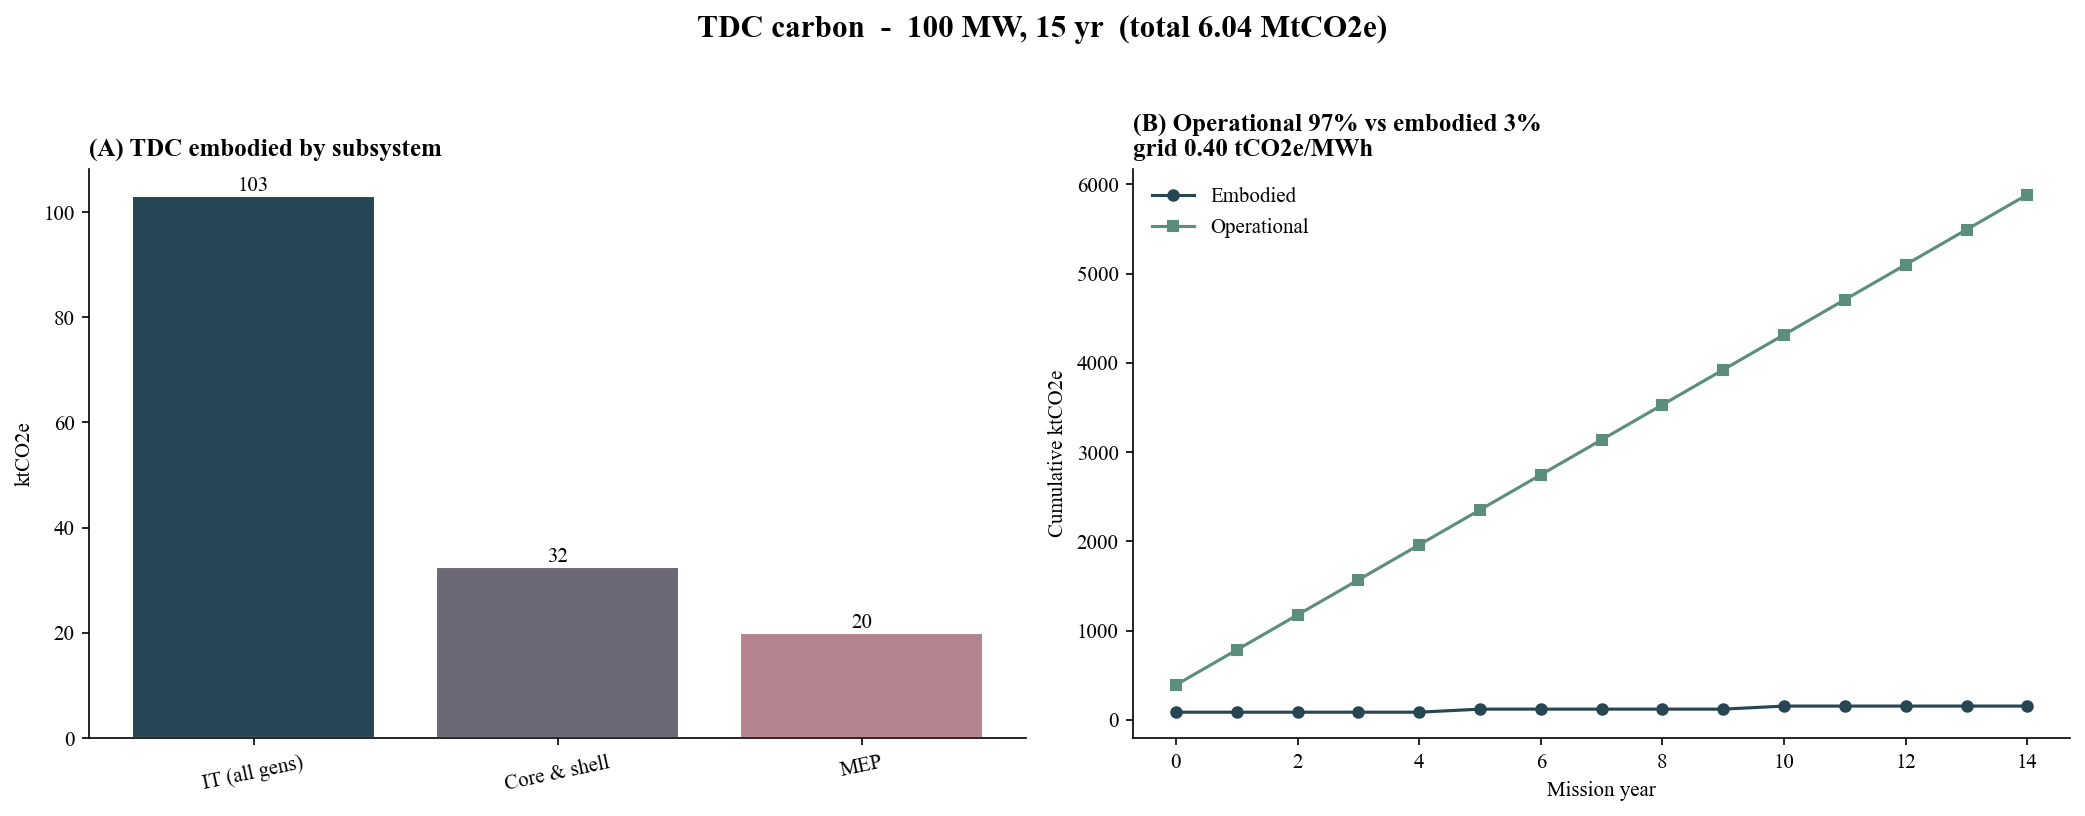

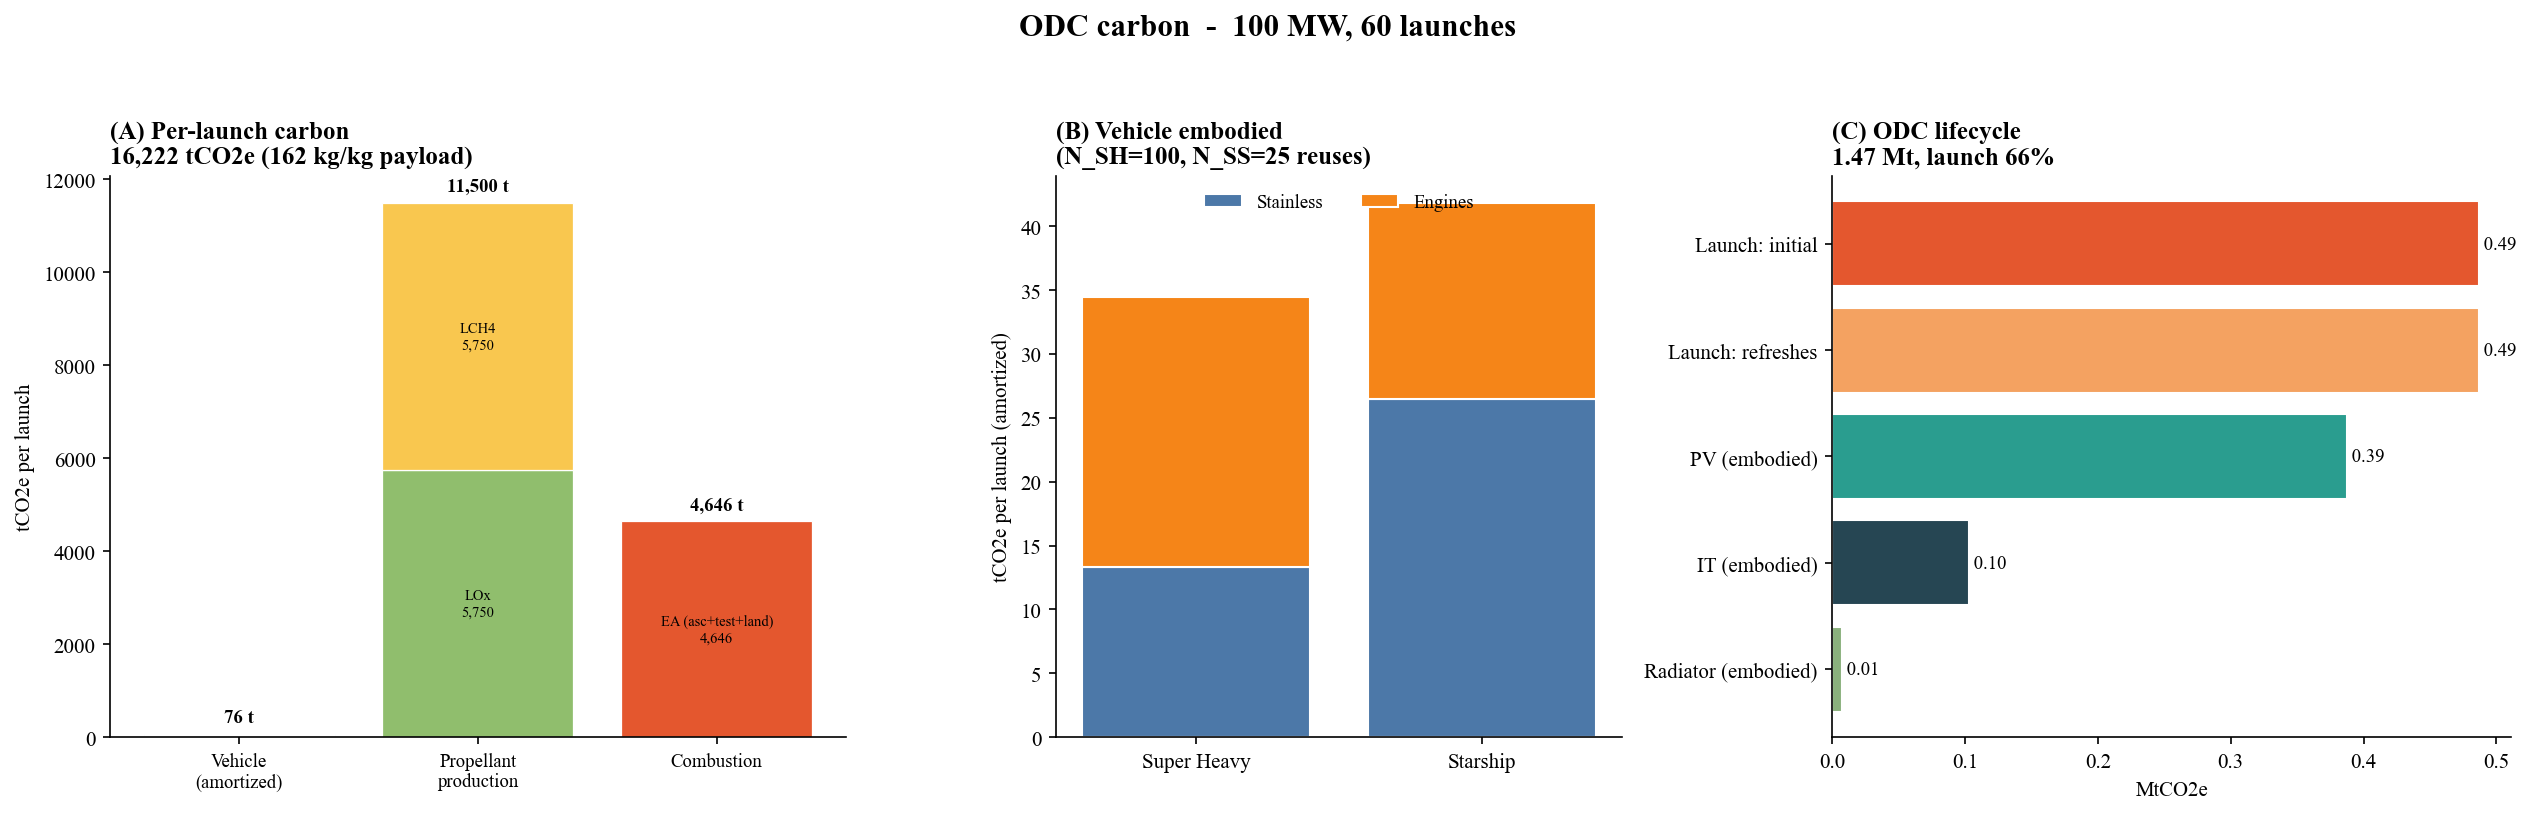

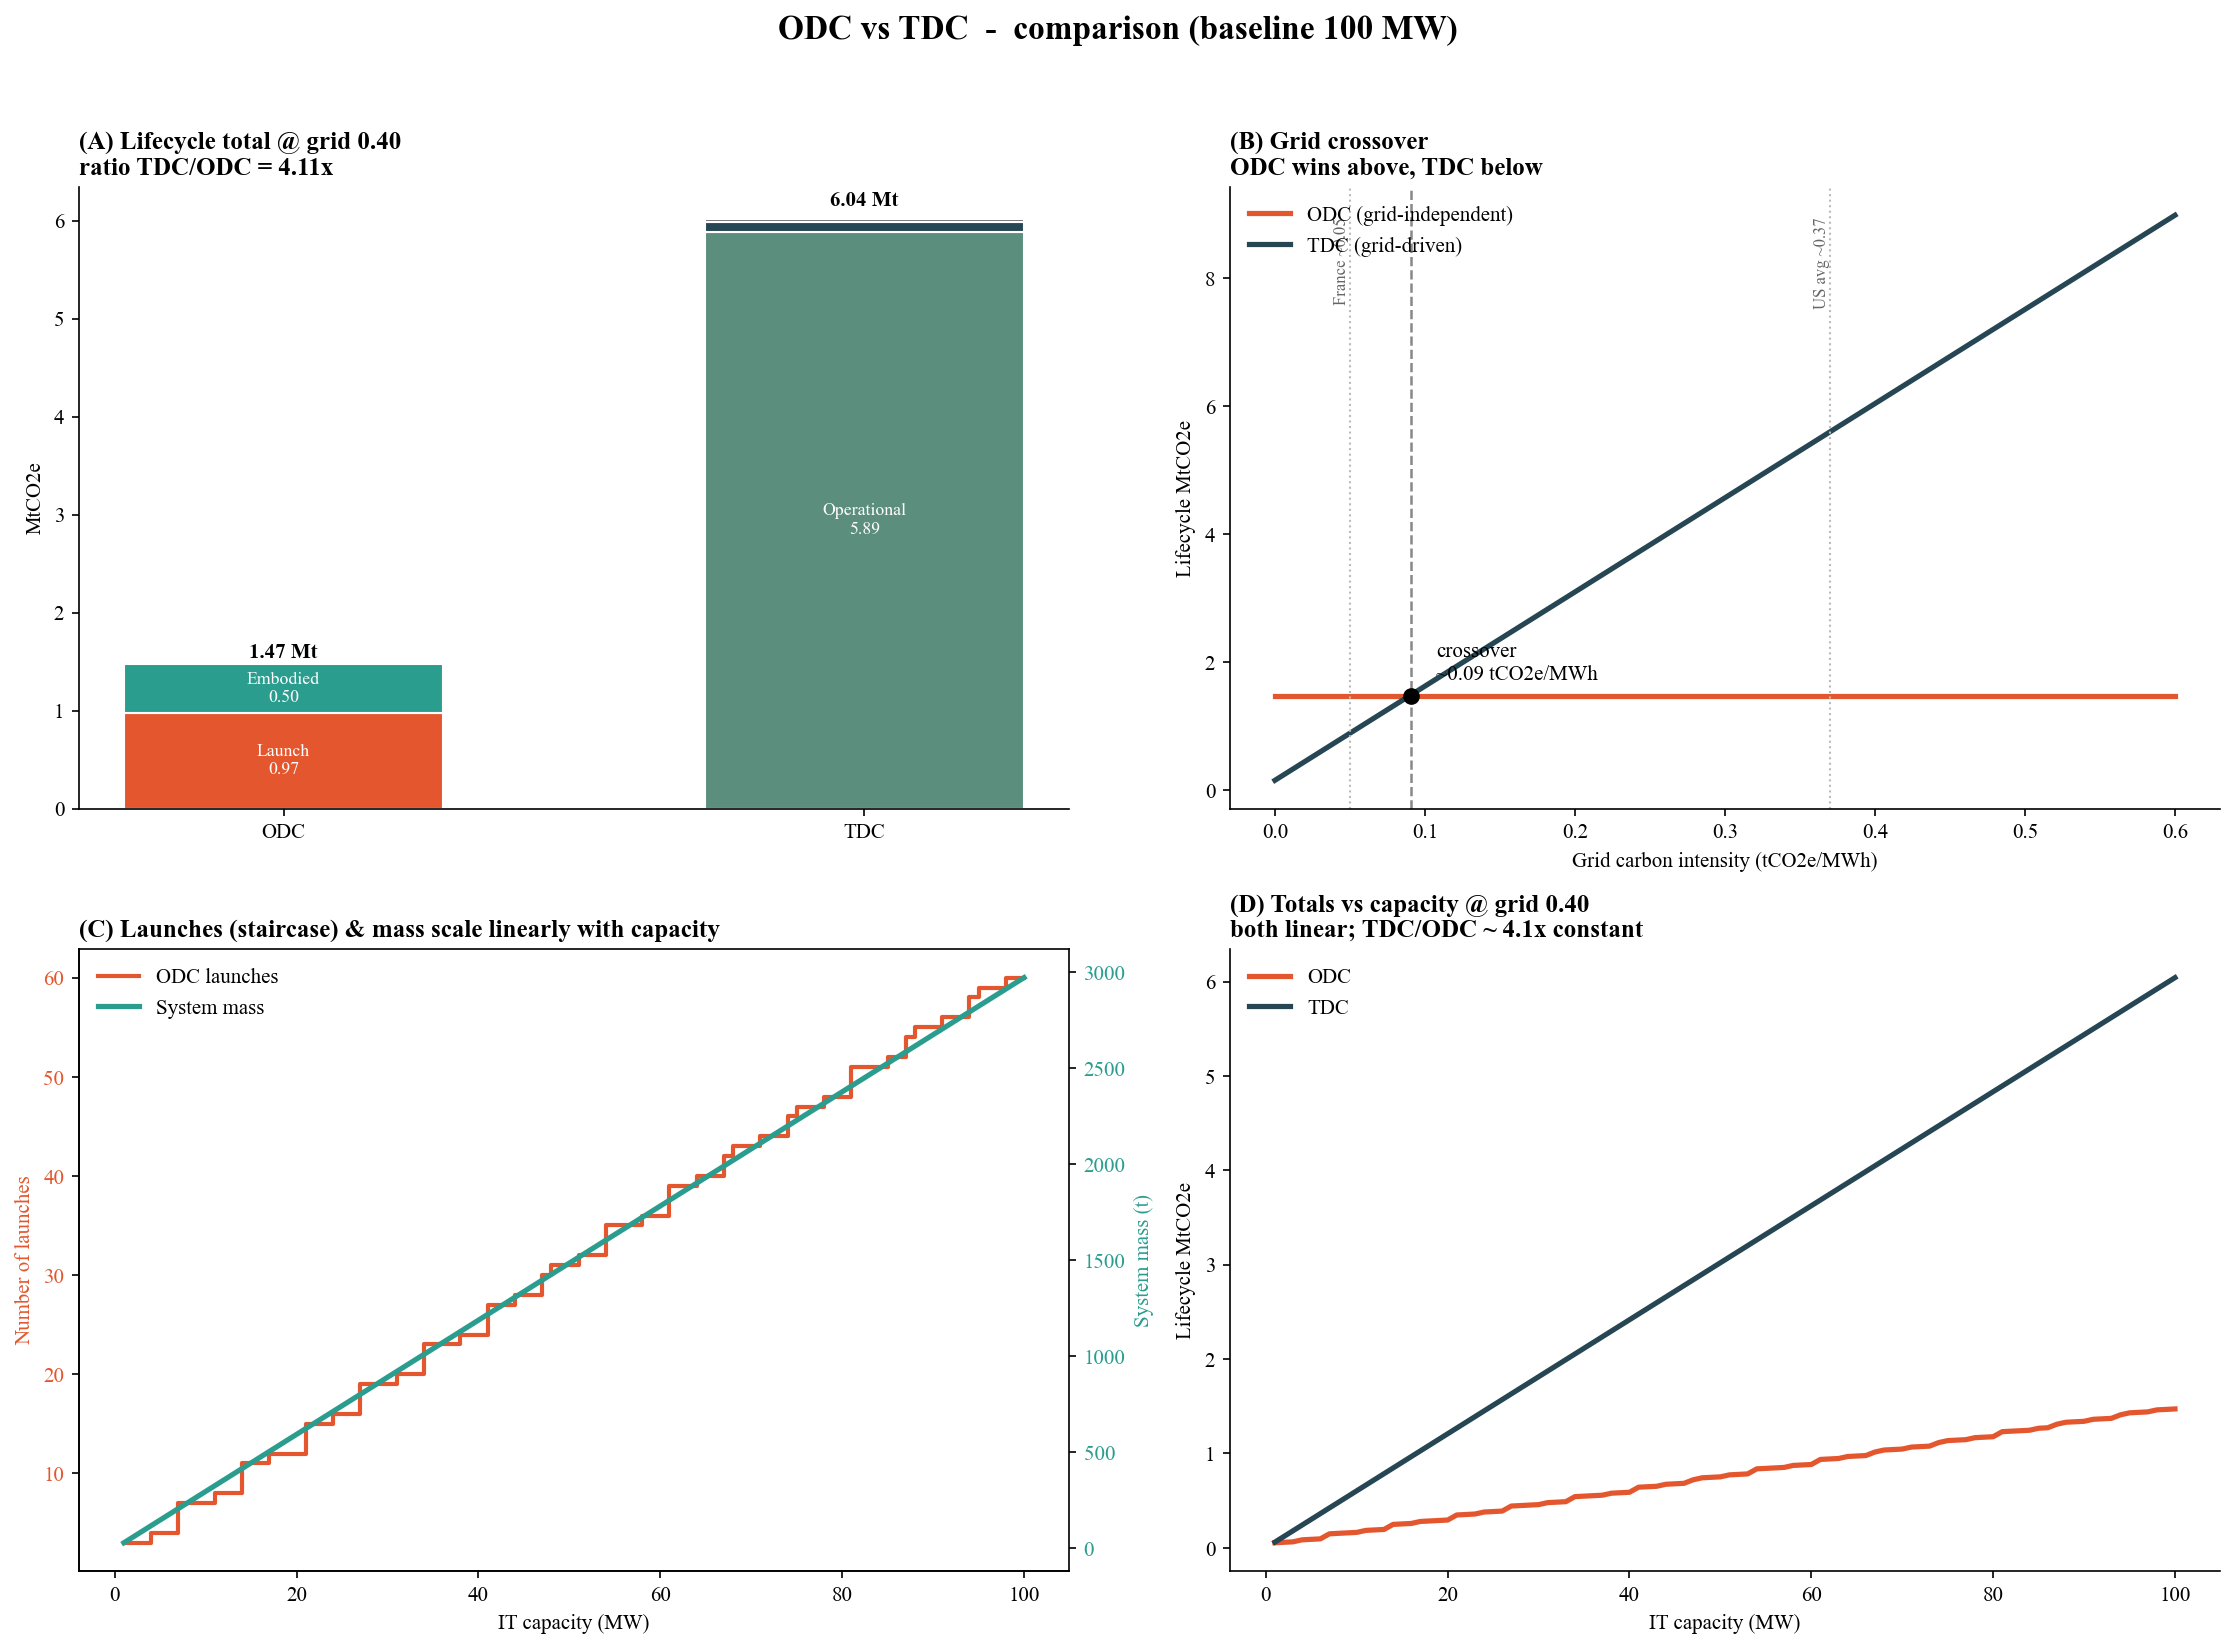

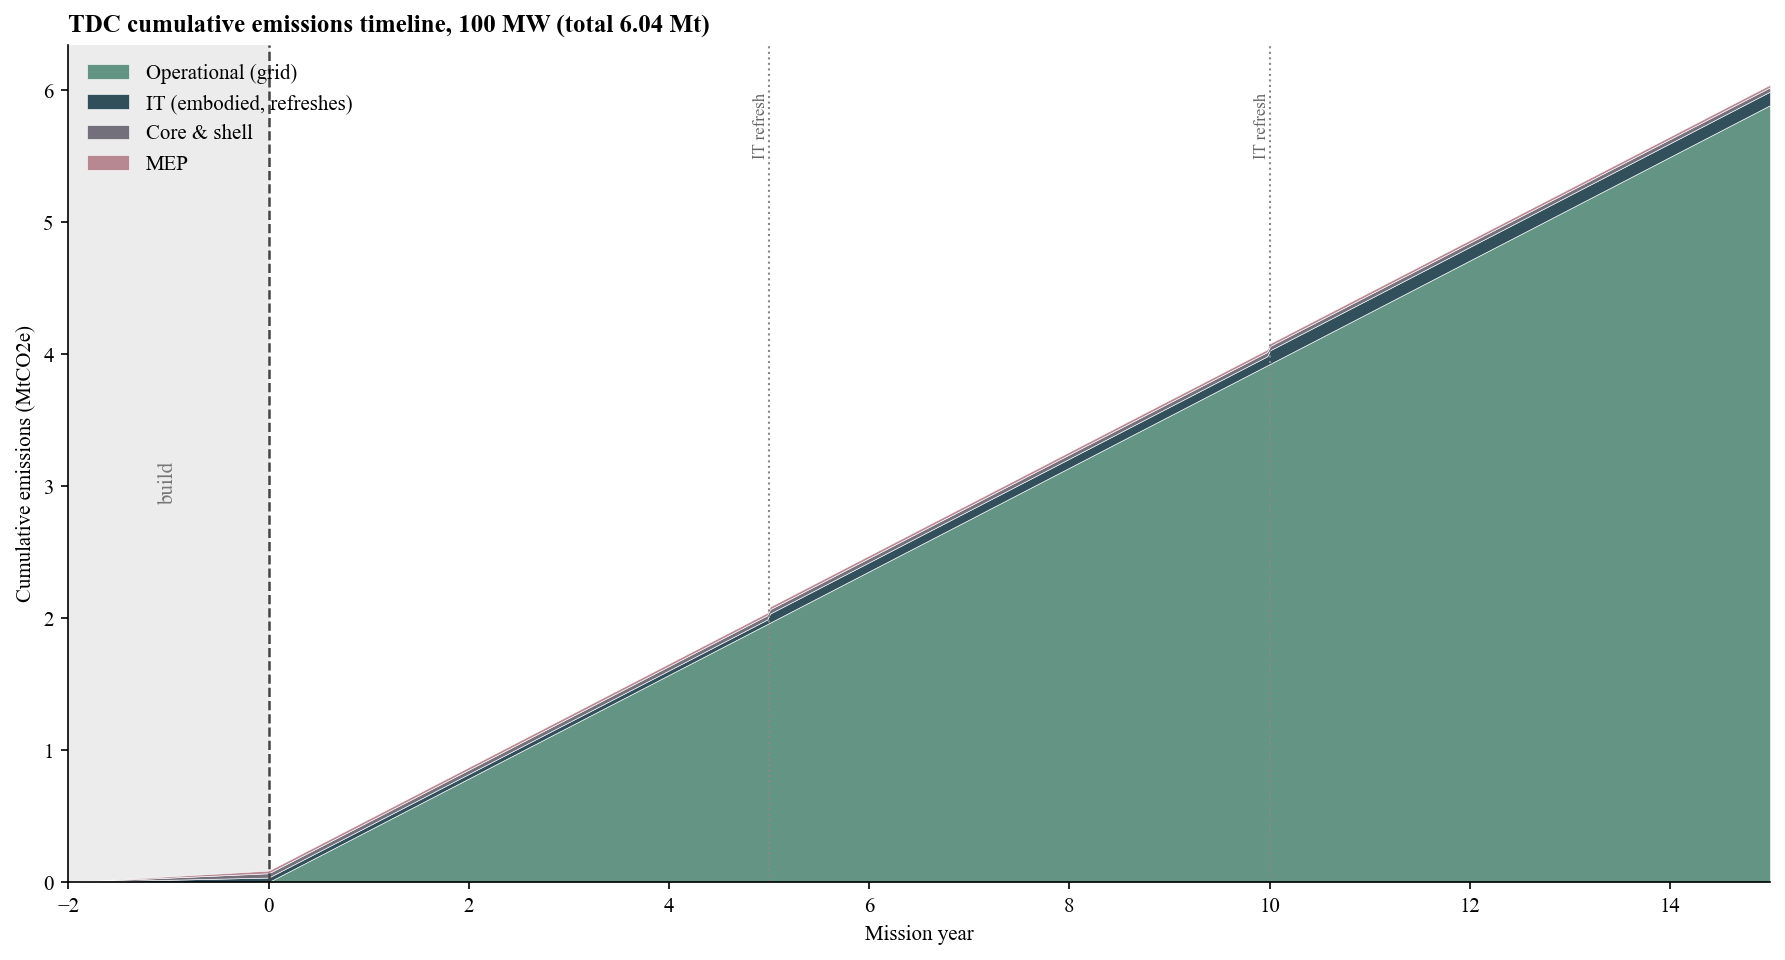

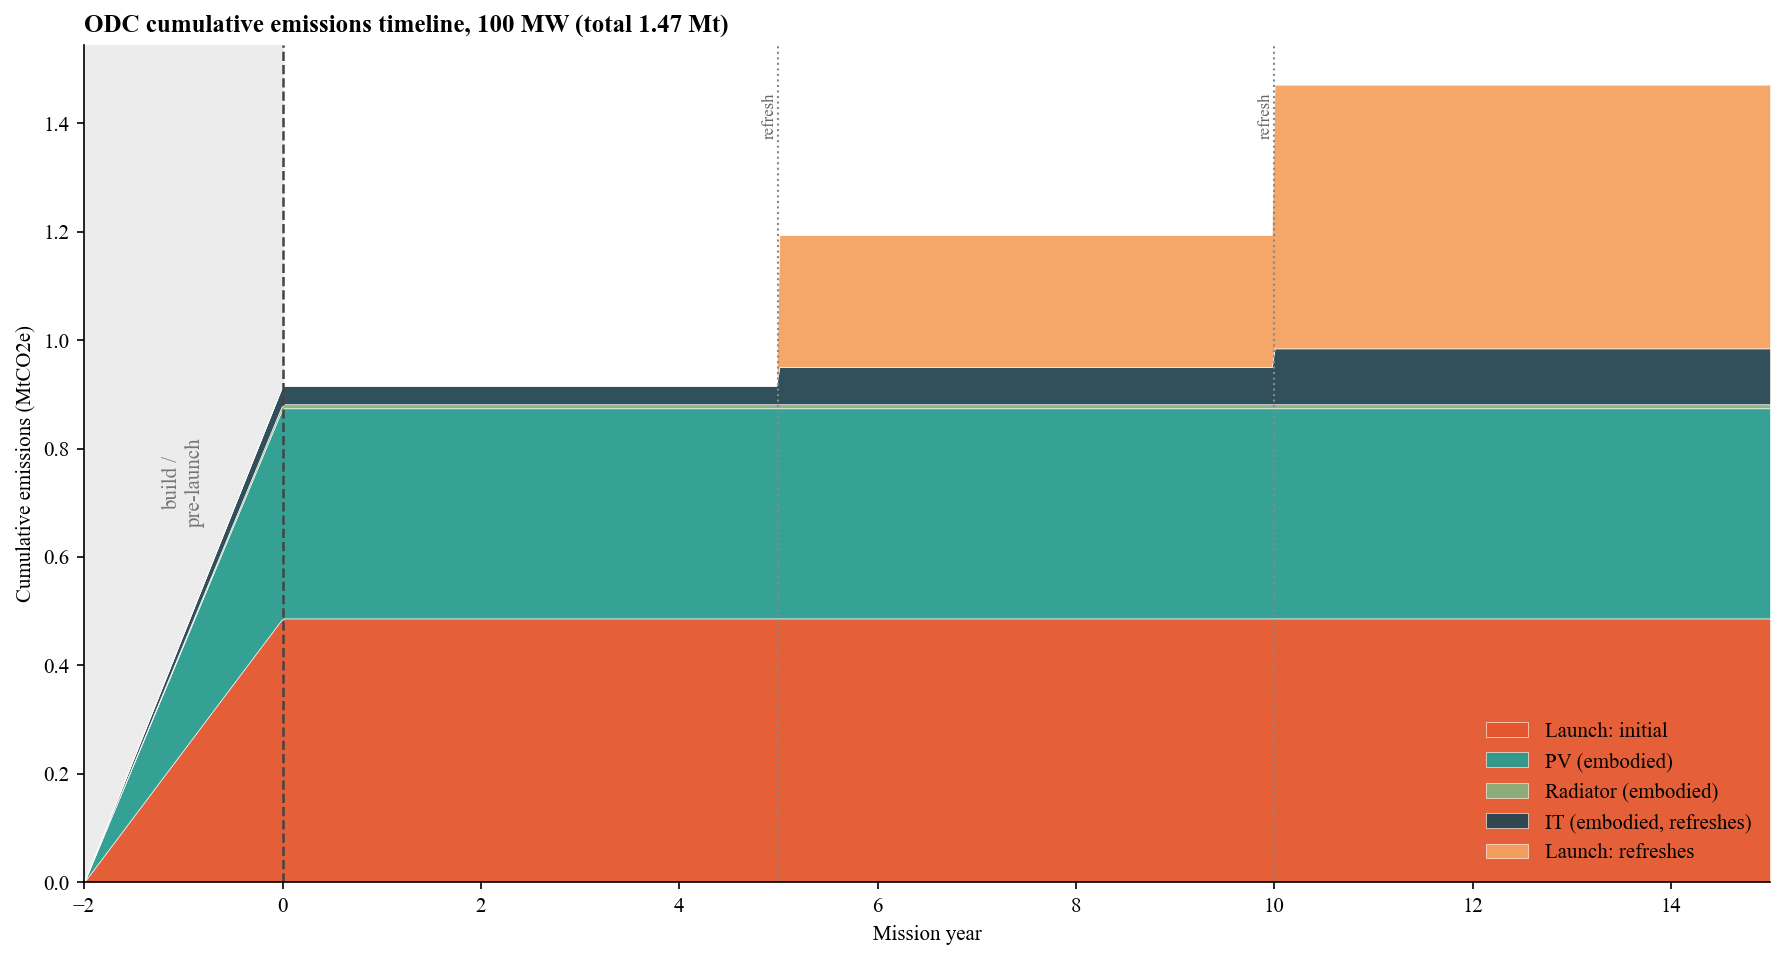

In [33]:
# =============================================================================
# 8d. Carbon-model figures (TDC profile; ODC per-launch + lifecycle)
# =============================================================================
import seaborn as sns
PAL = {"it": "#264653", "shell": "#6D6875", "mep": "#B5838D", "op": "#5B8E7D",
       "launch": "#E4572E", "launch2": "#F4A261", "pv": "#2A9D8F",
       "rad": "#8AB17D", "odc": "#E4572E", "tdc": "#264653",
       "steel": "#4C78A8", "engine": "#F58518", "lox": "#90BE6D", "ch4": "#F9C74F"}


def _despine(ax): sns.despine(ax=ax)


def plot_tdc(s: CarbonScenario, tdc: dict, fname="carbon_figs/tdc_carbon.png"):
    p = tdc['profile']; yrs = np.array(p['years'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
    items = sorted(tdc['breakdown'].items(), key=lambda x: x[1], reverse=True)
    cols = {'IT (all gens)': PAL['it'], 'Core & shell': PAL['shell'], 'MEP': PAL['mep']}
    ax1.bar([k for k,_ in items], [v/1000 for _,v in items],
            color=[cols[k] for k,_ in items], edgecolor="white")
    ax1.set_ylabel("ktCO2e"); ax1.set_title("(A) TDC embodied by subsystem", loc="left", fontweight="bold")
    for i,(k,v) in enumerate(items):
        ax1.text(i, v/1000, f"{v/1000:,.0f}", ha="center", va="bottom", fontsize=10)
    ax1.tick_params(axis='x', rotation=12); _despine(ax1)
    ax2.plot(yrs, np.array(p['cum_embodied'])/1000, "-o", color=PAL['it'], ms=5, label="Embodied")
    ax2.plot(yrs, np.array(p['cum_operational'])/1000, "-s", color=PAL['op'], ms=5, label="Operational")
    ax2.set_xlabel("Mission year"); ax2.set_ylabel("Cumulative ktCO2e")
    es = tdc['embodied_total']/tdc['total']; os_ = tdc['operational_total']/tdc['total']
    ax2.set_title(f"(B) Operational {os_:.0%} vs embodied {es:.0%}\n"
                  f"grid {s.grid_intensity:.2f} tCO2e/MWh", loc="left", fontweight="bold")
    ax2.legend(frameon=False, loc="upper left"); _despine(ax2)
    fig.suptitle(f"TDC carbon  -  {s.it_capacity_mw:g} MW, {s.mission_years} yr  "
                 f"(total {tdc['total']/1e6:.2f} MtCO2e)", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_odc(s: CarbonScenario, odc: dict, fname="carbon_figs/odc_carbon.png"):
    d = odc['per_launch_detail']['detail']; pl = odc['per_launch_t']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5.5),
                                        gridspec_kw={"width_ratios":[1.3,1,1.2]})
    stages = {
        "Vehicle\n(amortized)": [("SH struct", d['sh_struct'], PAL['steel']),
                                 ("SH engines", d['sh_eng'], PAL['engine']),
                                 ("SS struct", d['ss_struct'], PAL['steel']),
                                 ("SS engines", d['ss_eng'], PAL['engine'])],
        "Propellant\nproduction": [("LOx", d['lox'], PAL['lox']),
                                   ("LCH4", d['methane'], PAL['ch4'])],
        "Combustion": [("EA (asc+test+land)", s.combustion_ea_t, PAL['launch'])],
    }
    xs = list(range(len(stages))); ymax = pl
    for i,(name, segs) in enumerate(stages.items()):
        bottom=0
        for lab,val,col in segs:
            ax1.bar(i, val, bottom=bottom, color=col, edgecolor="white", linewidth=0.6)
            if val > 0.03*ymax:
                ax1.text(i, bottom+val/2, f"{lab}\n{val:,.0f}", ha="center", va="center", fontsize=7)
            bottom+=val
        ax1.text(i, bottom+0.01*ymax, f"{bottom:,.0f} t", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
    ax1.set_xticks(xs); ax1.set_xticklabels(list(stages.keys()), fontsize=9)
    ax1.set_ylabel("tCO2e per launch")
    ax1.set_title(f"(A) Per-launch carbon\n{pl:,.0f} tCO2e ({pl/s.payload_cap_t:,.0f} kg/kg payload)",
                  loc="left", fontweight="bold"); _despine(ax1)
    labels=["Super Heavy","Starship"]; struct=[d['sh_struct'],d['ss_struct']]; eng=[d['sh_eng'],d['ss_eng']]
    x=np.arange(2)
    ax2.bar(x, struct, color=PAL['steel'], edgecolor="white", label="Stainless")
    ax2.bar(x, eng, bottom=struct, color=PAL['engine'], edgecolor="white", label="Engines")
    ax2.set_xticks(x); ax2.set_xticklabels(labels)
    ax2.set_ylabel("tCO2e per launch (amortized)")
    ax2.set_title(f"(B) Vehicle embodied\n(N_SH={s.n_sh_reuse:.0f}, N_SS={s.n_ss_reuse:.0f} reuses)",
                  loc="left", fontweight="bold")
    ax2.legend(frameon=False, fontsize=9, loc="upper center", ncol=2); _despine(ax2)
    comp = [("Launch: initial", odc['launch_initial'], PAL['launch']),
            ("Launch: refreshes", odc['launch_refresh'], PAL['launch2']),
            ("PV (embodied)", odc['breakdown']['PV array'], PAL['pv']),
            ("IT (embodied)", odc['breakdown']['IT (all gens)'], PAL['it']),
            ("Radiator (embodied)", odc['breakdown']['Radiator'], PAL['rad'])]
    comp.sort(key=lambda x:x[1], reverse=True)
    ax3.barh([c[0] for c in comp], [c[1]/1e6 for c in comp],
             color=[c[2] for c in comp], edgecolor="white")
    ax3.invert_yaxis(); ax3.set_xlabel("MtCO2e")
    ax3.set_title(f"(C) ODC lifecycle\n{odc['total']/1e6:.2f} Mt, "
                  f"launch {100*odc['launch_total']/odc['total']:.0f}%",
                  loc="left", fontweight="bold")
    for i,c in enumerate(comp):
        ax3.text(c[1]/1e6, i, f" {c[1]/1e6:.2f}", va="center", fontsize=9)
    _despine(ax3)
    fig.suptitle(f"ODC carbon  -  {s.it_capacity_mw:g} MW, {odc['n_launches']:.0f} launches",
                 fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.94]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_comparison(s: CarbonScenario, fname="carbon_figs/comparison.png"):
    odc = odc_carbon(s); tdc = tdc_carbon(s)
    fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(15, 11))
    for x, stack in [(0, [("Launch", odc['launch_total'], PAL['launch']),
                          ("Embodied", odc['embodied_total'], PAL['pv'])]),
                     (1, [("Operational", tdc['operational_total'], PAL['op']),
                          ("IT embodied", tdc['breakdown']['IT (all gens)'], PAL['it']),
                          ("Core & shell", tdc['breakdown']['Core & shell'], PAL['shell']),
                          ("MEP", tdc['breakdown']['MEP'], PAL['mep'])])]:
        bottom=0
        for name,val,col in stack:
            axA.bar(x, val/1e6, bottom=bottom/1e6, color=col, edgecolor="white", width=0.55)
            if val/1e6 > 0.04*max(odc['total'],tdc['total'])/1e6:
                axA.text(x,(bottom+val/2)/1e6, f"{name}\n{val/1e6:.2f}", ha="center", va="center",
                         fontsize=8.5, color="white")
            bottom+=val
        axA.text(x, bottom/1e6*1.01, f"{bottom/1e6:.2f} Mt", ha="center", va="bottom", fontweight="bold")
    axA.set_xticks([0,1]); axA.set_xticklabels(["ODC","TDC"]); axA.set_ylabel("MtCO2e")
    axA.set_title(f"(A) Lifecycle total @ grid {s.grid_intensity:.2f}\n"
                  f"ratio TDC/ODC = {tdc['total']/odc['total']:.2f}x", loc="left", fontweight="bold")
    _despine(axA)
    grid = np.linspace(0, 0.6, 120)
    tdc_curve = np.array([tdc_carbon(replace(s, grid_intensity=g))['total']
                          for g in grid]) / 1e6
    odc_flat = np.full_like(grid, odc['total']/1e6)
    axB.plot(grid, odc_flat, color=PAL['odc'], lw=2.5, label="ODC (grid-independent)")
    axB.plot(grid, tdc_curve, color=PAL['tdc'], lw=2.5, label="TDC (grid-driven)")
    ix = int(np.argmin(np.abs(tdc_curve - odc_flat))); gx = grid[ix]
    axB.axvline(gx, color="#888", ls="--", lw=1.2)
    axB.plot(gx, odc['total']/1e6, "o", color="k", ms=7, zorder=5)
    axB.annotate(f"crossover\n~{gx:.2f} tCO2e/MWh", (gx, odc['total']/1e6),
                 textcoords="offset points", xytext=(12,8), fontsize=10)
    for lab,gv in [("France ~0.05",0.05),("US avg ~0.37",0.37)]:
        axB.axvline(gv, color="#bbb", ls=":", lw=1)
        axB.text(gv, axB.get_ylim()[1]*0.95, lab, rotation=90, va="top", ha="right",
                 fontsize=8, color="#666")
    axB.set_xlabel("Grid carbon intensity (tCO2e/MWh)"); axB.set_ylabel("Lifecycle MtCO2e")
    axB.set_title("(B) Grid crossover\nODC wins above, TDC below", loc="left", fontweight="bold")
    axB.legend(frameon=False, loc="upper left"); _despine(axB)
    caps = np.arange(1, 101, dtype=float)
    n_launch=[]; mass_t=[]; odc_tot=[]; tdc_tot=[]
    for c in caps:
        sc = replace(s, it_capacity_mw=c)
        oc = odc_carbon(sc); tc = tdc_carbon(sc)
        n_launch.append(oc['n_launches']); mass_t.append(oc['mass_budget']['Total']/1000.0)
        odc_tot.append(oc['total']/1e6); tdc_tot.append(tc['total']/1e6)
    lC = axC.plot(caps, n_launch, color=PAL['launch'], lw=2, drawstyle="steps-post",
                  label="ODC launches")
    axC.set_xlabel("IT capacity (MW)"); axC.set_ylabel("Number of launches", color=PAL['launch'])
    axC.tick_params(axis='y', labelcolor=PAL['launch'])
    axC2 = axC.twinx()
    lC2 = axC2.plot(caps, mass_t, color=PAL['pv'], lw=2.5, label="System mass")
    axC2.set_ylabel("System mass (t)", color=PAL['pv']); axC2.tick_params(axis='y', labelcolor=PAL['pv'])
    axC2.grid(False)
    axC.set_title("(C) Launches (staircase) & mass scale linearly with capacity",
                  loc="left", fontweight="bold")
    axC.legend(lC + lC2, [l.get_label() for l in lC + lC2], frameon=False,
               loc="upper left", fontsize=10)
    _despine(axC)
    axD.plot(caps, odc_tot, color=PAL['odc'], lw=2.5, label="ODC")
    axD.plot(caps, tdc_tot, color=PAL['tdc'], lw=2.5, label="TDC")
    axD.set_xlabel("IT capacity (MW)"); axD.set_ylabel("Lifecycle MtCO2e")
    axD.set_title(f"(D) Totals vs capacity @ grid {s.grid_intensity:.2f}\n"
                  f"both linear; TDC/ODC ~ {tdc_tot[-1]/odc_tot[-1]:.1f}x constant",
                  loc="left", fontweight="bold")
    axD.legend(frameon=False, loc="upper left"); _despine(axD)
    fig.suptitle(f"ODC vs TDC  -  comparison (baseline {s.it_capacity_mw:g} MW)",
                 fontsize=16, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0,0,1,0.97]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ----------------------------------------------------- emissions timelines ----
def _ramp(t, value, t0=-2.0, t1=0.0):
    return value * np.clip((t - t0) / (t1 - t0), 0.0, 1.0)


def _step(t, value, t_event):
    return np.where(t >= t_event, value, 0.0)


def plot_timeline_odc(s: CarbonScenario, odc: dict, fname="carbon_figs/odc_timeline.png"):
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    n_ref_each = math.ceil((odc['mass_budget']['IT']/1000.0) / s.payload_cap_t)
    ref_launch = n_ref_each * odc['per_launch_t']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]
    launch_init = _ramp(t, odc['launch_initial'])
    pv  = _ramp(t, odc['breakdown']['PV array'])
    rad = _ramp(t, odc['breakdown']['Radiator'])
    it_cum = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    lref   = sum(_step(t, ref_launch, ry) for ry in refresh_yrs)
    bands = [("Launch: initial", launch_init, PAL['launch']),
             ("PV (embodied)",   pv,  PAL['pv']),
             ("Radiator (embodied)", rad, PAL['rad']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Launch: refreshes", lref, PAL['launch2'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build /\npre-launch", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"ODC cumulative emissions timeline, {s.it_capacity_mw:g} MW "
                 f"(total {odc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="lower right", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_timeline_tdc(s: CarbonScenario, tdc: dict, fname="carbon_figs/tdc_timeline.png"):
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    shell = tdc['breakdown']['Core & shell']; mep = tdc['breakdown']['MEP']
    op_total = tdc['operational_total']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]
    op_c    = np.where(t <= 0, 0.0, np.clip(t, 0, None)/s.mission_years * op_total)
    it_cum  = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    shell_c = _ramp(t, shell)
    mep_c   = _ramp(t, mep)
    bands = [("Operational (grid)", op_c, PAL['op']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Core & shell", shell_c, PAL['shell']),
             ("MEP", mep_c, PAL['mep'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "IT refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"TDC cumulative emissions timeline, {s.it_capacity_mw:g} MW "
                 f"(total {tdc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="upper left", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ===================================================================== driver ==
def run(capacity_mw: float, make_plots: bool = True):
    s = replace(CarbonScenario(), it_capacity_mw=capacity_mw)
    print("="*70)
    print(f"CARBON MODEL  -  {capacity_mw:g} MW IT, {s.mission_years} yr mission, "
          f"grid {s.grid_intensity:.2f} tCO2e/MWh")
    print("="*70)

    print("\nPHYSICAL SIZING")
    A_PV = c_size_pv_array(s)
    print(f"  PV array : {A_PV:>12,.0f} m^2  ({A_PV/FOOTBALL_M2:.1f} football fields)")
    A_rad = c_size_radiator(s, verbose=True)
    print(f"  Radiator : {A_rad:>12,.0f} m^2  ({A_rad/FOOTBALL_M2:.1f} football fields)")
    mb = c_mass_budget(s)
    print("  Mass budget (t): " + ", ".join(f"{k} {mb[k]/1000:,.0f}"
          for k in ['PV','Radiator','IT','Total']))

    tdc = tdc_carbon(s)
    print("\nTDC CARBON (tCO2e)")
    for k,v in tdc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'Embodied total':<16}: {tdc['embodied_total']:>12,.0f}")
    print(f"  {'Operational':<16}: {tdc['operational_total']:>12,.0f}")
    print(f"  {'TOTAL':<16}: {tdc['total']:>12,.0f}  ({tdc['total']/1e6:.2f} Mt)")

    odc = odc_carbon(s)
    print("\nODC CARBON (tCO2e)")
    print(f"  Launches: {odc['n_launches']:.0f}  @ {odc['per_launch_t']:,.0f} t/launch")
    print(f"  {'Launch initial':<16}: {odc['launch_initial']:>12,.0f}")
    print(f"  {'Launch refresh':<16}: {odc['launch_refresh']:>12,.0f}")
    for k,v in odc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'TOTAL':<16}: {odc['total']:>12,.0f}  ({odc['total']/1e6:.2f} Mt)")
    print(f"\n  ODC/TDC ratio @ grid {s.grid_intensity:.2f}: {odc['total']/tdc['total']:.2f}x")

    if make_plots:
        plot_tdc(s, tdc); plot_odc(s, odc); plot_comparison(s)
        plot_timeline_tdc(s, tdc); plot_timeline_odc(s, odc)
        print("\nFigures written to carbon_figs/: tdc_carbon, odc_carbon, "
              "comparison, tdc_timeline, odc_timeline (.png)")
    return s, tdc, odc


# -------------------------------------------------- run + expose for later cells
print(f"Verification: F_perp_adjacent(1,1) = {F_perp_adjacent(1,1):.5f} (expect 0.20004)\n")

carbon_scenario, tdc_carbon_result, odc_carbon_result = run(CAPACITY_MW, make_plots=True)

# Scalar results cast to float for the upcoming financial-vs-emissions comparison
odc_total_tco2e       = float(odc_carbon_result['total'])
odc_launch_tco2e      = float(odc_carbon_result['launch_total'])
odc_embodied_tco2e    = float(odc_carbon_result['embodied_total'])
tdc_total_tco2e       = float(tdc_carbon_result['total'])
tdc_embodied_tco2e    = float(tdc_carbon_result['embodied_total'])
tdc_operational_tco2e = float(tdc_carbon_result['operational_total'])
odc_n_launches        = int(odc_carbon_result['n_launches'])
odc_per_launch_tco2e  = float(odc_carbon_result['per_launch_t'])
system_mass_t         = float(odc_carbon_result['mass_budget']['Total'] / 1000.0)

# Exact grid-intensity crossover (operational term is linear in grid at decarb=0)
_op_slope_per_grid    = tdc_operational_tco2e / carbon_scenario.grid_intensity
carbon_crossover_grid = float((odc_total_tco2e - tdc_embodied_tco2e) / _op_slope_per_grid)

carbon_summary = {
    'odc_total_tco2e':       odc_total_tco2e,
    'tdc_total_tco2e':       tdc_total_tco2e,
    'odc_launch_tco2e':      odc_launch_tco2e,
    'odc_embodied_tco2e':    odc_embodied_tco2e,
    'tdc_embodied_tco2e':    tdc_embodied_tco2e,
    'tdc_operational_tco2e': tdc_operational_tco2e,
    'crossover_grid_tco2e_per_mwh': carbon_crossover_grid,
    'n_launches':            odc_n_launches,
    'system_mass_t':         system_mass_t,
}
print(f"\n  Exact grid crossover: {carbon_crossover_grid:.3f} tCO2e/MWh")

# 9. Figures

Order and dependencies:

| Figure | Cell defines | Depends on |
|---|---|---|
| **Sited-scenario composition** (cost / carbon / carbon-taxed) | `odc_cost_breakdown`, `tdc_cost_breakdown`, `odc_carbon_breakdown`, `tdc_carbon_breakdown`, `SEG_COLOR`, `US_AVG` | §1–8 |
| **Combined Figure 1** (composition A/B + projection C) | — | composition cell + projection cell |
| **Tornado computation** (carbon-inclusive) | `bars`, `base_lcoc`, `format_param_value` | §5, §8 |
| **Combined Figure 2** (launch-cost sweep + tornado) | — | tornado cell + projection cell |
| **Carbon-inclusive LCOC over time** (IEA grid-decarb scenarios) | — | projection + §8 |
| **Demand growth → ODC market share → Wright's law** | — | projection |
| **IT-capacity sweep** | — | §5, §6 |
| **TDC LCOC over the (grid × price) plane** | — | §6, §8 |
| **Break-even carbon price, 2026 / 2035 / 2045** | — | §6, §7, §8 |

All carbon-priced figures read the **single** `CARBON_PRICE` and `GRID_INTENSITY_2026` defined in Section 1d.

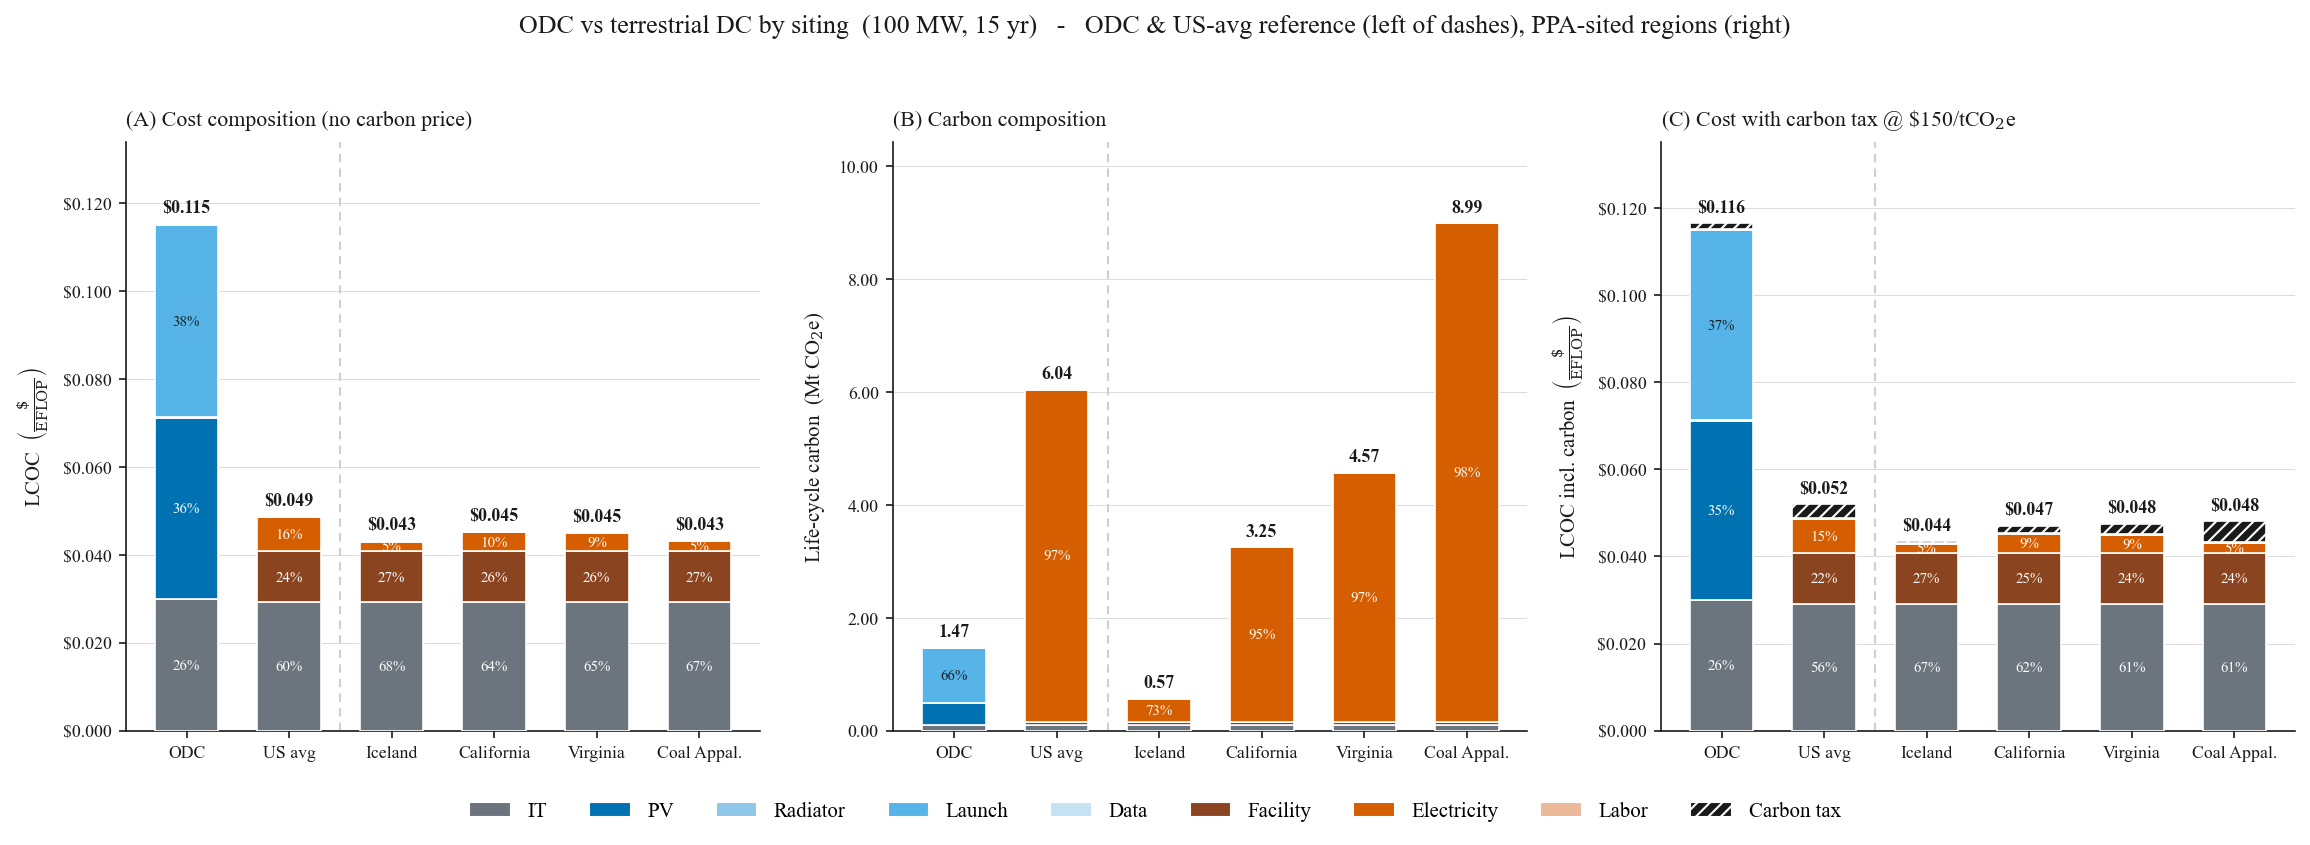

VALIDATION (vs headline numbers)
  ODC cost total       $0.1153/EFLOP   (headline 0.1234)
  TDC cost @ $150       $0.0487/EFLOP   (headline 0.0487)
  ODC/TDC cost ratio    2.37x   (headline 2.53x)
  TDC carbon @ 0.40     6.04 Mt   (headline 6.04)     ODC 1.47 Mt (1.41)
  ODC LCOC @ $150 tax   $0.1165     TDC US-avg @ $150 tax $0.0520

  Per-scenario (cost x / carbon x vs ODC):
    US avg       cost $0.0487 (2.37x)   carbon  6.04 Mt (4.11x)
    Iceland      cost $0.0432 (2.67x)   carbon  0.57 Mt (0.39x)
    California   cost $0.0454 (2.54x)   carbon  3.25 Mt (2.21x)
    Virginia     cost $0.0451 (2.56x)   carbon  4.57 Mt (3.11x)
    Coal Appal.  cost $0.0433 (2.66x)   carbon  8.99 Mt (6.11x)


In [34]:
# =============================================================================
# SITED-SCENARIO COMPOSITION  (paste AFTER cells 14, 18, 32)
# Bar order in every panel: [ ODC | US-avg TDC | sited TDCs... ]
#   (A) LCOC cost composition          $/EFLOP   -- site lever: PPA price
#   (B) Life-cycle carbon composition  Mt CO2e   -- site lever: grid intensity
#   (C) LCOC incl. carbon tax          $/EFLOP   -- (A) + carbon-priced cap
#
# STANDARDIZED TAXONOMY: cost and carbon share one component name per system, so
# panels A/B/C stack segment-for-segment. Components with no modeled value in a
# panel are explicit 0.0 (Data/Labor carbon; not carbon-free, just un-modeled).
#   ODC: IT | PV | Radiator | Launch | Data | Labor
#   TDC: IT | Facility (capex+O&M / shell+MEP) | Electricity (PPA / operational) | Labor
#
# FIXES BAKED IN:
#   - ODC Labor restored (was in build_cash_flows, dropped from the old breakdown).
#   - TDC carbon-tax normalization: divide whole-facility emissions by whole-
#     facility compute (_npc_tdc_total), not per-kW compute x 1000 (was 10x low).
#   - Consistent TDC cost decomposition (shared IT) -> ODC/TDC ratio 2.53x.
#
# Requires (already defined earlier in the notebook):
#   cells 3-14 : BASELINE, mass_budget, annual_eflop, CAPACITY_FACTOR, Q_COMPUTE,
#                LIFETIME_YR, HOURS_PER_YEAR, SECONDS_PER_YEAR, ANNUAL_LABOR_COST,
#                FACILITY_COST_PER_KW, FACILITY_OM_FRAC, IT_REFRESH_YEARS
#   cell 18    : BG, INK, GRID, FONT, ODC_COLOR, TDC_COLOR
#   cell 32    : carbon_scenario, tdc_carbon, odc_carbon_result, replace
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import replace

# --------------------------------------------------------------- knobs --------
CARBON_TAX_USD_PER_T = CARBON_PRICE     # $/tCO2e used in panel (C); EPA-2023 SCC central ~$190
PUE_TDC              = 1.12
DISCOUNT_CARBON      = True      # discount annual carbon flows before pricing them

# Sited scenarios: (label, grid intensity [tCO2e/MWh], PPA price [$/MWh]).
US_AVG = ('US avg', 0.40, 150)                     # reference TDC (sits 2nd)
SITES  = [
    ('Iceland',      0.028, 43),   # clean + cheap
    ('California',   0.210, 85),   # clean-ish + expensive
    ('Virginia',     0.300, 80),   # "Data Center Alley"
    ('Coal Appal.',  0.600, 45),   # dirty + cheap
]

# ============================================================ cost engine =====
_gamma = BASELINE.gamma_PFLOPS_per_kW
_r     = BASELINE.discount_rate
_disc  = 1.0 / (1 + _r) ** np.arange(LIFETIME_YR)

_npc_odc = (annual_eflop(BASELINE, k_load=CAPACITY_FACTOR) * _disc).sum()   # EFLOP, 100 MW
_npc_tdc = (_gamma * 1.0 * SECONDS_PER_YEAR * _disc).sum()                  # PFLOP, per kW
# whole-facility TDC compute in EFLOP (parallels _npc_odc); used for carbon charge
_npc_tdc_total = _npc_tdc * (Q_COMPUTE / 1e3) / 1e3   # PFLOP/kW x total_kW / 1000

# ========================================================== carbon engine =====
# ODC carbon is site-independent: pull its annual profile + total once.
_odc_prof     = odc_carbon_result['profile']
_odc_annual_t = np.array(_odc_prof['embodied_spike']) + np.array(_odc_prof['launch_spike'])
_odc_total_t  = odc_carbon_result['total']

def _carbon_tax_per_eflop(annual_t, npc, carbon_price):
    """Carbon charge [$/EFLOP]. Discounts annual carbon flows if DISCOUNT_CARBON.
    npc must be the WHOLE-facility compute [EFLOP] matching the extensive emissions."""
    if carbon_price == 0:
        return 0.0
    flows = (annual_t * _disc).sum() if DISCOUNT_CARBON else annual_t.sum()
    return carbon_price * flows / npc

# ================= STANDARDIZED BREAKDOWNS (same names in cost & carbon) =======
def odc_cost_breakdown():
    mb   = mass_budget(BASELINE)
    cPV  = mb['A_PV']  * BASELINE.pv_areal_cost
    cRad = mb['A_rad'] * BASELINE.rad_areal_cost
    cIT  = (Q_COMPUTE / 1e6) * BASELINE.it_cost_per_MW
    lau0 = mb['Total'] * BASELINE.launch_cost_per_kg
    lauR = mb['IT']    * BASELINE.launch_cost_per_kg
    drop = BASELINE.data_fixed_cost + BASELINE.data_mass_per_drop * BASELINE.launch_cost_per_kg
    def cf(y0, rf=0.0):
        a = np.zeros(LIFETIME_YR); a[0] = y0
        for ry in (5, 10): a[ry] += rf
        return a
    return {
        'IT':       (cf(cIT, cIT)  * _disc).sum() / _npc_odc,
        'PV':       (cf(cPV)       * _disc).sum() / _npc_odc,
        'Radiator': (cf(cRad)      * _disc).sum() / _npc_odc,
        'Launch':   (cf(lau0, lauR)* _disc).sum() / _npc_odc,
        'Data':     (np.full(LIFETIME_YR, drop * BASELINE.data_drops_per_year) * _disc).sum() / _npc_odc,
        'Labor':    (np.full(LIFETIME_YR, ANNUAL_LABOR_COST) * _disc).sum() / _npc_odc,  # restored
    }

def tdc_cost_breakdown(p_per_MWh):
    it_per_kW = BASELINE.it_cost_per_MW / 1000.0
    it_cf = np.zeros(LIFETIME_YR)
    for yr in range(0, LIFETIME_YR, IT_REFRESH_YEARS):
        it_cf[yr] += it_per_kW
    elec  = PUE_TDC * (p_per_MWh / 1000) * HOURS_PER_YEAR
    om    = FACILITY_OM_FRAC * FACILITY_COST_PER_KW
    labor = ANNUAL_LABOR_COST / (Q_COMPUTE / 1e3)
    return {
        'IT':          (it_cf * _disc).sum() / _npc_tdc * 1000,
        'Facility':    (FACILITY_COST_PER_KW + (om * _disc).sum()) / _npc_tdc * 1000,  # capex + O&M
        'Electricity': (elec * _disc).sum() / _npc_tdc * 1000,
        'Labor':       (labor * _disc).sum() / _npc_tdc * 1000,
    }

def odc_carbon_breakdown():
    b = odc_carbon_result['breakdown']
    return {
        'IT':       b['IT (all gens)']                / 1e6,
        'PV':       b['PV array']                     / 1e6,
        'Radiator': b['Radiator']                     / 1e6,
        'Launch':   odc_carbon_result['launch_total'] / 1e6,
        'Data':     0.0,   # not modeled
        'Labor':    0.0,   # not modeled
    }

def tdc_carbon_breakdown(grid_intensity):
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=grid_intensity))
    parts = {
        'IT':          tc['breakdown']['IT (all gens)']                          / 1e6,
        'Facility':    (tc['breakdown']['Core & shell'] + tc['breakdown']['MEP']) / 1e6,  # shell + MEP
        'Electricity': tc['operational_total']                                   / 1e6,    # was 'Operational'
        'Labor':       0.0,   # not modeled
    }
    return parts, tc

# ===================================================== parametric LCOC (heatmap)
def odc_lcoc_full(carbon_price=0.0):
    """Total ODC LCOC [$/EFLOP] incl. carbon charge. Site-independent."""
    base = sum(odc_cost_breakdown().values())
    return base + _carbon_tax_per_eflop(_odc_annual_t, _npc_odc, carbon_price)

def tdc_lcoc_full(p_per_MWh, grid_intensity, carbon_price=0.0):
    """Total TDC LCOC [$/EFLOP] incl. carbon charge (fixed whole-facility denom)."""
    base = sum(tdc_cost_breakdown(p_per_MWh).values())
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=grid_intensity))
    annual = np.array(tc['profile']['embodied_spike']) + np.array(tc['profile']['operational'])
    return base + _carbon_tax_per_eflop(annual, _npc_tdc_total, carbon_price)

# ================================================================ colors =======
SEG_COLOR = {
    'IT':          '#6C757D',   # shared across ODC & TDC
    'PV':          '#0072B2',   # ODC
    'Launch':      '#56B4E9',   # ODC
    'Radiator':    '#8FC7E8',   # ODC
    'Data':        '#C4E3F3',   # ODC (cost only)
    'Facility':    '#8A4520',   # TDC (capex+O&M / shell+MEP)
    'Electricity': '#D55E00',   # TDC, cost AND carbon (site lever)
    'Labor':       '#EBB999',   # shared (cost only)
    'Carbon tax':  '#1a1a1a',   # panel C cap
}
_ACCENT = {'Electricity'}       # always label this segment

def _ink_on(hexcol):
    r, g, b = mcolors.to_rgb(hexcol)
    return INK if (0.299 * r + 0.587 * g + 0.114 * b) > 0.6 else 'white'

def _draw_bars(ax, entities, ylabel, title, yfmt, label_thresh=0.06):
    totals = [sum(v for _, v in segs) for _, segs in entities]
    ymax   = max(totals) * 1.16
    xs     = np.arange(len(entities))
    seen   = {}
    for x, (_, segs) in zip(xs, entities):
        bottom, tot = 0.0, sum(v for _, v in segs)
        for seg, val in segs:
            col   = SEG_COLOR[seg]
            hatch = '////' if seg == 'Carbon tax' else None
            ax.bar(x, val, bottom=bottom, width=0.62, color=col, edgecolor=BG,
                   linewidth=0.8, zorder=3, hatch=hatch)
            seen.setdefault(seg, col)
            if val > 0 and (val >= label_thresh * ymax or seg in _ACCENT):
                ax.text(x, bottom + val / 2, f'{val / tot * 100:.0f}%', ha='center',
                        va='center', fontsize=7.2, color=_ink_on(col), fontfamily=FONT, zorder=4)
            bottom += val
        ax.text(x, bottom + ymax * 0.012, yfmt(bottom), ha='center', va='bottom',
                fontsize=8.6, color=INK, fontfamily=FONT, fontweight='bold', zorder=5)
    ax.set_xticks(xs)
    ax.set_xticklabels([e[0] for e in entities], fontsize=8.5, fontfamily=FONT, color=INK)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: yfmt(v)))
    ax.set_facecolor(BG)
    for s in ('top', 'right'):  ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(INK); ax.spines[s].set_linewidth(0.8)
    ax.grid(axis='y', color=GRID, alpha=0.7, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=8.5, width=0.8)
    ax.axvline(1.5, color=GRID, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.set_title(title, fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)
    return seen

def _legend(fig, seen_maps, ncol):
    order = ['IT', 'PV', 'Radiator', 'Launch', 'Data', 'Facility', 'Electricity', 'Labor', 'Carbon tax']
    seen = {}
    for m in seen_maps: seen.update(m)
    handles = [mpatches.Patch(facecolor=seen[k], edgecolor='white', label=k,
                              hatch='////' if k == 'Carbon tax' else None)
               for k in order if k in seen]
    fig.legend(handles=handles, loc='lower center', ncol=ncol, frameon=False,
               fontsize=8, bbox_to_anchor=(0.5, -0.02), prop={'family': FONT})

# ------------------------------------------------------ assemble the entities --
def _cost_entity(label, p): return (label, list(tdc_cost_breakdown(p).items()))
def _carb_entity(label, g): return (label, list(tdc_carbon_breakdown(g)[0].items()))

odc_c = list(odc_cost_breakdown().items())
odc_k = list(odc_carbon_breakdown().items())

costA = [('ODC', odc_c), _cost_entity(*US_AVG[::2])] + [_cost_entity(l, p) for l, g, p in SITES]
carbB = [('ODC', odc_k), _carb_entity(US_AVG[0], US_AVG[1])] + [_carb_entity(l, g) for l, g, p in SITES]

def _tax_cap_tdc(p, g): return tdc_lcoc_full(p, g, CARBON_TAX_USD_PER_T) - sum(tdc_cost_breakdown(p).values())
_tax_cap_odc = odc_lcoc_full(CARBON_TAX_USD_PER_T) - sum(odc_cost_breakdown().values())

costC = [('ODC', odc_c + [('Carbon tax', _tax_cap_odc)]),
         ('US avg', list(tdc_cost_breakdown(US_AVG[2]).items()) + [('Carbon tax', _tax_cap_tdc(US_AVG[2], US_AVG[1]))])] + \
        [(l, list(tdc_cost_breakdown(p).items()) + [('Carbon tax', _tax_cap_tdc(p, g))]) for l, g, p in SITES]

_dollar = lambda v: f'${v:.3f}' if v < 1 else f'${v:,.0f}'
_mt     = lambda v: f'{v:.2f}'

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4))
fig.patch.set_facecolor(BG)
s1 = _draw_bars(axes[0], costA, r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
                '(A) Cost composition (no carbon price)', _dollar)
s2 = _draw_bars(axes[1], carbB, r'Life-cycle carbon  (Mt CO$_2$e)',
                '(B) Carbon composition', _mt)
s3 = _draw_bars(axes[2], costC, r'LCOC incl. carbon  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
                rf'(C) Cost with carbon tax @ \${CARBON_TAX_USD_PER_T:.0f}/tCO$_2$e', _dollar)
_legend(fig, [s1, s2, s3], ncol=9)
fig.suptitle('ODC vs terrestrial DC by siting  (100 MW, 15 yr)   -   '
             'ODC & US-avg reference (left of dashes), PPA-sited regions (right)',
             fontsize=12.5, color=INK, fontfamily=FONT, y=1.00)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
# fig.savefig('sited_composition.pdf', bbox_inches='tight')
# fig.savefig('sited_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------- validation -----
print("VALIDATION (vs headline numbers)")
print(f"  ODC cost total       ${sum(odc_cost_breakdown().values()):.4f}/EFLOP   (headline 0.1234)")
print(f"  TDC cost @ $150       ${sum(tdc_cost_breakdown(150).values()):.4f}/EFLOP   (headline 0.0487)")
print(f"  ODC/TDC cost ratio    {sum(odc_cost_breakdown().values())/sum(tdc_cost_breakdown(150).values()):.2f}x   (headline 2.53x)")
_bd, _tc = tdc_carbon_breakdown(0.40)
print(f"  TDC carbon @ 0.40     {_tc['total']/1e6:.2f} Mt   (headline 6.04)     ODC {_odc_total_t/1e6:.2f} Mt (1.41)")
print(f"  ODC LCOC @ $150 tax   ${odc_lcoc_full(150):.4f}     TDC US-avg @ $150 tax ${tdc_lcoc_full(150, 0.40, 150):.4f}")
print("\n  Per-scenario (cost x / carbon x vs ODC):")
_oc = sum(odc_cost_breakdown().values()); _ok = _odc_total_t / 1e6
for lab, g, p in [US_AVG] + SITES:
    tc_ = sum(tdc_cost_breakdown(p).values())
    tk_ = tdc_carbon(replace(carbon_scenario, grid_intensity=g))['total'] / 1e6
    print(f"    {lab:<12} cost ${tc_:.4f} ({_oc/tc_:.2f}x)   carbon {tk_:5.2f} Mt ({tk_/_ok:.2f}x)")

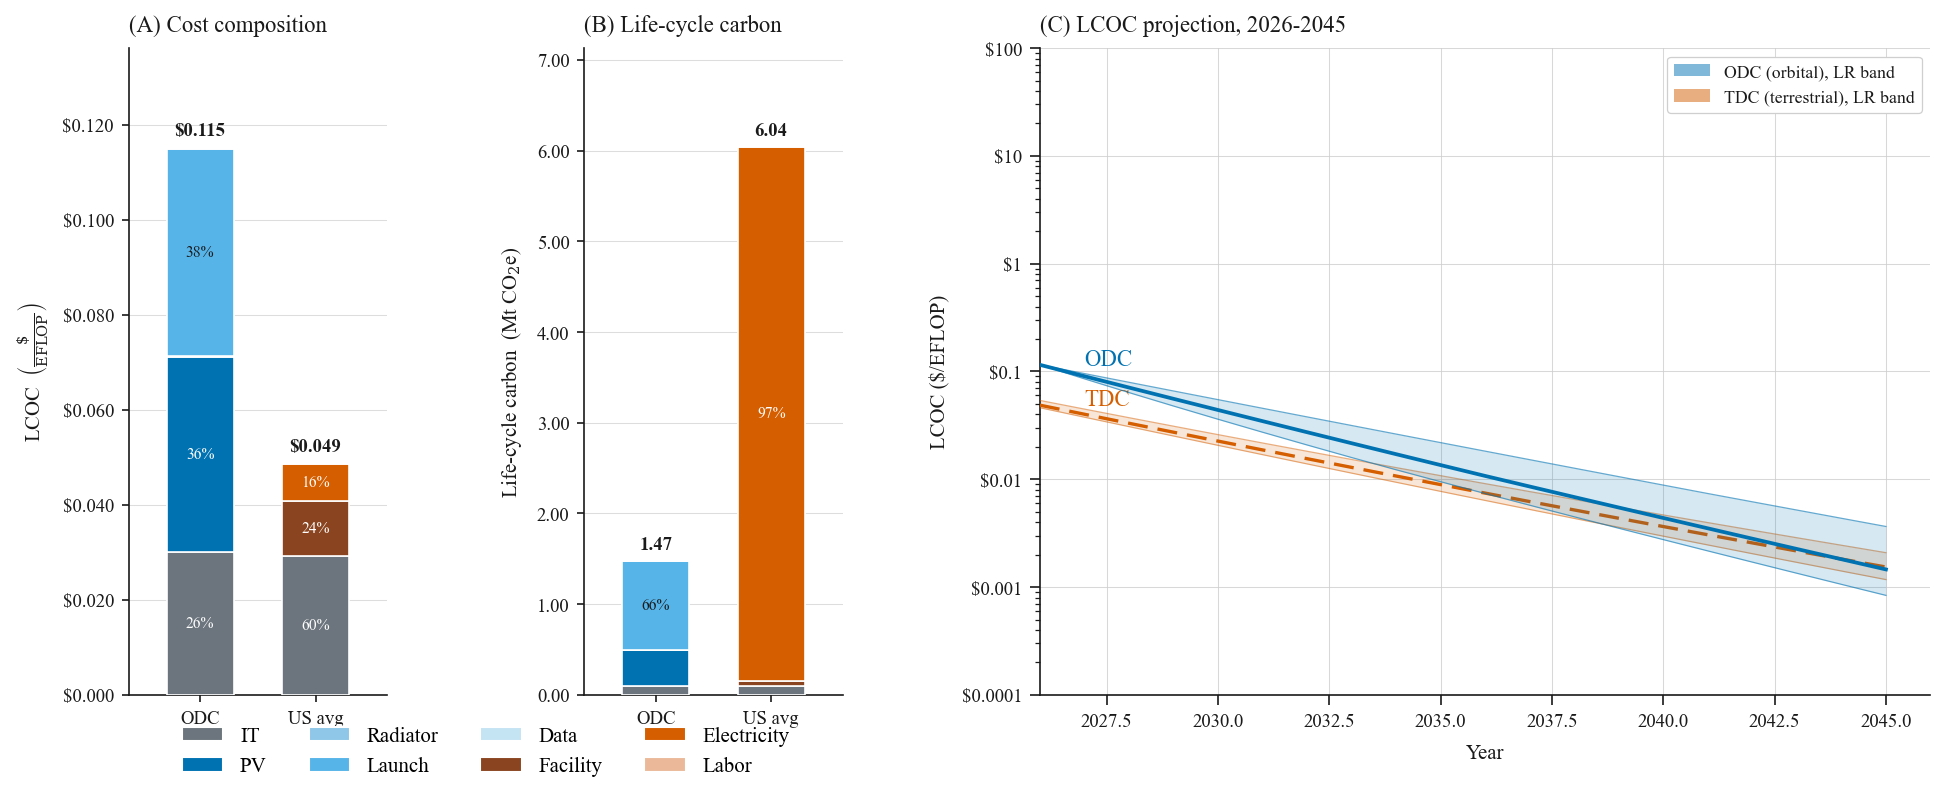

In [35]:
# =============================================================================
# COMBINED PAPER FIGURE  (paste AFTER the projection cell AND the standardized
# composition cell)
#   (A) Cost composition       ODC | US-avg TDC        $/EFLOP   [no siting]
#   (B) Life-cycle carbon      ODC | US-avg TDC        Mt CO2e   [no siting]
#   (C) LCOC projection 2026-2045, learning-rate bands
# Left block = capital + carbon breakdown (baseline US-avg TDC only, no carbon
# price). Right = the time trajectory. Component names reuse the standardized
# taxonomy (IT | PV | Radiator | Launch | Data | Facility | Electricity | Labor).
#
# Requires: odc_cost_breakdown / tdc_cost_breakdown / odc_carbon_breakdown /
#           tdc_carbon_breakdown / SEG_COLOR / _ink_on / _ACCENT / US_AVG   (composition cell)
#           years_calendar / odc_nom,odc_hi,odc_lo / tdc_nom,tdc_hi,tdc_lo    (projection cell)
#           BG / INK / GRID / FONT / ODC_COLOR / TDC_COLOR / style_axes        (styling cell)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

_dollar = lambda v: f'${v:.3f}' if v < 1 else f'${v:,.0f}'
_mt     = lambda v: f'{v:.2f}'

# ----- baseline entities: ODC and US-avg TDC only (US_AVG = (label, grid, PPA))
cost_ent = [('ODC',    list(odc_cost_breakdown().items())),
            ('US avg', list(tdc_cost_breakdown(US_AVG[2]).items()))]
carb_ent = [('ODC',    list(odc_carbon_breakdown().items())),
            ('US avg', list(tdc_carbon_breakdown(US_AVG[1])[0].items()))]

def _stack(ax, entities, ylabel, title, yfmt, label_thresh=0.055):
    totals = [sum(v for _, v in segs) for _, segs in entities]
    ymax   = max(totals) * 1.18
    xs     = np.arange(len(entities))
    seen   = {}
    for x, (name, segs) in zip(xs, entities):
        bottom, tot = 0.0, sum(v for _, v in segs)
        for seg, val in segs:
            col = SEG_COLOR[seg]
            ax.bar(x, val, bottom=bottom, width=0.58, color=col, edgecolor=BG,
                   linewidth=0.8, zorder=3)
            seen.setdefault(seg, col)
            if val > 0 and (val >= label_thresh * ymax or seg in _ACCENT):
                ax.text(x, bottom + val / 2, f'{val / tot * 100:.0f}%', ha='center',
                        va='center', fontsize=7.5, color=_ink_on(col), fontfamily=FONT, zorder=4)
            bottom += val
        ax.text(x, bottom + ymax * 0.012, yfmt(bottom), ha='center', va='bottom',
                fontsize=9, color=INK, fontfamily=FONT, fontweight='bold', zorder=5)
    ax.set_xticks(xs)
    ax.set_xticklabels([e[0] for e in entities], fontsize=9.5, fontfamily=FONT, color=INK)
    ax.set_xlim(-0.62, len(entities) - 0.38)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: yfmt(v)))
    ax.set_facecolor(BG)
    for s in ('top', 'right'):  ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(INK); ax.spines[s].set_linewidth(0.8)
    ax.grid(axis='y', color=GRID, alpha=0.7, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=9, width=0.8)
    ax.set_title(title, fontsize=11, color=INK, fontfamily=FONT, loc='left', pad=8)
    return seen

# ============================================================ layout ==========
fig = plt.figure(figsize=(15.5, 5.6))
gs  = fig.add_gridspec(1, 3, width_ratios=[0.9, 0.9, 3.1], wspace=0.42)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])

sA = _stack(axA, cost_ent, r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
            '(A) Cost composition', _dollar)
sB = _stack(axB, carb_ent, r'Life-cycle carbon  (Mt CO$_2$e)',
            '(B) Life-cycle carbon', _mt)

# ---------------------------------------------------- (C) projection ----------
axC.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.15, zorder=2, linewidth=0)
axC.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
axC.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
axC.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=1.6, linestyle=(0, (6, 3)), zorder=4)
axC.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.16, zorder=5, linewidth=0)
axC.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
axC.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
axC.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=1.8, zorder=7)
axC.text(2027, odc_nom[0] * 1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT, fontsize=11, va='center')
axC.text(2027, tdc_nom[0] * 1.12, 'TDC', color=TDC_COLOR, fontfamily=FONT, fontsize=11, va='center')
proj_handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.5, label='ODC (orbital), LR band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.5, label='TDC (terrestrial), LR band'),
]
legC = axC.legend(handles=proj_handles, loc='upper right', frameon=True, framealpha=1.0,
                  edgecolor=GRID, facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
legC.get_frame().set_linewidth(0.6)
for t in legC.get_texts(): t.set_color(INK)
style_axes(axC, fig, title='(C) LCOC projection, 2026-2045',
           xlabel='Year', ylabel='LCOC ($/EFLOP)', xlim=(2026, 2046), ylim=(0.0001, 100))

# ------------------------------------------ shared component legend (left) ----
fig.tight_layout(rect=[0, 0.11, 1, 1])
posA = axA.get_position(); posB = axB.get_position()
cx = (posA.x0 + posB.x1) / 2
order = ['IT', 'PV', 'Radiator', 'Launch', 'Data', 'Facility', 'Electricity', 'Labor']
seen  = {**sA, **sB}
comp_handles = [mpatches.Patch(facecolor=seen[k], edgecolor='white', label=k)
                for k in order if k in seen]
fig.legend(handles=comp_handles, loc='upper center', bbox_to_anchor=(cx, 0.095),
           ncol=4, frameon=False, fontsize=8.5, prop={'family': FONT})

# fig.savefig('paper_fig_composition_projection.pdf', bbox_inches='tight')
# fig.savefig('paper_fig_composition_projection.png', dpi=200, bbox_inches='tight')
plt.show()

In [36]:
# =============================================================================
# Tornado sensitivity of CARBON-INCLUSIVE ODC LCOC (2026 baseline)
# -----------------------------------------------------------------------------
# Built on the Optimistic/Baseline/Pessimistic cell: the two bounds are assigned
# by RESULTING LCOC (sort), so blue is always the better-LCOC side and the table
# value under each colour is the parameter value that produces it. Ranges kept
# as in that cell.
#
# LCOC here = cost LCOC + carbon charge, where
#     carbon charge [$/EFLOP] = ODC lifecycle carbon [tCO2e] * CARBON_PRICE / NPV_compute
# A new row varies CARBON_PRICE itself. The ODC carbon TOTAL is held at the
# baseline footprint (odc_carbon_result['total']); not recomputed per parameter,
# which is fine because the ODC carbon charge is ~1% of LCOC (negligible coupling).
#
# Requires: calculate_lcoc, annual_eflop, BASELINE, LIFETIME_YR, replace,
# odc_carbon_result, and style vars (ODC_COLOR, ACCENT_R, INK, GRID, FONT) + style_axes.
# =============================================================================
# CARBON_PRICE comes from Section 1d (single source of truth)
CARBON_PRICE_RANGE = (120, 180.0)  # low / high for the carbon-price tornado row
ODC_CARBON_T       = odc_carbon_result['total']   # tCO2e, baseline (held fixed)

_CARBON_ATTR = '__carbon_price__'

# Parameters to vary, with +/- range (ranges as in the kept cell)
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('Carbon Price  ' + r'$\left(\frac{\$}{\mathrm{tCO_2e}}\right)$',
     _CARBON_ATTR, None, CARBON_PRICE_RANGE),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Radiator Temperature  (\u00b0C)',
     'T_rad_C', None, (60.0, 80.0)),
    ('Discount Rate', 'discount_rate', 0.2),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.20),
    ('Radiator IR Emissivity', 'eps_IR', 0.2),   # NOTE: +20% -> 1.14 > 1.0; tighten if it bothers you
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    """Pretty formatter for the Optimistic / Baseline / Pessimistic value table."""
    if attr == _CARBON_ATTR:
        return f'${value:.0f}/t'
    if attr == 'T_rad_C':
        return f'{value:.0f}\u00b0C'
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


# ---- carbon-inclusive LCOC ---------------------------------------------------
def _npv_compute(s):
    df = 1.0 / (1 + s.discount_rate) ** np.arange(LIFETIME_YR)
    return float((annual_eflop(s) * df).sum())

def lcoc_with_carbon(s, price=CARBON_PRICE):
    cost = calculate_lcoc(s)['lcoc']
    return cost + ODC_CARBON_T * price / _npv_compute(s)

base_lcoc = lcoc_with_carbon(BASELINE)   # carbon-inclusive baseline

bars = []
for _entry in PARAMS_TO_VARY:
    label, attr, delta = _entry[0], _entry[1], _entry[2]
    _abs_range = _entry[3] if len(_entry) > 3 else None

    if attr == _CARBON_ATTR:
        base_val = CARBON_PRICE
        low_param_val, high_param_val = _abs_range
        lcoc_low  = lcoc_with_carbon(BASELINE, price=low_param_val)
        lcoc_high = lcoc_with_carbon(BASELINE, price=high_param_val)
    else:
        base_val = getattr(BASELINE, attr)
        if _abs_range is not None:
            low_param_val, high_param_val = _abs_range
        else:
            low_param_val  = base_val * (1 - delta)
            high_param_val = base_val * (1 + delta)
        lcoc_low  = lcoc_with_carbon(replace(BASELINE, **{attr: low_param_val}))
        lcoc_high = lcoc_with_carbon(replace(BASELINE, **{attr: high_param_val}))

    cases = [
        {'param_value': low_param_val,  'lcoc': lcoc_low},
        {'param_value': high_param_val, 'lcoc': lcoc_high},
    ]
    cases_sorted = sorted(cases, key=lambda d: d['lcoc'])
    optimistic_case, pessimistic_case = cases_sorted[0], cases_sorted[-1]

    swing = pessimistic_case['lcoc'] - optimistic_case['lcoc']
    bars.append((
        label, attr,
        optimistic_case['lcoc'], base_lcoc, pessimistic_case['lcoc'], swing,
        optimistic_case['param_value'], base_val, pessimistic_case['param_value'],
    ))

# Largest swing at the top
bars.sort(key=lambda x: x[5], reverse=True)

# ---- values ------------------------------------------------------------------
print(f'Carbon-inclusive baseline LCOC = ${base_lcoc:.4f}/EFLOP  '
      f'(cost ${calculate_lcoc(BASELINE)["lcoc"]:.4f} + carbon '
      f'${ODC_CARBON_T*CARBON_PRICE/_npv_compute(BASELINE):.4f} @ ${CARBON_PRICE:.0f}/t)\n')
print(f'{"parameter":<26} {"swing $/EFLOP":>13} {"% of base":>10}')
for label, attr, opt_lcoc, _b, pes_lcoc, swing, *_ in bars:
    plain = label.split('  ')[0]
    print(f'{plain:<26} {swing:>13.4f} {swing/base_lcoc*100:>9.1f}%')

Carbon-inclusive baseline LCOC = $0.1167/EFLOP  (cost $0.1153 + carbon $0.0014 @ $150/t)

parameter                  swing $/EFLOP  % of base
Compute Efficiency                0.0486      41.7%
PV BOL Efficiency                 0.0212      18.1%
Launch Cost                       0.0175      15.0%
PV Areal Cost                     0.0165      14.1%
Discount Rate                     0.0148      12.7%
IT Cost                           0.0120      10.3%
IT Mass Density                   0.0117      10.0%
PV Areal Density                  0.0037       3.2%
Radiator Areal Density            0.0020       1.8%
Radiator IR Emissivity            0.0020       1.7%
Radiator Temperature              0.0014       1.2%
Carbon Price                      0.0006       0.5%
Radiator Areal Cost               0.0001       0.0%


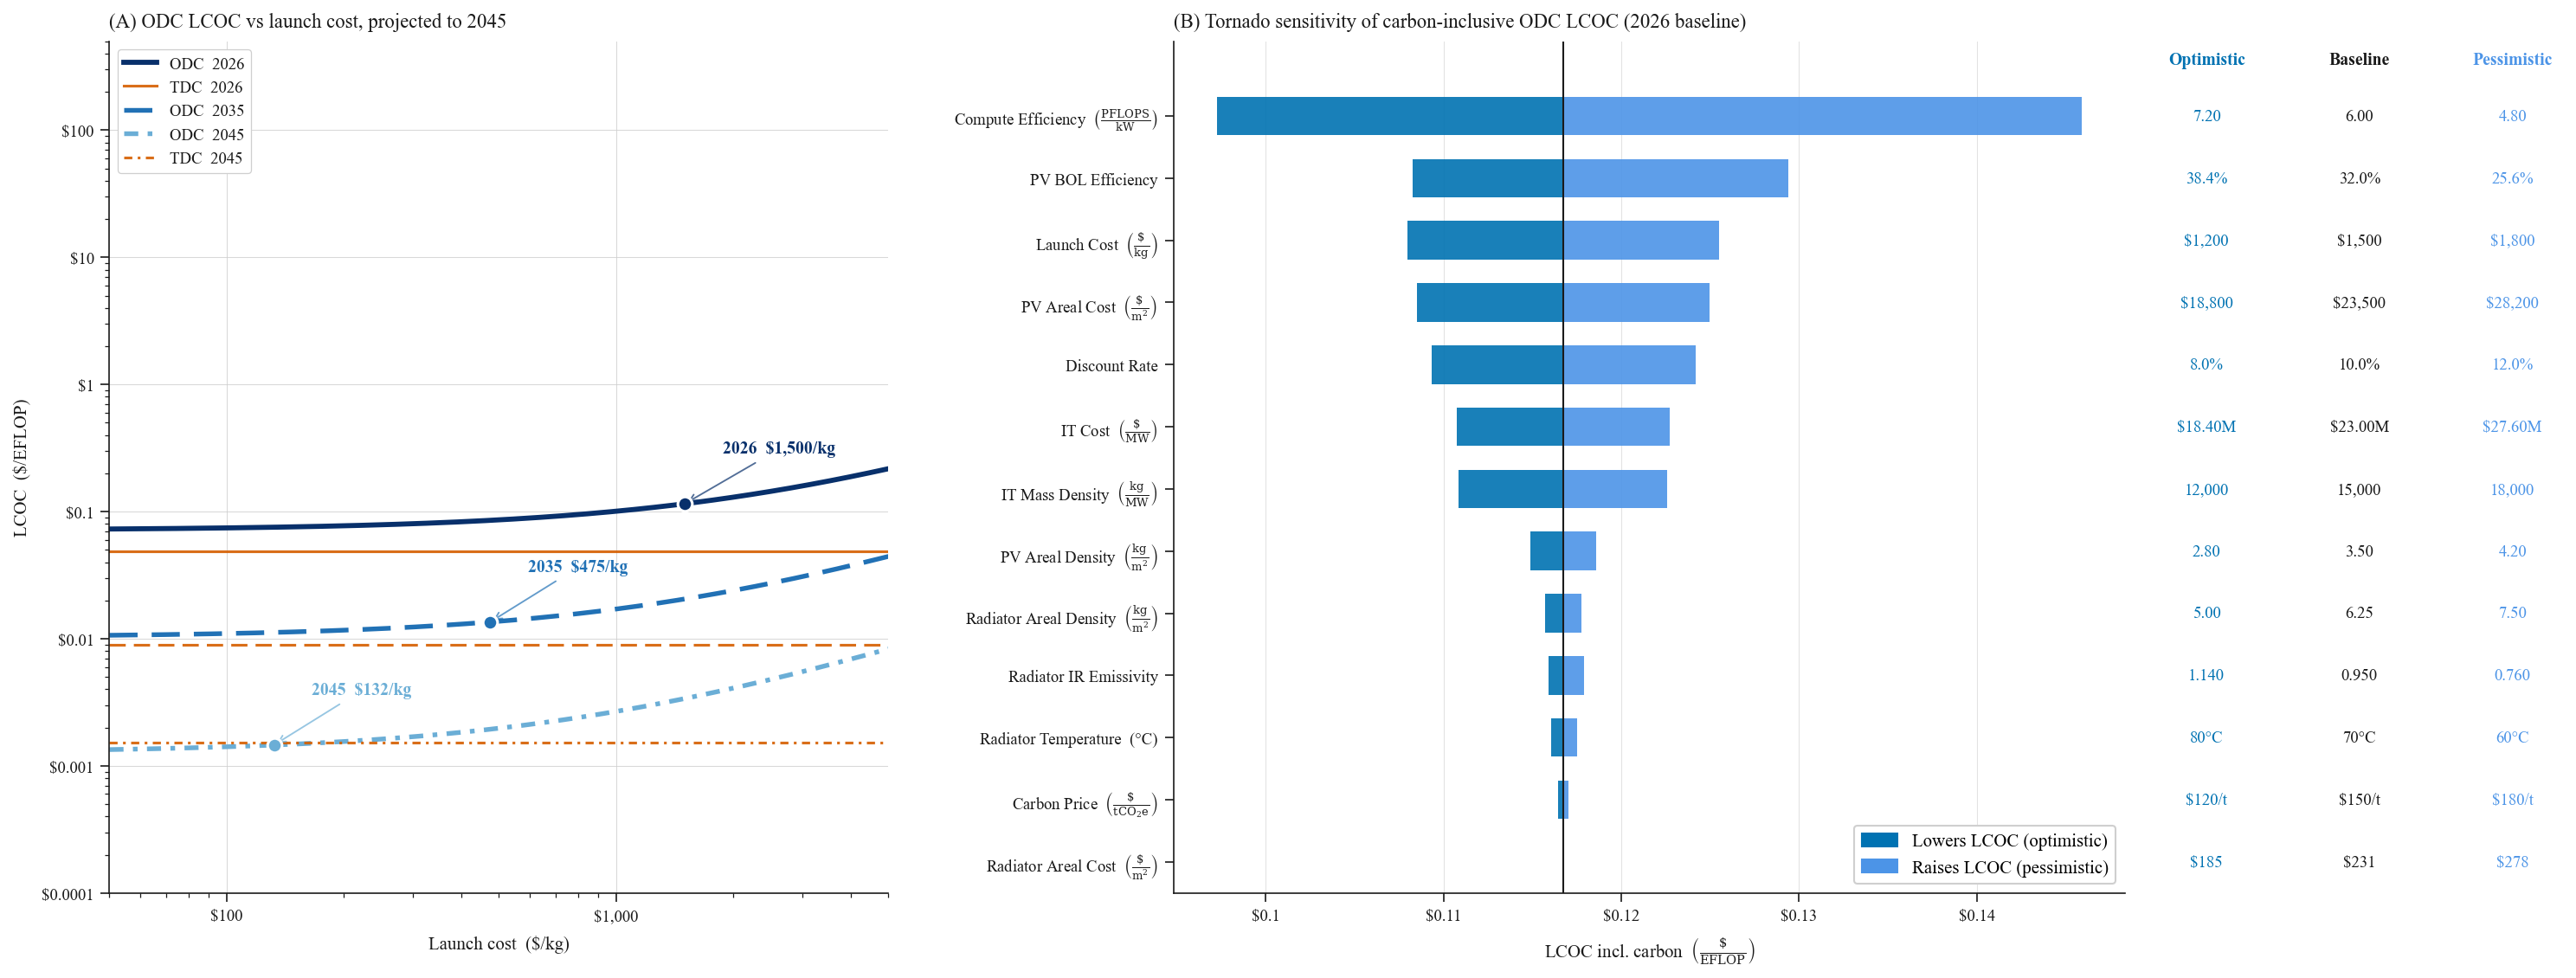

In [37]:
# =============================================================================
# COMBINED PAPER FIGURE 2  (paste AFTER the tornado cell and the projection cell)
#   (A) ODC LCOC vs launch cost, projected to 2045        [left]
#   (B) Tornado sensitivity of ODC LCOC (2026 baseline)   [right, + value table]
# Reuses `bars`, `base_lcoc`, `format_param_value` (tornado cell) and
# evolve_scenario / calculate_lcoc / terrestrial_evolved / LR_BASELINE (projection).
#
# COLOR NOTE: the tornado bars/table do NOT reuse the ODC blue / TDC orange.
# Those identity colors are reserved for the sweep panel; the tornado instead maps
# LCOC DIRECTION -> green (down/favorable) vs purple (up/unfavorable), colorblind-safe.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Tornado direction colors (Okabe-Ito; distinct from ODC blue and TDC vermillion)
LCOC_DOWN = "#0072B2"   # bluish green  : parameter shift LOWERS LCOC (optimistic)
LCOC_UP   = "#4C94E7"   # reddish purple: parameter shift RAISES LCOC (pessimistic)

fig = plt.figure(figsize=(20, 8.2))
fig.patch.set_facecolor(BG)
gsL = fig.add_gridspec(1, 1, left=0.045, right=0.345, top=0.90, bottom=0.10)
gsR = fig.add_gridspec(1, 2, left=0.455, right=0.990, top=0.90, bottom=0.10,
                       width_ratios=[2.35, 1.05], wspace=0.02)
axS    = fig.add_subplot(gsL[0, 0])   # launch-cost sweep
axT    = fig.add_subplot(gsR[0, 0])   # tornado bars
ax_tbl = fig.add_subplot(gsR[0, 1])   # value table

# ------------------------------------------------- (A) launch-cost sweep ------
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
yr_colors = {'2026': '#08306b', '2035': '#2171b5', '2045': '#6baed6'}  # ODC blue ramp
yr_styles = {'2026': 'solid', '2035': (0, (6, 3)), '2045': (0, (3, 2, 1, 2))}
yr_lw     = {'2026': 2.8, '2035': 2.6, '2045': 2.6}

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_BASELINE)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_BASELINE)
    lcocs = np.array([calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
                      for lc in launch_costs])
    col, ls, lw = yr_colors[yr_label], yr_styles[yr_label], yr_lw[yr_label]
    axS.plot(launch_costs, lcocs, color=col, linewidth=lw, linestyle=ls,
             label=f'ODC  {yr_label}')
    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    axS.plot(nom_lc, nom_lcoc, 'o', color=col, markersize=8, zorder=10,
             markeredgecolor=BG, markeredgewidth=1.5)
    axS.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg', xy=(nom_lc, nom_lcoc),
                 xytext=(nom_lc * 1.25, nom_lcoc * 2.5), fontsize=9.5, color=col,
                 fontfamily=FONT, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=col, alpha=0.7, lw=0.9))
    axS.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.5, linestyle=ls, alpha=0.9,
                label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = axS.legend(loc='upper left', frameon=True, framealpha=1.0,
                 edgecolor=GRID, facecolor='white', prop={'family': FONT, 'size': 9})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)
style_axes(axS, fig, title='(A) ODC LCOC vs launch cost, projected to 2045',
           xlabel='Launch cost  ($/kg)', ylabel='LCOC  ($/EFLOP)',
           x_log=True, y_log=True, xlim=(50, 5000), ylim=(0.0001, 500),
           x_dollar=True, y_dollar=True)

# ------------------------------------------------------- (B) tornado ----------
bar_h = 0.62
for i, (label, attr, opt_l, base_l_, pes_l, swing, ov, bv, pv) in enumerate(bars):
    axT.barh(i, opt_l - base_lcoc, left=base_lcoc, height=bar_h, color=LCOC_DOWN, alpha=0.9, zorder=3)
    axT.barh(i, pes_l - base_lcoc, left=base_lcoc, height=bar_h, color=LCOC_UP,   alpha=0.9, zorder=3)
axT.axvline(base_lcoc, color=INK, linewidth=1.0, zorder=5)
style_axes(axT, fig, title='(B) Tornado sensitivity of carbon-inclusive ODC LCOC (2026 baseline)',
           xlabel=r'LCOC incl. carbon  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=False, y_dollar=False, x_dollar=True)
axT.set_yticks(range(len(bars)))
axT.set_yticklabels([b[0] for b in bars], fontfamily=FONT, color=INK, fontsize=9)
axT.tick_params(axis='y', pad=4)
axT.grid(axis='y', alpha=0)
axT.grid(axis='x', color=GRID, alpha=0.6, linewidth=0.5)
axT.set_ylim(len(bars) - 0.5, -1.2)
axT.legend(handles=[mpatches.Patch(color=LCOC_DOWN, label='Lowers LCOC (optimistic)'),
                    mpatches.Patch(color=LCOC_UP,   label='Raises LCOC (pessimistic)')],
           loc='lower right', frameon=True, framealpha=1.0, edgecolor=GRID,
           facecolor='white', fontsize=8.5, prop={'family': FONT})

# ------------------------------------------- value table (Opt / Base / Pes) ---
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.2)
ax_tbl.axis('off')
col_x = {'opt': 0.16, 'base': 0.52, 'pes': 0.88}
for x, header, ccol in [(col_x['opt'], 'Optimistic',  LCOC_DOWN),
                        (col_x['base'], 'Baseline',   INK),
                        (col_x['pes'], 'Pessimistic', LCOC_UP)]:
    ax_tbl.text(x, -0.9, header, ha='center', va='center', fontsize=9.5,
                color=ccol, fontfamily=FONT, fontweight='bold')
for i, (label, attr, opt_l, base_l_, pes_l, swing, opt_val, base_val, pes_val) in enumerate(bars):
    ax_tbl.text(col_x['opt'],  i, format_param_value(attr, opt_val),
                ha='center', va='center', fontsize=9, color=LCOC_DOWN, fontfamily=FONT)
    ax_tbl.text(col_x['base'], i, format_param_value(attr, base_val),
                ha='center', va='center', fontsize=9, color=INK, fontfamily=FONT)
    ax_tbl.text(col_x['pes'],  i, format_param_value(attr, pes_val),
                ha='center', va='center', fontsize=9, color=LCOC_UP, fontfamily=FONT)

plt.show()

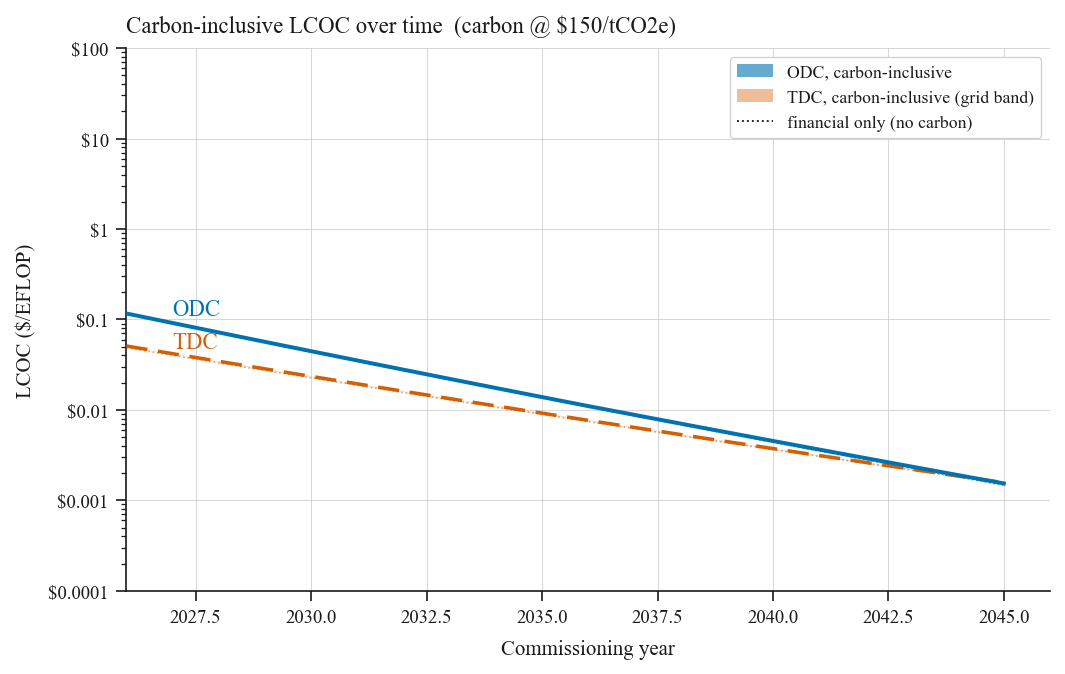

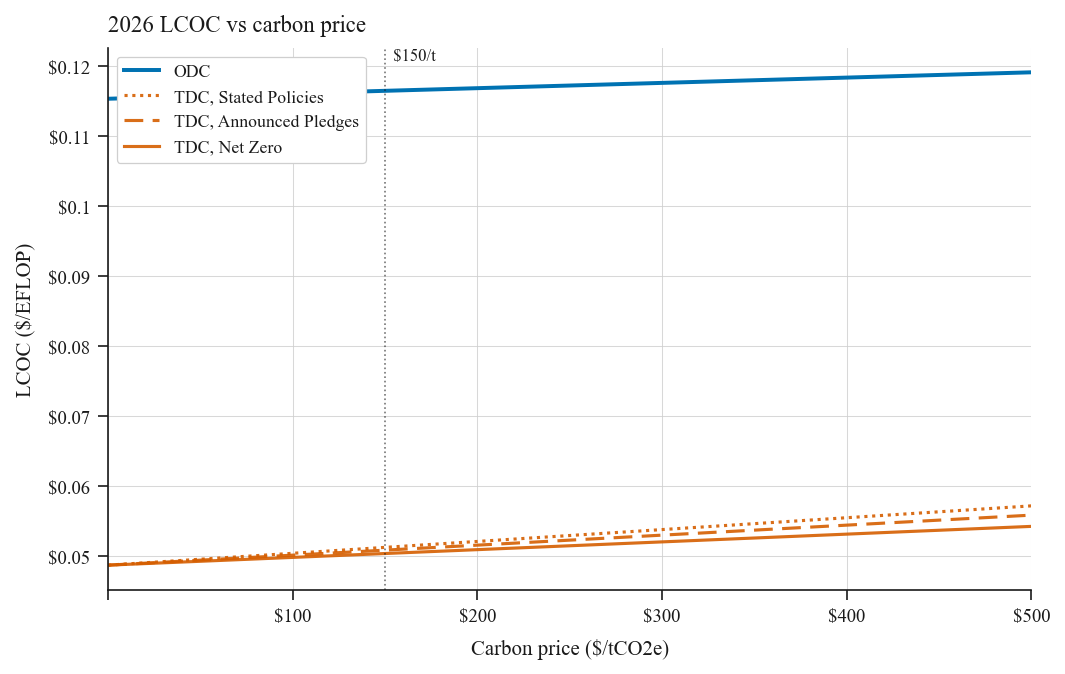

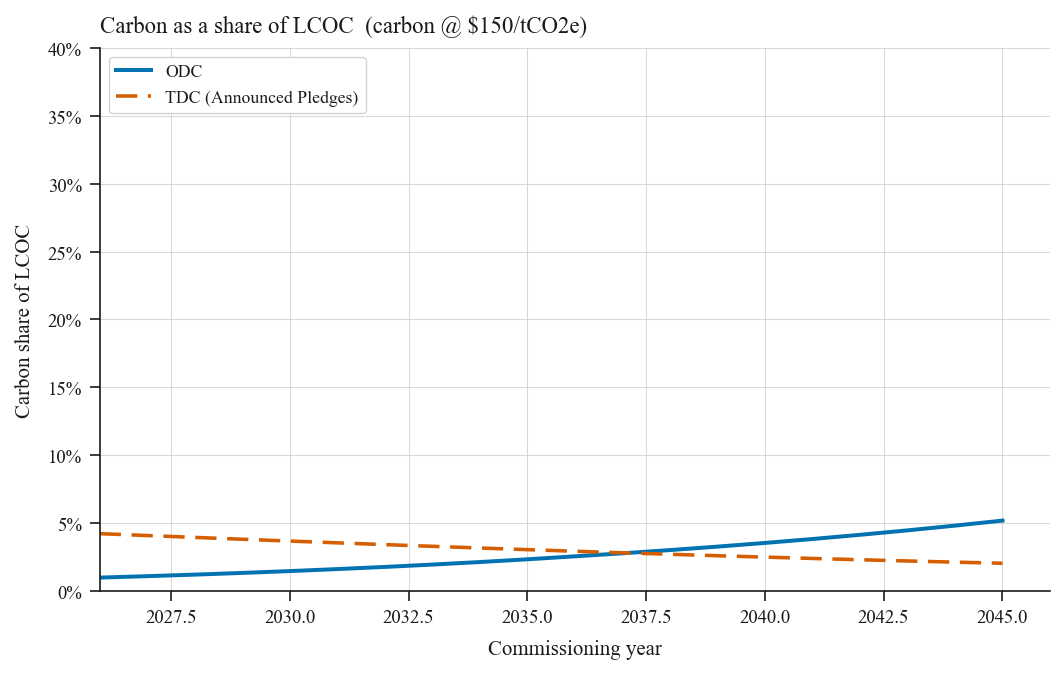

Carbon price $150/tCO2e | forcing mult 1

2026:
  ODC  fin $0.1153  +carbon $0.0011  = $0.1165  (carbon 1%)
  TDC  Stated Policies   $0.0487  +carbon $0.0025  = $0.0513  (carbon 5%)
  TDC  Announced Pledges $0.0487  +carbon $0.0021  = $0.0509  (carbon 4%)
  TDC  Net Zero          $0.0487  +carbon $0.0017  = $0.0504  (carbon 3%)

2045:
  ODC  fin $0.0015  +carbon $0.0001  = $0.0015  (carbon 5%)
  TDC  Stated Policies   $0.0015  +carbon $0.0001  = $0.0016  (carbon 4%)
  TDC  Announced Pledges $0.0015  +carbon $0.0000  = $0.0016  (carbon 2%)
  TDC  Net Zero          $0.0015  +carbon $0.0000  = $0.0015  (carbon 1%)



In [38]:
# ============================================================================
# Carbon-inclusive LCOC over time
# LCOC_total = LCOC_financial + (NPV carbon cost)/(NPV compute).
# Financial side held at BASELINE learning rates (reuses odc_nom / tdc_nom).
# New axes: grid decarbonization scenario (TDC only) and carbon price.
# ============================================================================

# ---- assumptions (edit here) ------------------------------------------------
GRID_2026          = GRID_INTENSITY_2026   # tCO2e/MWh -- Section 1d (single source of truth)
BASE_CARBON_PRICE  = CARBON_PRICE          # $/tCO2e -- Section 1d (single source of truth)
CARBON_PRICE_GROWTH = 0.0     # real %/yr (0 = flat real price)
ODC_FORCING_MULT   = 1.0      # >1 tests high-altitude underestimate (Dominguez 2024)

# IEA WEO 2025 scenarios as annual grid-intensity decline rates, fitted to the
# 2024->2040 endpoints in the figure. Affects TDC only (ODC is grid-independent).
GRID_SCENARIOS = {
    'Stated Policies':   0.05,   # slow decarb  (keeps TDC dirty -> favours ODC)
    'Announced Pledges': 0.09,   # central
    'Net Zero':          0.16,   # fast decarb  (hardest on ODC's relative case)
}

def carbon_price(cal_year):
    return BASE_CARBON_PRICE * (1 + CARBON_PRICE_GROWTH) ** (cal_year - START_YEAR)

# ---- shared discounting / compute -------------------------------------------
R    = BASELINE.discount_rate
disc = 1.0 / (1 + R) ** np.arange(LIFETIME_YR)

# NPV of compute (EFLOP) for a system commissioned at each offset (gamma grows)
npv_compute = np.array([
    (annual_eflop(evolve_scenario(BASELINE, yo, LR_BASELINE)) * disc).sum()
    for yo in year_offsets
])

def _price_vec(Y):
    return np.array([carbon_price(Y + i) for i in range(LIFETIME_YR)])

# ---- ODC carbon adder (grid-independent; emissions fixed over calendar time)--
_op = odc_carbon_result['profile']
odc_annual_t = (np.array(_op['embodied_spike'])
                + ODC_FORCING_MULT * np.array(_op['launch_spike']))   # tCO2e/yr

odc_carbon_adder = np.array([
    (odc_annual_t * _price_vec(START_YEAR + yo) * disc).sum() / npv_compute[k]
    for k, yo in enumerate(year_offsets)
])

# ---- TDC carbon adder (per grid scenario) -----------------------------------
def _tdc_annual(yo, decarb):
    g0 = GRID_2026 * (1 - decarb) ** yo          # grid at commissioning
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=g0, grid_decarb=decarb))
    return np.array(tc['profile']['embodied_spike']) + np.array(tc['profile']['operational'])

tdc_carbon_adder = {}
for name, decarb in GRID_SCENARIOS.items():
    tdc_carbon_adder[name] = np.array([
        (_tdc_annual(yo, decarb) * _price_vec(START_YEAR + yo) * disc).sum() / npv_compute[k]
        for k, yo in enumerate(year_offsets)
    ])

# ---- carbon-inclusive LCOC --------------------------------------------------
odc_ci = odc_nom + odc_carbon_adder
tdc_ci = {name: tdc_nom + add for name, add in tdc_carbon_adder.items()}


# ============================== FIGURE 1 =====================================
# Carbon-inclusive LCOC over time; TDC band spans grid scenarios.
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.fill_between(years_calendar, tdc_ci['Net Zero'], tdc_ci['Stated Policies'],
                color=TDC_COLOR, alpha=0.15, zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_ci['Announced Pledges'], color=TDC_COLOR,
        lw=1.7, ls=(0, (6, 3)), zorder=4)
ax.plot(years_calendar, odc_ci, color=ODC_COLOR, lw=1.9, zorder=5)

# financial-only references (no carbon)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, lw=0.8, ls=':', alpha=0.6, zorder=3)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, lw=0.8, ls=':', alpha=0.6, zorder=3)

ax.text(2027, odc_ci[0]*1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT, fontsize=11, va='center')
ax.text(2027, tdc_ci['Announced Pledges'][0]*1.12, 'TDC', color=TDC_COLOR,
        fontfamily=FONT, fontsize=11, va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.6, label='ODC, carbon-inclusive'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.4, label='TDC, carbon-inclusive (grid band)'),
    plt.Line2D([0],[0], color=INK, ls=':', lw=0.9, label='financial only (no carbon)'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True, framealpha=1.0,
                edgecolor=GRID, facecolor='white', fontsize=8.5,
                prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig, title=f'Carbon-inclusive LCOC over time  (carbon @ ${BASE_CARBON_PRICE:.0f}/tCO2e)',
           xlabel='Commissioning year', ylabel='LCOC ($/EFLOP)',
           xlim=(2026, 2046), ylim=(0.0001, 100))
plt.tight_layout()
fig.savefig('lcoc_carbon_over_time.pdf'); fig.savefig('lcoc_carbon_over_time.png')
plt.show()


# ============================== FIGURE 2 =====================================
# 2026 snapshot: how carbon price moves LCOC (linear in price).
prices = np.linspace(0, 500, 200)
odc_coeff = (odc_annual_t * disc).sum() / npv_compute[0]
odc_sweep = odc_nom[0] + prices * odc_coeff

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(prices, odc_sweep, color=ODC_COLOR, lw=1.9, label='ODC')

tdc_styles = {'Stated Policies': (0,(1,1.5)), 'Announced Pledges': (0,(6,3)), 'Net Zero': 'solid'}
for name, decarb in GRID_SCENARIOS.items():
    coeff = (_tdc_annual(0, decarb) * disc).sum() / npv_compute[0]
    ax.plot(prices, tdc_nom[0] + prices*coeff, color=TDC_COLOR, lw=1.5,
            ls=tdc_styles[name], alpha=0.9, label=f'TDC, {name}')

ax.axvline(BASE_CARBON_PRICE, color=INK, lw=0.8, ls=':', alpha=0.6)
ax.text(BASE_CARBON_PRICE, ax.get_ylim()[1], f'  ${BASE_CARBON_PRICE:.0f}/t',
        color=INK, fontfamily=FONT, fontsize=8, va='top')

leg = ax.legend(loc='upper left', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig, title='2026 LCOC vs carbon price',
           xlabel='Carbon price ($/tCO2e)', ylabel='LCOC ($/EFLOP)',
           y_log=False, x_dollar=True, xlim=(0, 500))
plt.tight_layout()
fig.savefig('lcoc_vs_carbon_price_2026.pdf'); fig.savefig('lcoc_vs_carbon_price_2026.png')
plt.show()


# ============================== FIGURE 3 =====================================
# Carbon as a share of total LCOC over time.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(years_calendar, 100*odc_carbon_adder/odc_ci, color=ODC_COLOR, lw=1.9, label='ODC')
ax.plot(years_calendar, 100*tdc_carbon_adder['Announced Pledges']/tdc_ci['Announced Pledges'],
        color=TDC_COLOR, lw=1.7, ls=(0,(6,3)), label='TDC (Announced Pledges)')

leg = ax.legend(loc='upper left', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
style_axes(ax, fig, title=f'Carbon as a share of LCOC  (carbon @ ${BASE_CARBON_PRICE:.0f}/tCO2e)',
           xlabel='Commissioning year', ylabel='Carbon share of LCOC',
           y_log=False, y_dollar=False, xlim=(2026, 2046))
ax.set_ylim(0, max(40, 1.15*100*np.max(tdc_carbon_adder['Stated Policies']/tdc_ci['Stated Policies'])))
plt.tight_layout()
fig.savefig('carbon_share_over_time.pdf'); fig.savefig('carbon_share_over_time.png')
plt.show()


# ---- quick numeric readout --------------------------------------------------
print(f"Carbon price ${BASE_CARBON_PRICE:.0f}/tCO2e | forcing mult {ODC_FORCING_MULT:g}\n")
for label, k in [('2026', 0), ('2045', 19)]:
    print(f"{label}:")
    print(f"  ODC  fin ${odc_nom[k]:.4f}  +carbon ${odc_carbon_adder[k]:.4f}"
          f"  = ${odc_ci[k]:.4f}  (carbon {100*odc_carbon_adder[k]/odc_ci[k]:.0f}%)")
    for name in GRID_SCENARIOS:
        print(f"  TDC  {name:<17} ${tdc_nom[k]:.4f}  +carbon ${tdc_carbon_adder[name][k]:.4f}"
              f"  = ${tdc_ci[name][k]:.4f}  (carbon {100*tdc_carbon_adder[name][k]/tdc_ci[name][k]:.0f}%)")
    print()

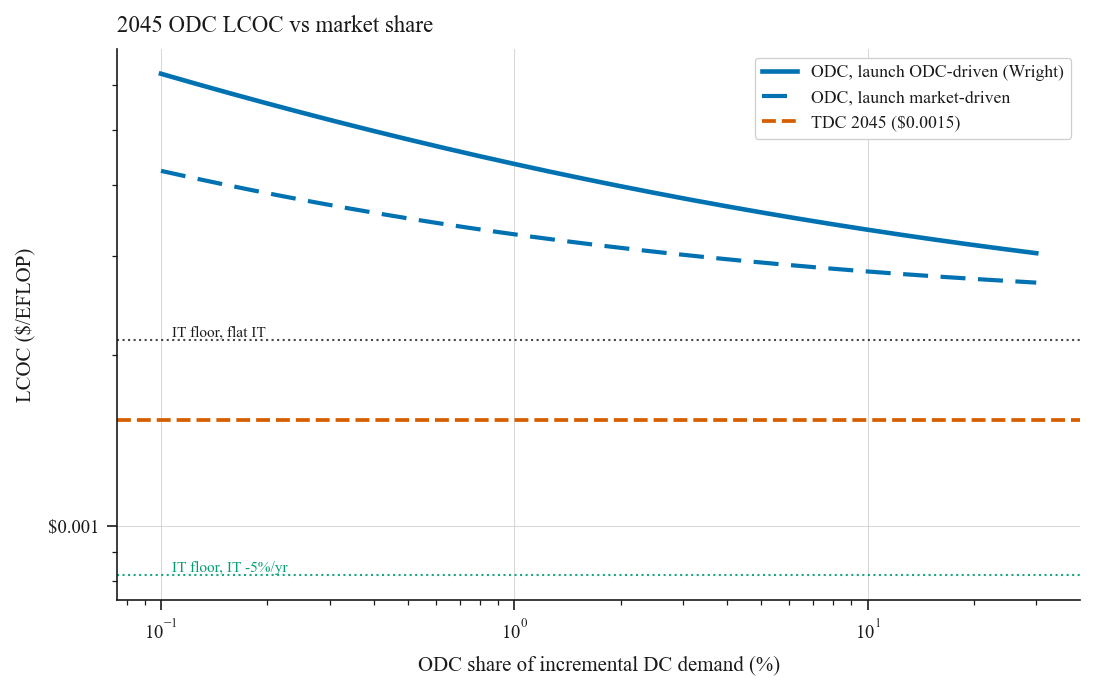

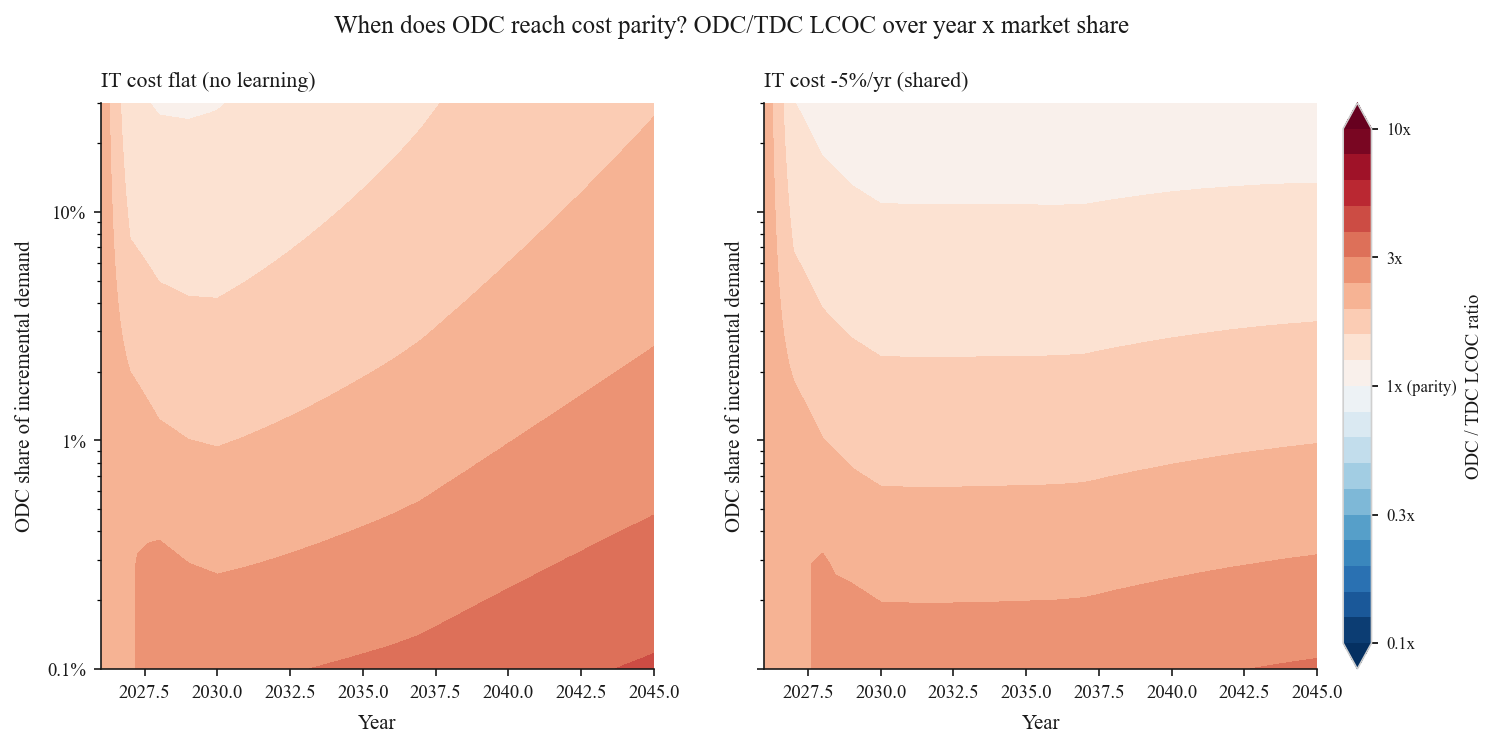

2045 TDC reference: $0.0015/EFLOP
2045 ODC IT-only floor: flat IT $0.0021 | IT -5%/yr $0.0008
  2045 parity (flat IT, ODC-driven launch): none within 30%
  2045 parity (IT -5%/yr, ODC-driven launch): none within 30%


In [39]:
# =============================================================================
# 8d (v2). Demand growth -> ODC market share -> learning -> LCOC
#   - launch learning shown for BOTH experience bases: 'market' (calendar; ODC
#     rides the broader launch market, share-independent) and 'odc' (Wright's law
#     on ODC cumulative capacity). Truth is between.
#   - IT-cost floor drawn explicitly (flat IT vs a small shared IT learning rate).
#   - 2045 share slice PLUS a year x share contour of the ODC/TDC LCOC ratio,
#     with the parity frontier (ratio = 1) overlaid.
# =============================================================================
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

# ---- demand path (unchanged) ------------------------------------------------
def dc_demand_GW(year):
    y = np.asarray(year, dtype=float); D0 = 120.0
    out = np.empty_like(y)
    for k, yr in np.ndenumerate(y):
        if yr <= 2030:   out[k] = D0 * 1.13 ** (yr - 2026)
        elif yr <= 2037: out[k] = D0 * 1.13**4 * 1.07 ** (yr - 2030)
        else:            out[k] = D0 * 1.13**4 * 1.07**7 * 1.04 ** (yr - 2037)
    return out

D_2026 = float(dc_demand_GW(2026))
def incremental_GW(year):
    return float(dc_demand_GW(year)) - D_2026

# ---- learning assumptions ---------------------------------------------------
C0_GW          = 0.10     # anchor cumulative ODC capacity [GW]
LR_LAUNCH      = 0.15     # Wright: 15% / doubling (ODC-driven launch case)
LR_PV          = 0.20     # Swanson: 20% / doubling (space PV, ODC-driven)
IT_LEARN_FLAT  = 0.0      # Trent's assumption
IT_LEARN_SMALL = 0.05     # a shared IT $/MW learning rate (same in all scenarios)

def _doublings(C):
    return max(np.log2(max(C, C0_GW) / C0_GW), 0.0)

def odc_lcoc(year, share, it_learn=0.0, launch_mode='market'):
    yo = year - START_YEAR
    d  = _doublings(share * incremental_GW(year))
    pv_cost = BASELINE.pv_areal_cost * (1 - LR_PV) ** d            # ODC-driven
    if launch_mode == 'odc':
        launch = BASELINE.launch_cost_per_kg * (1 - LR_LAUNCH) ** d
    else:                                                          # 'market'
        launch = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch) ** yo
    gamma  = BASELINE.gamma_PFLOPS_per_kW * (1 + LR_BASELINE.gamma_growth) ** yo
    pv_eff = min(0.35, BASELINE.pv_eff_BOL + LR_BASELINE.pv_eff_pp * yo)
    it_c   = BASELINE.it_cost_per_MW * (1 - it_learn) ** yo
    s = replace(BASELINE, launch_cost_per_kg=float(launch), pv_areal_cost=float(pv_cost),
                gamma_PFLOPS_per_kW=gamma, pv_eff_BOL=pv_eff, it_cost_per_MW=it_c)
    return calculate_lcoc(s)['lcoc']

def odc_floor(year, it_learn, launch_mode):
    """Asymptotic ODC LCOC as share -> large: PV -> 0; launch -> 0 (odc) or market (calendar)."""
    yo = year - START_YEAR
    launch = 0.0 if launch_mode == 'odc' else BASELINE.launch_cost_per_kg*(1-LR_BASELINE.launch)**yo
    s = replace(BASELINE, launch_cost_per_kg=float(launch), pv_areal_cost=0.0,
                gamma_PFLOPS_per_kW=BASELINE.gamma_PFLOPS_per_kW*(1+LR_BASELINE.gamma_growth)**yo,
                pv_eff_BOL=min(0.35, BASELINE.pv_eff_BOL + LR_BASELINE.pv_eff_pp*yo),
                it_cost_per_MW=BASELINE.it_cost_per_MW*(1-it_learn)**yo)
    return calculate_lcoc(s)['lcoc']

def tdc_lcoc_year(year):
    return terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, year - START_YEAR, LR_BASELINE)


# ============================== FIGURE 1 =====================================
# 2045 ODC LCOC vs share: two launch experience bases + IT-cost floors.
YEAR   = 2045
shares = np.logspace(np.log10(0.001), np.log10(0.30), 200)
odc_market = np.array([odc_lcoc(YEAR, s, IT_LEARN_FLAT, 'market') for s in shares])
odc_drive  = np.array([odc_lcoc(YEAR, s, IT_LEARN_FLAT, 'odc')    for s in shares])
tdc_ref     = tdc_lcoc_year(YEAR)
floor_flat  = odc_floor(YEAR, IT_LEARN_FLAT,  'odc')
floor_learn = odc_floor(YEAR, IT_LEARN_SMALL, 'odc')

fig, ax = plt.subplots(figsize=(7.4, 4.7))
ax.plot(shares*100, odc_drive,  color=ODC_COLOR, lw=2.2, label='ODC, launch ODC-driven (Wright)')
ax.plot(shares*100, odc_market, color=ODC_COLOR, lw=2.0, ls=(0,(6,3)),
        label='ODC, launch market-driven')
ax.axhline(tdc_ref, color=TDC_COLOR, lw=1.8, ls='--', label=f'TDC 2045 (${tdc_ref:.4f})')
ax.axhline(floor_flat,  color=INK,       lw=1.0, ls=':', alpha=0.8)
ax.axhline(floor_learn, color='#009E73', lw=1.0, ls=':', alpha=0.9)
ax.text(0.105, floor_flat,  ' IT floor, flat IT',            va='bottom', ha='left', color=INK,       fontsize=7.4, fontfamily=FONT)
ax.text(0.105, floor_learn, f' IT floor, IT -{IT_LEARN_SMALL*100:.0f}%/yr', va='bottom', ha='left', color='#009E73', fontsize=7.4, fontfamily=FONT)

leg = ax.legend(loc='upper right', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)
style_axes(ax, fig, title='2045 ODC LCOC vs market share',
           xlabel='ODC share of incremental DC demand (%)',
           ylabel='LCOC ($/EFLOP)', y_log=True, x_log=True, x_dollar=False)
plt.tight_layout()
fig.savefig('share_slice_2045.pdf'); fig.savefig('share_slice_2045.png')
plt.show()


# ============================== FIGURE 2 (contour) ===========================
# ODC/TDC LCOC ratio over (year x share). Parity = ratio 1 (black line).
# Launch treated as ODC-driven so share is a real lever (optimistic launch case).
yrs_c    = np.arange(START_YEAR, START_YEAR + 20)              # 2026..2045
shares_c = np.logspace(np.log10(0.001), np.log10(0.30), 55)
tdc_row  = np.array([tdc_lcoc_year(y) for y in yrs_c])

def ratio_grid(it_learn, launch_mode='odc'):
    Z = np.empty((len(shares_c), len(yrs_c)))
    for i, sh in enumerate(shares_c):
        for j, y in enumerate(yrs_c):
            Z[i, j] = np.log10(odc_lcoc(y, sh, it_learn, launch_mode) / tdc_row[j])
    return Z

def _style_contour(ax, title):
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}%'))
    ax.set_facecolor(BG)
    for sd in ('top','right'): ax.spines[sd].set_visible(False)
    for sd in ('left','bottom'): ax.spines[sd].set_color(INK); ax.spines[sd].set_linewidth(0.8)
    ax.tick_params(colors=INK, labelsize=9, width=0.8)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    ax.set_xlabel('Year', fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.set_ylabel('ODC share of incremental demand', fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.set_title(title, fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.9), sharey=True)
fig.patch.set_facecolor(BG)
levels = np.linspace(-1, 1, 21)                                # log10 ratio: 0.1x .. 10x
panels = [(ax1, IT_LEARN_FLAT,  'IT cost flat (no learning)'),
          (ax2, IT_LEARN_SMALL, f'IT cost -{IT_LEARN_SMALL*100:.0f}%/yr (shared)')]
for ax, itl, ttl in panels:
    Z  = ratio_grid(itl)
    cf = ax.contourf(yrs_c, shares_c*100, Z, levels=levels, cmap='RdBu_r', extend='both')
    cl = ax.contour(yrs_c, shares_c*100, Z, levels=[0], colors=INK, linewidths=2.0)
    # if cl.collections and len(cl.allsegs[0]):
    ax.clabel(cl, fmt={0: 'parity'}, fontsize=8, inline=True)
    _style_contour(ax, ttl)

cbar = fig.colorbar(cf, ax=[ax1, ax2], fraction=0.046, pad=0.02,
                    ticks=[-1, -0.5, 0, 0.5, 1])
cbar.ax.set_yticklabels(['0.1x', '0.3x', '1x (parity)', '3x', '10x'],
                        fontfamily=FONT, color=INK, fontsize=8)
cbar.set_label('ODC / TDC LCOC ratio', fontfamily=FONT, color=INK, fontsize=9)
cbar.outline.set_edgecolor(GRID)

fig.suptitle('When does ODC reach cost parity? ODC/TDC LCOC over year x market share',
             fontsize=12, color=INK, fontfamily=FONT, x=0.5, y=1.0)
# fig.savefig('parity_contour.pdf', bbox_inches='tight')
# fig.savefig('parity_contour.png', bbox_inches='tight')
plt.show()


# ---- readout ----------------------------------------------------------------
print(f'2045 TDC reference: ${tdc_ref:.4f}/EFLOP')
print(f'2045 ODC IT-only floor: flat IT ${floor_flat:.4f} | IT -{IT_LEARN_SMALL*100:.0f}%/yr ${floor_learn:.4f}')
for itl in (IT_LEARN_FLAT, IT_LEARN_SMALL):
    pe = [s for s in shares if odc_lcoc(2045, s, itl, 'odc') <= tdc_ref]
    tag = 'flat IT' if itl == 0 else f'IT -{itl*100:.0f}%/yr'
    print(f'  2045 parity ({tag}, ODC-driven launch): '
          + (f'share >= {min(pe)*100:.2f}%' if pe else 'none within 30%'))

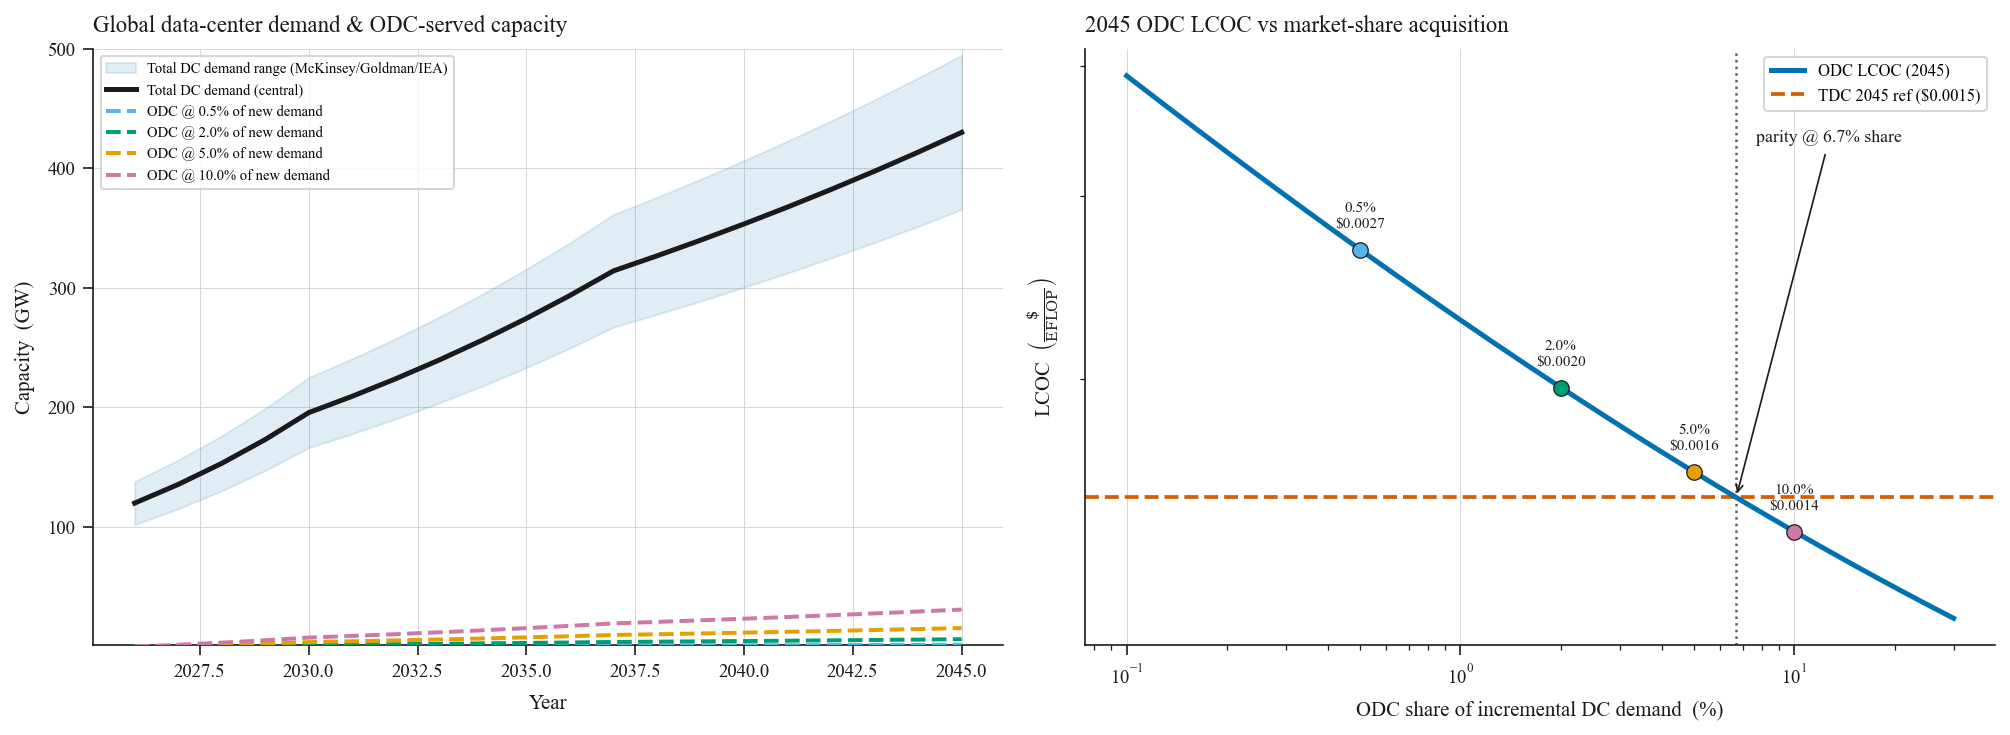

2045 demand: 430 GW  (incremental since 2026: 310 GW)
2045 reference values (consistent across ODC & TDC):
  gamma 85.4 PFLOPS/kW | PV eff 0.350 | IT $4.7M/MW | IT mass 8,409 kg/MW
  TDC 2045 reference LCOC: $0.0015/EFLOP

  share   cum GW    ODC LCOC   ODC/TDC
   0.5%     1.5 $   0.0027    1.73x
   2.0%     6.2 $   0.0020    1.28x
   5.0%    15.5 $   0.0016    1.06x
  10.0%    31.0 $   0.0014    0.93x

ODC<->TDC parity at ~6.69% share of incremental demand (~21 GW of ODC capacity)


In [46]:
# =============================================================================
# 8d. DC demand growth + ODC market-share -> learning -> LCOC   (two-panel)
# -----------------------------------------------------------------------------
# odc_lcoc_vs_share() starts from the consistent 2045 scenario,
# evolve_scenario(BASELINE, 19, LR_BASELINE), so IT $/MW and IT mass density
# carry their 2045 values (the SAME ones tdc_2045 uses), then overrides ONLY
# launch and PV cost with Wright's-law (deployment-scale) values. Panel A is the
# McKinsey/Goldman/IEA demand band + ODC-served capacity; Panel B is the 2045
# LCOC-vs-share slice with the parity share marked.
# =============================================================================

# ---- Total DC demand path (GW of IT capacity), source-anchored ----------------
def dc_demand_GW(year):
    """Central global DC capacity [GW]. Anchors: ~120 GW (2026) -> ~195 GW (2030,
    McKinsey midpoint) -> decelerating CAGR to ~430 GW (2045)."""
    y = np.asarray(year, dtype=float)
    D0 = 120.0  # 2026
    out = np.empty_like(y)
    for k, yr in np.ndenumerate(y):
        if yr <= 2030:
            out[k] = D0 * 1.13 ** (yr - 2026)            # ~13%/yr 2026-2030
        elif yr <= 2037:
            d2030 = D0 * 1.13 ** 4
            out[k] = d2030 * 1.07 ** (yr - 2030)         # ~7%/yr 2030-2037
        else:
            d2037 = D0 * 1.13 ** 4 * 1.07 ** 7
            out[k] = d2037 * 1.04 ** (yr - 2037)         # ~4%/yr 2037-2045
    return out

yrs = np.arange(2026, 2046)
D_base = dc_demand_GW(yrs)
D_low, D_high = 0.85 * D_base, 1.15 * D_base              # +/-15% source spread
D_2026 = dc_demand_GW(2026).item()
incremental = D_base - D_2026                              # demand added after 2026

SHARES = [0.005, 0.02, 0.05, 0.10]                        # ODC share of incremental demand
SHARE_COLORS = ['#56B4E9', '#009E73', '#E69F00', '#CC79A7']  # Okabe-Ito

# ---- Wright's-law learning on cumulative ODC capacity (Panel B) ---------------
C0_GW       = 0.10        # anchor cumulative ODC capacity [GW] (~first commercial fleet)
LR_LAUNCH   = 0.15        # 15% / doubling
LR_PV       = 0.20        # 20% / doubling (Swanson)
YR_OFFSET   = 19          # 2045 calendar offset for industry-wide gamma / TDC

# consistent 2045 reference scenario (gamma, PV eff, IT $/MW, IT mass density)
S_2045      = evolve_scenario(BASELINE, YR_OFFSET, LR_BASELINE)
gamma_2045  = S_2045.gamma_PFLOPS_per_kW
pv_eff_2045 = S_2045.pv_eff_BOL
tdc_2045    = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, YR_OFFSET, LR_BASELINE)
inc_2045    = incremental[-1]                              # GW added by 2045

def odc_lcoc_vs_share(share):
    """2045 ODC LCOC when ODCs serve `share` of incremental demand.
    Launch & PV fall via Wright's law on cumulative ODC capacity (deployment
    scale). gamma, PV efficiency, IT $/MW and IT mass density take their
    consistent 2045 calendar values (matching the TDC reference); radiator
    carries no learning."""
    C = np.maximum(share * inc_2045, C0_GW)
    doublings = np.log2(C / C0_GW)
    launch = BASELINE.launch_cost_per_kg * (1 - LR_LAUNCH) ** doublings
    pv     = BASELINE.pv_areal_cost      * (1 - LR_PV)     ** doublings
    # start from the consistent 2045 scenario, override ONLY launch + PV cost
    s = replace(S_2045, launch_cost_per_kg=float(launch), pv_areal_cost=float(pv))
    return calculate_lcoc(s)['lcoc']

share_grid = np.logspace(np.log10(0.001), np.log10(0.30), 240)
lcoc_grid  = np.array([odc_lcoc_vs_share(s) for s in share_grid])

# parity share (where ODC LCOC crosses TDC 2045)
parity_share = None
below = lcoc_grid <= tdc_2045
if below.any():
    j = np.argmax(below)
    if j > 0:
        x0, x1 = share_grid[j-1], share_grid[j]
        y0, y1 = lcoc_grid[j-1], lcoc_grid[j]
        parity_share = x0 + (tdc_2045 - y0) * (x1 - x0) / (y1 - y0)

# =============================================================================
# Figure
# =============================================================================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5.0))
fig.patch.set_facecolor(BG)

# ---- Panel A: demand forecast + ODC-served capacity (single GW axis) ---------
axA.fill_between(yrs, D_low, D_high, color=ODC_COLOR, alpha=0.12, zorder=1,
                 label='Total DC demand range (McKinsey/Goldman/IEA)')
axA.plot(yrs, D_base, color=INK, lw=2.4, zorder=4, label='Total DC demand (central)')
for s, col in zip(SHARES, SHARE_COLORS):
    axA.plot(yrs, s * incremental, color=col, lw=1.9, ls='--', zorder=3,
             label=f'ODC @ {s*100:.1f}% of new demand')
style_axes(axA, fig, title='Global data-center demand & ODC-served capacity',
           xlabel='Year', ylabel='Capacity  (GW)',
           y_log=False, y_dollar=False)
axA.set_ylim(1, 500)
axA.legend(fontsize=7.0, loc='upper left', framealpha=0.85,
           facecolor=BG, edgecolor=GRID)

# ---- Panel B: 2045 ODC LCOC vs market share ----------------------------------
axB.plot(share_grid * 100, lcoc_grid, color=ODC_COLOR, lw=2.4, zorder=3,
         label='ODC LCOC (2045)')
for s, col in zip(SHARES, SHARE_COLORS):
    v = odc_lcoc_vs_share(s)
    axB.scatter(s * 100, v, color=col, s=55, zorder=5, edgecolor=INK, linewidth=0.6)
    axB.annotate(f'{s*100:.1f}%\n${v:.4f}', xy=(s * 100, v),
                 xytext=(0, 9), textcoords='offset points',
                 ha='center', va='bottom', fontsize=7.4, color=INK, fontfamily=FONT)
axB.axhline(tdc_2045, color=TDC_COLOR, ls='--', lw=1.8, zorder=2,
            label=f'TDC 2045 ref (${tdc_2045:.4f})')
if parity_share is not None:
    axB.axvline(parity_share * 100, color=INK, ls=':', lw=1.2, alpha=0.7)
    axB.annotate(f'parity @ {parity_share*100:.1f}% share',
                 xy=(parity_share * 100, tdc_2045),
                 xytext=(parity_share * 100 * 1.15, tdc_2045 * 2.2),
                 fontsize=8.5, color=INK, fontfamily=FONT,
                 arrowprops=dict(arrowstyle='->', color=INK, lw=0.8))
style_axes(axB, fig, title='2045 ODC LCOC vs market-share acquisition',
           xlabel='ODC share of incremental DC demand  (%)',
           ylabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=True)
axB.set_xscale('log')
axB.legend(fontsize=8, loc='upper right', framealpha=0.85, facecolor=BG, edgecolor=GRID)

plt.tight_layout()
plt.show()

# ---- values behind Panel B ---------------------------------------------------
print(f'2045 demand: {D_base[-1]:.0f} GW  (incremental since 2026: {inc_2045:.0f} GW)')
print(f'2045 reference values (consistent across ODC & TDC):')
print(f'  gamma {gamma_2045:.1f} PFLOPS/kW | PV eff {pv_eff_2045:.3f} | '
      f'IT ${S_2045.it_cost_per_MW/1e6:.1f}M/MW | IT mass {S_2045.it_mass_density:,.0f} kg/MW')
print(f'  TDC 2045 reference LCOC: ${tdc_2045:.4f}/EFLOP\n')
print(f'{"share":>7} {"cum GW":>8} {"ODC LCOC":>11} {"ODC/TDC":>9}')
for s in SHARES:
    v = odc_lcoc_vs_share(s)
    print(f'{s*100:>6.1f}% {s*inc_2045:>7.1f} ${v:>9.4f} {v/tdc_2045:>7.2f}x')
if parity_share is not None:
    print(f'\nODC<->TDC parity at ~{parity_share*100:.2f}% share of incremental demand '
          f'(~{parity_share*inc_2045:.0f} GW of ODC capacity)')
else:
    print('\nNo parity within plotted share range')

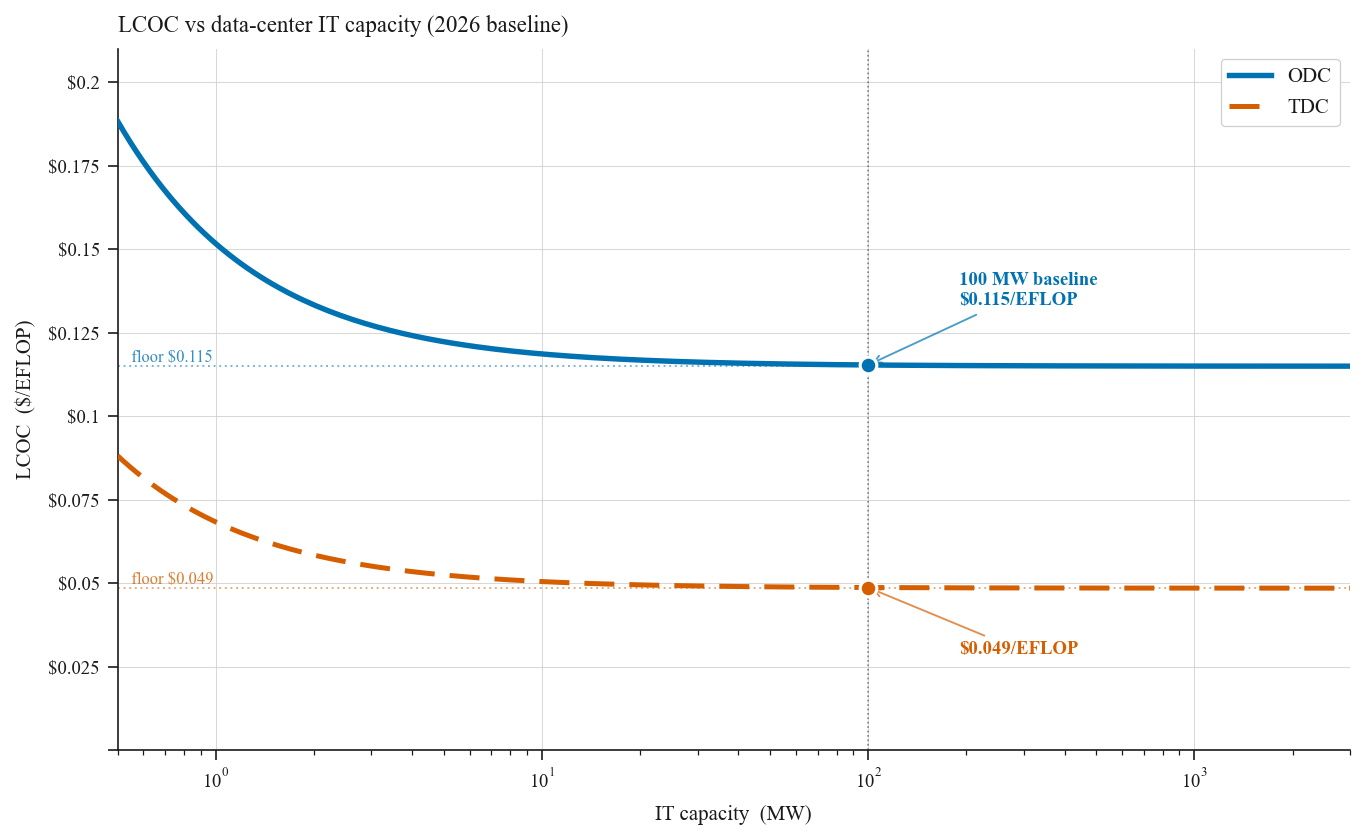

ODC 0.1883 (0.5 MW) -> floor 0.1150;  TDC floor 0.0485;  ODC floor is 2.4x TDC, no crossing.


In [40]:
# --- IT-CAPACITY SWEEP (v4 fix): drive capacity through the Scenario FIELD ---
# With the model cell above routing all capacity through q_compute(s), the sweep
# just replaces it_capacity_mw. PV/radiator/IT/launch all scale linearly, so ODC
# LCOC falls only as fixed labor + data dilute, then flattens to a floor ABOVE
# the TDC. No crossing -- the ODC's problem is per-unit economics, not scale.
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

caps_MW = np.logspace(np.log10(0.5), np.log10(3000), 200)
odc_lcoc = np.array([calculate_lcoc(replace(BASELINE, it_capacity_mw=float(C)))['lcoc']
                     for C in caps_MW])
tdc_lcoc = np.array([terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW,
                                      labor_per_kW_yr=ANNUAL_LABOR_COST / (C * 1000))
                     for C in caps_MW])

odc_100 = calculate_lcoc(replace(BASELINE, it_capacity_mw=100.0))['lcoc']
tdc_100 = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW,
                           labor_per_kW_yr=ANNUAL_LABOR_COST / (100 * 1000))
odc_floor, tdc_floor = odc_lcoc[-1], tdc_lcoc[-1]

fig, ax = plt.subplots(figsize=(9.2, 5.7))
ax.axhline(odc_floor, color=ODC_COLOR, lw=0.9, ls=(0, (1, 2)), alpha=0.55, zorder=2)
ax.axhline(tdc_floor, color=TDC_COLOR, lw=0.9, ls=(0, (1, 2)), alpha=0.55, zorder=2)
ax.text(0.52, odc_floor, f'  floor ${odc_floor:.3f}', color=ODC_COLOR, fontfamily=FONT,
        fontsize=8, va='bottom', ha='left', alpha=0.8)
ax.text(0.52, tdc_floor, f'  floor ${tdc_floor:.3f}', color=TDC_COLOR, fontfamily=FONT,
        fontsize=8, va='bottom', ha='left', alpha=0.8)
ax.plot(caps_MW, odc_lcoc, color=ODC_COLOR, lw=2.6, zorder=5, label='ODC')
ax.plot(caps_MW, tdc_lcoc, color=TDC_COLOR, lw=2.4, ls=(0, (6, 3)), zorder=5, label='TDC')
ax.axvline(100, color=INK, lw=0.8, ls=':', alpha=0.5, zorder=1)
ax.plot(100, odc_100, 'o', color=ODC_COLOR, ms=8, markeredgecolor=BG, markeredgewidth=1.5, zorder=7)
ax.plot(100, tdc_100, 'o', color=TDC_COLOR, ms=8, markeredgecolor=BG, markeredgewidth=1.5, zorder=7)
ax.annotate(f'100 MW baseline\n${odc_100:.3f}/EFLOP', xy=(100, odc_100),
            xytext=(190, odc_100 + 0.018), fontsize=9, color=ODC_COLOR, fontfamily=FONT,
            fontweight='bold', arrowprops=dict(arrowstyle='->', color=ODC_COLOR, alpha=0.7, lw=0.9))
ax.annotate(f'${tdc_100:.3f}/EFLOP', xy=(100, tdc_100),
            xytext=(190, tdc_100 - 0.02), fontsize=9, color=TDC_COLOR, fontfamily=FONT,
            fontweight='bold', arrowprops=dict(arrowstyle='->', color=TDC_COLOR, alpha=0.7, lw=0.9))
leg = ax.legend(loc='upper right', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', prop={'family': FONT, 'size': 10})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)
style_axes(ax, fig, title='LCOC vs data-center IT capacity (2026 baseline)',
    xlabel='IT capacity  (MW)', ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=False, x_dollar=False, y_dollar=True,
    xlim=(0.5, 3000), ylim=(0.0, 0.21))
plt.tight_layout()
plt.show()

print(f'ODC {odc_lcoc[0]:.4f} (0.5 MW) -> floor {odc_floor:.4f};  TDC floor {tdc_floor:.4f};  '
      f'ODC floor is {odc_floor/tdc_floor:.1f}x TDC, no crossing.')

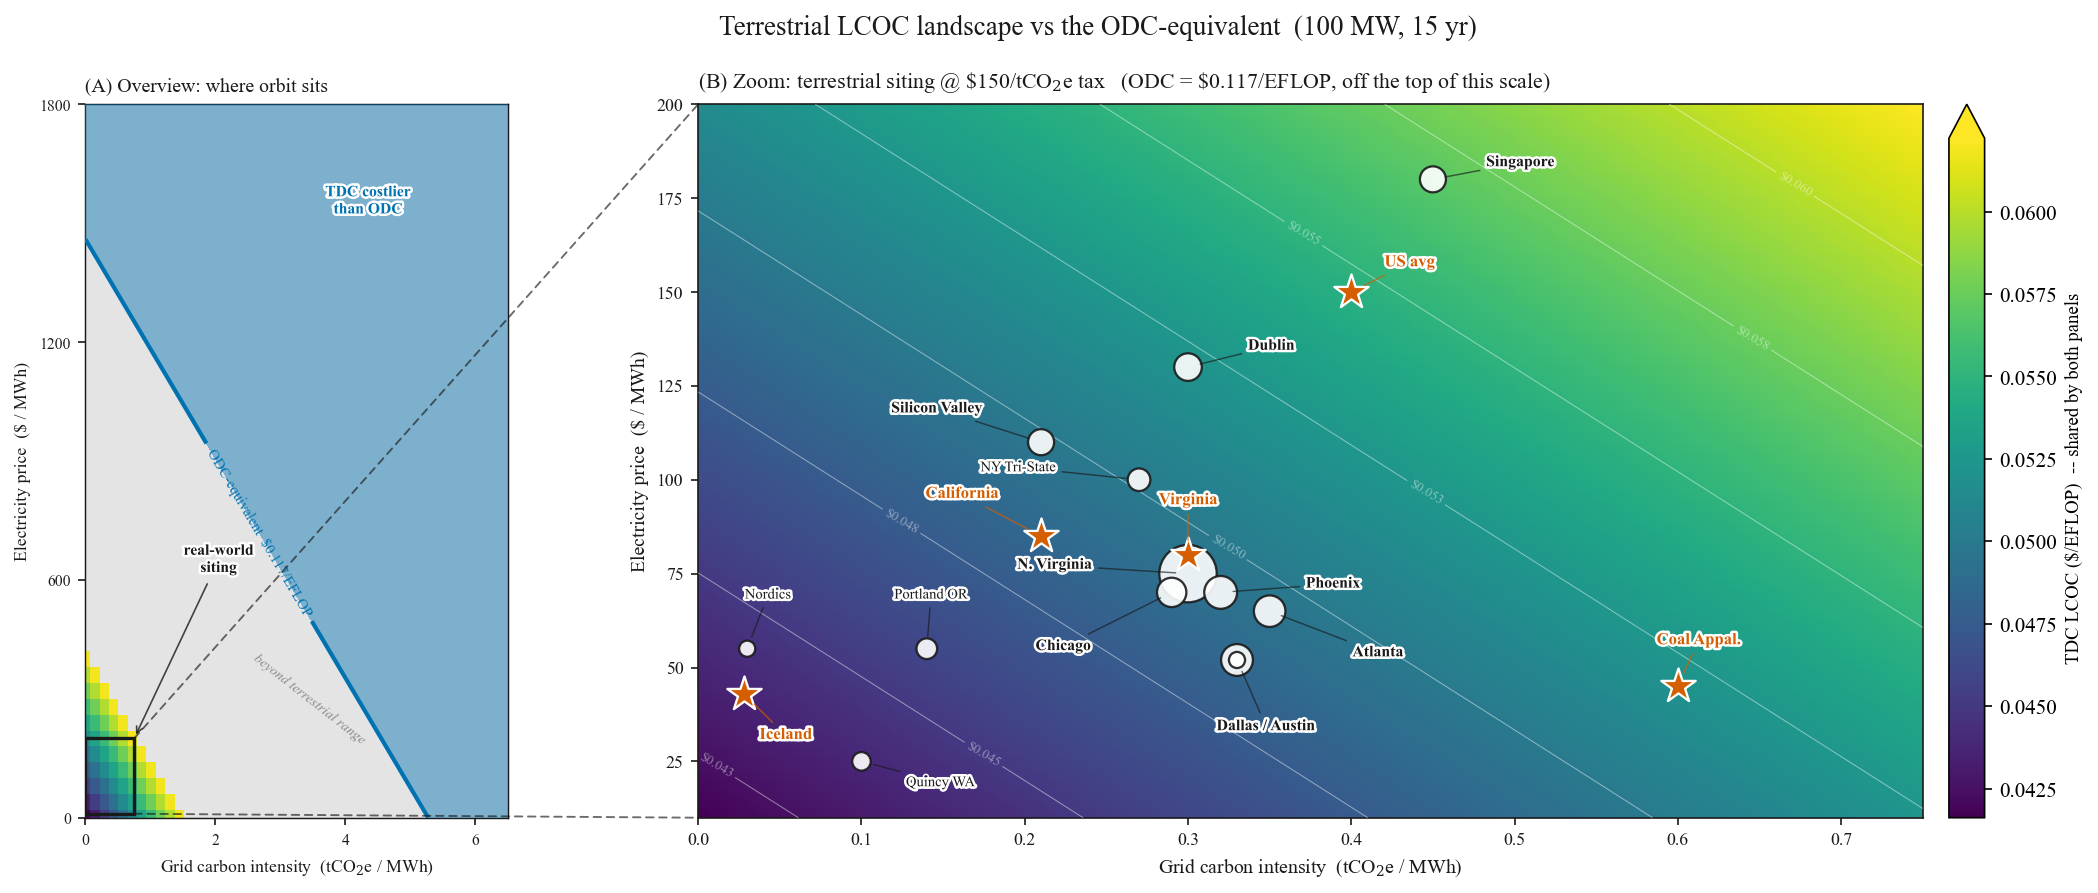

ODC-equivalent $0.1168/EFLOP ; terrestrial (zoom) range $0.0416-$0.0622/EFLOP


In [41]:
# =============================================================================
# FIGURE 1: Terrestrial LCOC over the (grid intensity x electricity price) plane
#   (A) OVERVIEW  -- the SAME map, zoomed OUT far enough that the ODC-equivalent
#       contour is actually on it. Real-world siting conditions occupy the small
#       boxed corner; everything above/right of the blue line is where a
#       terrestrial DC would have to sit to be as expensive as orbit.
#   (B) ZOOM      -- that corner box at full resolution, with real DC hubs
#       (bubbles, sized by MW) and sited archetypes (stars).
# Carbon tax fixed at TAX; grid intensity enters LCOC only via the tax term.
#
# ONE SHARED COLOUR SCALE (lo->hi, the terrestrial range) drives BOTH panels, so
# the boxed corner of (A) is coloured identically to (B). (A) clamps above it to
# a muted grey (set_over) instead of saturating, keeping the overview secondary.
#
# NOTE: Dallas and Austin have IDENTICAL (grid, price) coords in DC_HUBS, so their
# bubbles coincide exactly -> they share one leader label. All labels sit OUTSIDE
# the bubbles with leader lines + white halos (the old inline labels collided).
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib import colormaps

TAX = CARBON_PRICE
_disc = 1.0 / (1 + BASELINE.discount_rate) ** np.arange(LIFETIME_YR)
_npc  = (annual_eflop(BASELINE, k_load=CAPACITY_FACTOR) * _disc).sum()

_odc_t   = float(odc_carbon_result['total'])
_tdc_emb = float(tdc_carbon(carbon_scenario)['embodied_total'])
_Kop     = (carbon_scenario.it_capacity_mw * carbon_scenario.pue * carbon_scenario.load_factor
            * 8760.0 * carbon_scenario.mission_years)

def _tdc_lcoc(P, Gd):
    """TDC LCOC [$/EFLOP] on a (price, grid) mesh, at the fixed carbon tax."""
    cost = np.array([terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW, p_per_MWh=p)
                     for p in np.atleast_1d(P[:, 0])])[:, None]
    return cost + ((_tdc_emb + _Kop * Gd) * TAX) / _npc

ODC = calculate_lcoc(BASELINE)['lcoc'] + _odc_t * TAX / _npc     # site-independent scalar

# ---- zoom window = real-world siting conditions -----------------------------
ZG = (0.0, 0.75)          # grid intensity  tCO2e/MWh
ZP = (10.0, 200.0)        # electricity price  $/MWh

# ---- overview window: big enough to contain the ODC-equivalent contour -------
# (that contour runs from ~$1,613/MWh at g=0 down to ~5.95 tCO2e/MWh at cheap power)
OG = (0.0, 6.5)
OP = (0.0, 1800.0)

# ============================================================ overview data ---
_go = np.linspace(*OG, 46)                       # LOW resolution, on purpose
_po = np.linspace(*OP, 46)
GO, PO = np.meshgrid(_go, _po)
LCOC_O = _tdc_lcoc(PO, GO)

# ============================================================ zoom data -------
_gz = np.linspace(*ZG, 260)
_pz = np.linspace(*ZP, 260)
GZ, PZ = np.meshgrid(_gz, _pz)
LCOC_Z = _tdc_lcoc(PZ, GZ)
lo, hi = LCOC_Z.min(), LCOC_Z.max()              # <- the shared colour limits

DC_HUBS = [('N. Virginia',4040,0.30,75), ('Phoenix',1380,0.32,70), ('Dallas',1300,0.33,52),
           ('Atlanta',1280,0.35,65),     ('Chicago',1120,0.29,70), ('Dublin',1000,0.30,130),
           ('Silicon Valley',900,0.21,110), ('Singapore',900,0.45,180), ('NY Tri-State',700,0.27,100),
           ('Portland OR',600,0.14,55),  ('Quincy WA',500,0.10,25), ('Austin',400,0.33,52),
           ('Nordics',400,0.03,55)]
ARCH = [('Iceland',0.028,43), ('California',0.21,85), ('Virginia',0.30,80),
        ('US avg',0.40,150), ('Coal Appal.',0.60,45)]

# label offsets in POINTS, hand-tuned so nothing collides (leader lines connect)
HUB_OFF = {'N. Virginia': (-64, 4), 'Phoenix': (54, 4), 'Chicago': (-52, -26),
           'Atlanta': (52, -20), 'Dallas': (14, -32), 'Austin': None,   # shares Dallas' label
           'Dublin': (40, 10), 'Silicon Valley': (-50, 16), 'Singapore': (42, 8),
           'NY Tri-State': (-58, 6), 'Portland OR': (2, 26), 'Quincy WA': (38, -10),
           'Nordics': (10, 26)}
HUB_TEXT = {'Dallas': 'Dallas / Austin'}         # identical coords -> one label
ARCH_OFF = {'Iceland': (20, -20), 'California': (-38, 20), 'Virginia': (0, 26),
            'US avg': (28, 14), 'Coal Appal.': (10, 22)}

_cap = np.array([h[1] for h in DC_HUBS], float)
_sz  = 60 + (_cap - _cap.min()) / (_cap.max() - _cap.min()) * (760 - 60)
_HALO = [pe.withStroke(linewidth=2.4, foreground='white')]

# ---------------------------------------------------------------- figure -----
fig = plt.figure(figsize=(15.0, 6.3)); fig.patch.set_facecolor(BG)
gs  = fig.add_gridspec(1, 2, width_ratios=[0.66, 2.05], wspace=0.22,
                       left=0.050, right=0.905, top=0.87, bottom=0.115)
axO = fig.add_subplot(gs[0, 0])
axZ = fig.add_subplot(gs[0, 1])

# ------------------------------------------------------------- (A) overview --
# Same viridis + same lo->hi limits as (B): inside the boxed corner the colours are
# IDENTICAL to panel (B). Everything beyond the terrestrial range clamps to a muted
# grey (set_over) rather than saturating to loud yellow, keeping (A) secondary.
_cmap_ov = colormaps['viridis'].with_extremes(over='#E4E4E4')
axO.pcolormesh(GO, PO, LCOC_O, cmap=_cmap_ov, vmin=lo, vmax=hi, shading='auto', zorder=2)
axO.text(3.45, 300, 'beyond terrestrial range', ha='center', va='center', fontsize=6.8,
         color='#8A8A8A', fontfamily=FONT, style='italic', zorder=5, rotation=-38)
# where a terrestrial DC would be AS EXPENSIVE AS ORBIT
csO = axO.contour(GO, PO, LCOC_O, levels=[ODC], colors=[ODC_COLOR], linewidths=2.0, zorder=4)
axO.clabel(csO, fmt=lambda v: f'ODC-equivalent  ${v:.3f}/EFLOP', fontsize=7, inline=True)
axO.contourf(GO, PO, LCOC_O, levels=[ODC, 1e9], colors=[ODC_COLOR], alpha=0.45, zorder=3)
axO.text(4.35, 1555, 'TDC costlier\nthan ODC', ha='center', va='center', fontsize=7.5,
         color=ODC_COLOR, fontfamily=FONT, fontweight='bold', zorder=5, path_effects=_HALO)
# the real-world corner -> zoomed in (B)
axO.add_patch(Rectangle((ZG[0], ZP[0]), ZG[1]-ZG[0], ZP[1]-ZP[0], fill=False,
                        edgecolor=INK, linewidth=1.6, zorder=6))
axO.annotate('real-world\nsiting', xy=(ZG[1], ZP[1]), xytext=(2.05, 620),
             fontsize=7.5, color=INK, fontfamily=FONT, fontweight='bold', zorder=7,
             ha='center', path_effects=_HALO,
             arrowprops=dict(arrowstyle='->', color=INK, lw=0.8, alpha=0.8))
axO.set_xlim(*OG); axO.set_ylim(*OP)
axO.set_xlabel(r'Grid carbon intensity  (tCO$_2$e / MWh)', fontsize=8.5, color=INK, fontfamily=FONT)
axO.set_ylabel(r'Electricity price  (\$ / MWh)', fontsize=8.5, color=INK, fontfamily=FONT)
axO.set_title('(A) Overview: where orbit sits', fontsize=9.5, color=INK,
              fontfamily=FONT, loc='left', pad=6)
axO.tick_params(colors=INK, labelsize=7.5)
axO.set_xticks([0, 2, 4, 6]); axO.set_yticks([0, 600, 1200, 1800])
for s in axO.spines.values(): s.set_color(INK); s.set_linewidth(0.7)

# ----------------------------------------------------------------- (B) zoom --
imZ = axZ.pcolormesh(GZ, PZ, LCOC_Z, cmap='viridis', vmin=lo, vmax=hi, shading='auto', zorder=2)
csZ = axZ.contour(GZ, PZ, LCOC_Z, levels=8, colors='white', linewidths=0.5, alpha=0.45, zorder=3)
axZ.clabel(csZ, fmt=lambda v: f'${v:.3f}', fontsize=6.4, inline=True)

axZ.scatter([h[2] for h in DC_HUBS], [h[3] for h in DC_HUBS], s=_sz, facecolor='white',
            edgecolor=INK, linewidth=1.1, alpha=0.9, zorder=6)
for name, mw, g_, p_ in DC_HUBS:
    off = HUB_OFF.get(name)
    if off is None:                                    # Austin: coincides with Dallas
        continue
    axZ.annotate(HUB_TEXT.get(name, name), (g_, p_), xytext=off, textcoords='offset points',
                 fontsize=7.6 if mw >= 900 else 7.0, fontweight='bold' if mw >= 900 else 'normal',
                 color=INK, fontfamily=FONT, ha='center', va='center', zorder=9,
                 path_effects=_HALO,
                 arrowprops=dict(arrowstyle='-', color=INK, lw=0.7, alpha=0.65,
                                 shrinkA=1, shrinkB=6))
for name, g_, p_ in ARCH:
    axZ.scatter([g_], [p_], marker='*', s=300, facecolor=TDC_COLOR, edgecolor='white',
                linewidth=1.1, zorder=7)
    axZ.annotate(name, (g_, p_), xytext=ARCH_OFF[name], textcoords='offset points',
                 fontsize=8.0, color=TDC_COLOR, fontweight='bold', fontfamily=FONT,
                 ha='center', va='center', zorder=9, path_effects=_HALO,
                 arrowprops=dict(arrowstyle='-', color=TDC_COLOR, lw=0.7, alpha=0.7,
                                 shrinkA=1, shrinkB=7))
axZ.set_xlim(*ZG); axZ.set_ylim(*ZP)
axZ.set_xlabel(r'Grid carbon intensity  (tCO$_2$e / MWh)', fontsize=9.5, color=INK, fontfamily=FONT)
axZ.set_ylabel(r'Electricity price  (\$ / MWh)', fontsize=9.5, color=INK, fontfamily=FONT)
axZ.set_title(rf'(B) Zoom: terrestrial siting @ \${TAX:.0f}/tCO$_2$e tax   '
              rf'(ODC = \${ODC:.3f}/EFLOP, off the top of this scale)',
              fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)
axZ.tick_params(colors=INK, labelsize=8.5)
for s in axZ.spines.values(): s.set_color(INK); s.set_linewidth(0.8)
cb = fig.colorbar(imZ, ax=axZ, pad=0.02, fraction=0.046, extend='max')
cb.set_label(r'TDC LCOC (\$/EFLOP)  -- shared by both panels', fontsize=9, fontfamily=FONT)

# ---- zoom connectors: corner box (A) -> full panel (B) ----------------------
for (xa, ya), (xb, yb) in [((ZG[1], ZP[1]), (ZG[0], ZP[1])), ((ZG[1], ZP[0]), (ZG[0], ZP[0]))]:
    fig.add_artist(ConnectionPatch(xyA=(xa, ya), coordsA=axO.transData,
                                   xyB=(xb, yb), coordsB=axZ.transData,
                                   color=INK, lw=0.9, ls=(0, (4, 3)), alpha=0.65, zorder=1))

fig.suptitle('Terrestrial LCOC landscape vs the ODC-equivalent  (100 MW, 15 yr)',
             fontsize=13, color=INK, fontfamily=FONT, y=0.965)
plt.show()
print(f"ODC-equivalent ${ODC:.4f}/EFLOP ; terrestrial (zoom) range ${lo:.4f}-${hi:.4f}/EFLOP")

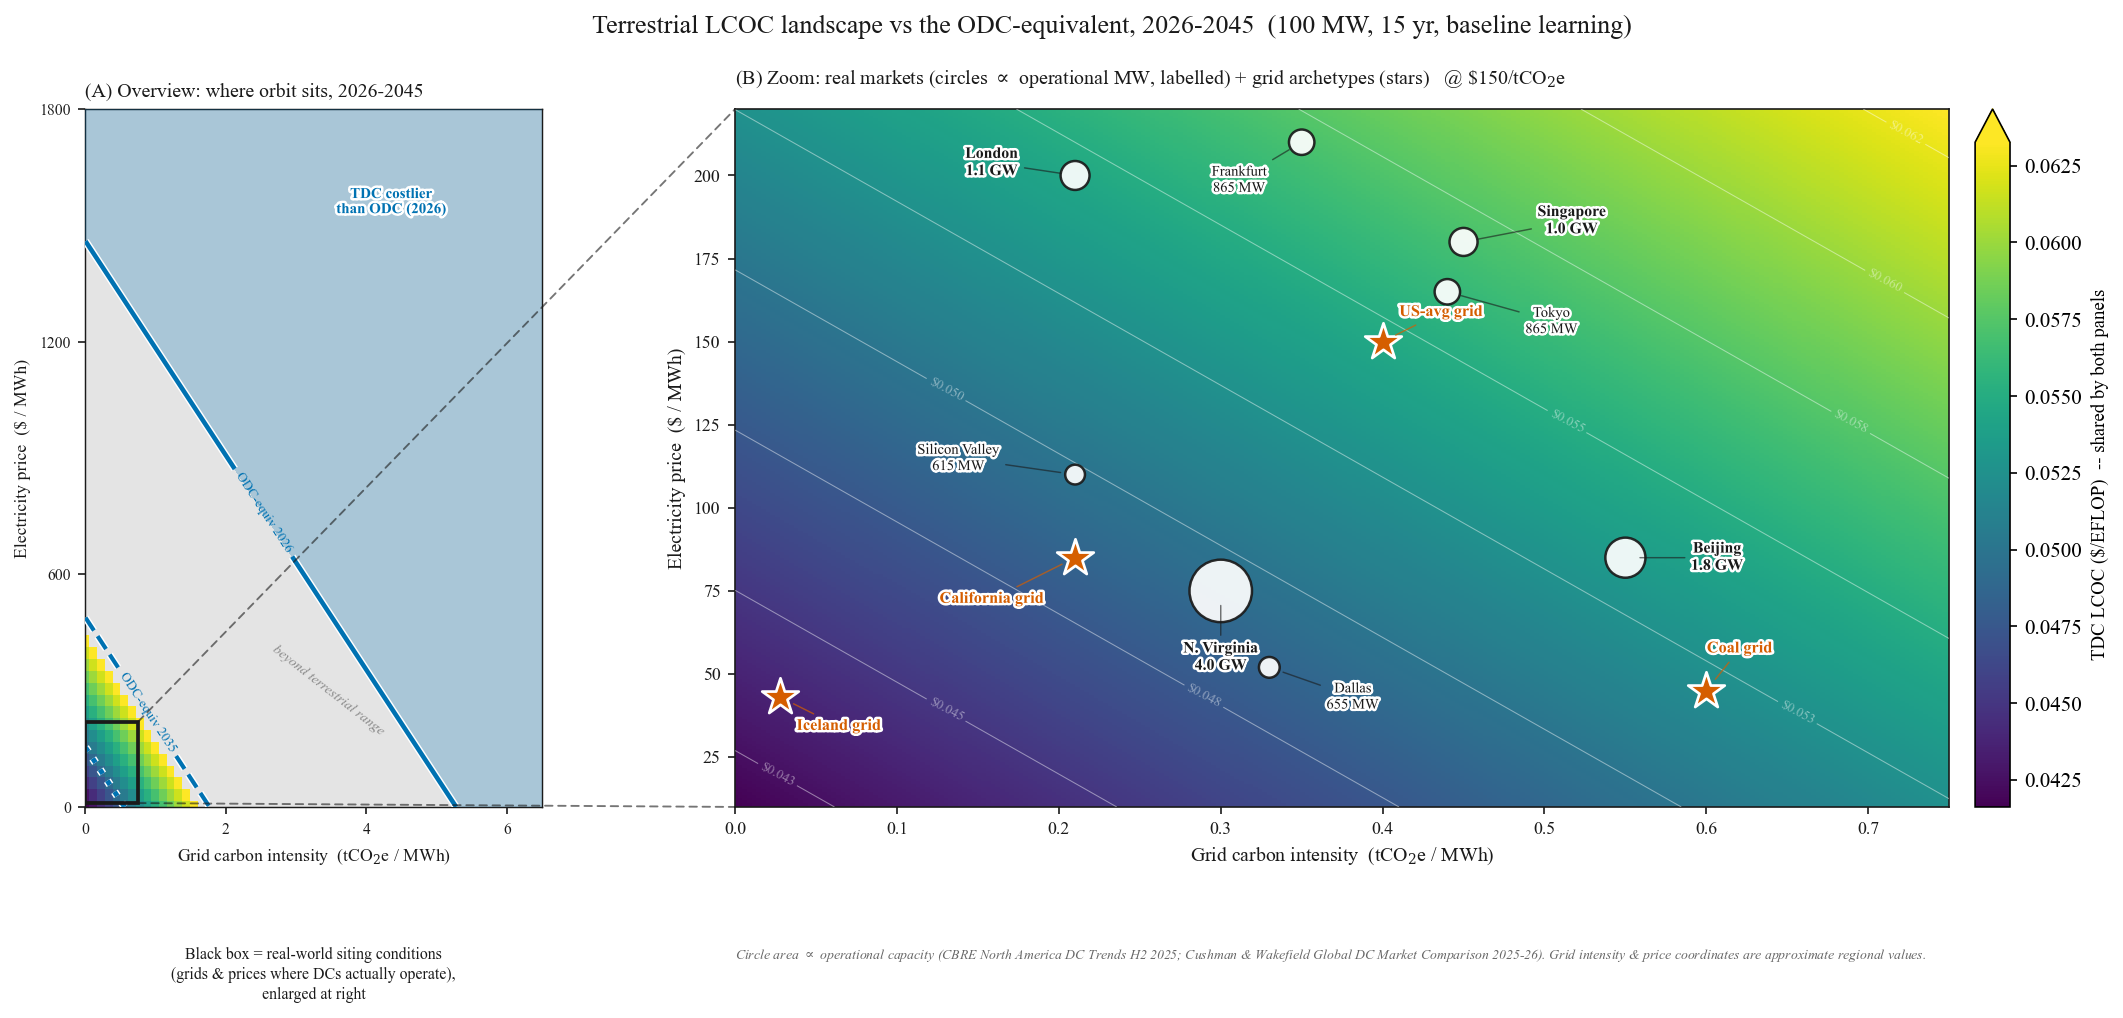

ODC-equivalent (2026) $0.1168/EFLOP ; terrestrial (zoom) range $0.0416-$0.0633/EFLOP
  2026: ODC-equivalent $0.1168/EFLOP  -> on-plane
  2035: ODC-equivalent $0.0140/EFLOP  -> on-plane
  2045: ODC-equivalent $0.0016/EFLOP  -> on-plane
  hubs shown (sourced MW): N. Virginia, Beijing, London, Singapore, Tokyo, Frankfurt, Dallas, Silicon Valley


In [48]:
# =============================================================================
# FIGURE 1: Terrestrial LCOC over the (grid intensity x electricity price) plane
#   (A) OVERVIEW  -- the SAME map, zoomed OUT so the ODC-equivalent contours fit.
#       Solid blue = 2026 ODC-equivalent (where a TDC is as costly as orbit
#       today); dashed = 2035; dotted = 2045. As the ODC cheapens faster than the
#       TDC under baseline learning, these contours sweep DOWN: by 2045 the
#       break-even has fallen into the price band where real DCs operate.
#   (B) ZOOM      -- the real-world siting corner at full resolution. CIRCLES are
#       real DC markets, sized by SOURCED operational capacity (MW, labelled);
#       STARS are hypothetical grid archetypes (what-if grids, not real markets).
#
# Bubble MW are operational-capacity figures from CBRE North America Data Center
# Trends H2 2025 (N. Virginia) and Cushman & Wakefield Global Data Center Market
# Comparison 2025-26, cross-checked against per-metro power-capacity figures.
# Only markets with a sourced MW are shown as circles (Option A). Their (grid,
# price) COORDINATES use approximate regional grid-carbon-intensity and
# industrial-power-price values (illustrative, not from the capacity source).
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib import colormaps

TAX = CARBON_PRICE
_disc = 1.0 / (1 + BASELINE.discount_rate) ** np.arange(LIFETIME_YR)

_odc_t   = float(odc_carbon_result['total'])
_tdc_emb = float(tdc_carbon(carbon_scenario)['embodied_total'])
_Kop     = (carbon_scenario.it_capacity_mw * carbon_scenario.pue * carbon_scenario.load_factor
            * 8760.0 * carbon_scenario.mission_years)

def _tdc_lcoc_year(P, Gd, yo):
    """TDC LCOC [$/EFLOP] on a (price, grid) mesh, evolved yo yr under baseline."""
    gamma_y = BASELINE.gamma_PFLOPS_per_kW * (1 + LR_BASELINE.gamma_growth) ** yo
    cost = np.array([terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW,
                        it_cost_per_MW=BASELINE.it_cost_per_MW*(1-LR_BASELINE.it_cost)**yo,
                        facility_per_kW=FACILITY_COST_PER_KW*(1-LR_BASELINE.terr_capex)**yo,
                        p_per_MWh=p, k_load=1.0)
                     for p in np.atleast_1d(P[:, 0])])
    cost = (cost * (BASELINE.gamma_PFLOPS_per_kW / gamma_y))[:, None]
    npc_y = (annual_eflop(replace(BASELINE, gamma_PFLOPS_per_kW=gamma_y),
                          k_load=CAPACITY_FACTOR) * _disc).sum()
    return cost + ((_tdc_emb + _Kop * Gd) * TAX) / npc_y

def _odc_scalar_year(yo):
    Bev = evolve_scenario(BASELINE, yo, LR_BASELINE)
    npc_y = (annual_eflop(Bev, k_load=CAPACITY_FACTOR) * _disc).sum()
    return calculate_lcoc(Bev)['lcoc'] + _odc_t * TAX / npc_y

def _tdc_lcoc(P, Gd):
    return _tdc_lcoc_year(P, Gd, 0)

ODC = _odc_scalar_year(0)
YEAR_CONTOURS = [(2026, 0, 'solid', 2.2), (2035, 9, 'dashed', 2.0), (2045, 19, 'dotted', 2.4)]

# ---- windows ----------------------------------------------------------------
ZG = (0.0, 0.75); ZP = (10.0, 220.0)     # zoom: real-world siting
OG = (0.0, 6.5);  OP = (0.0, 1800.0)      # overview

_go = np.linspace(*OG, 60); _po = np.linspace(*OP, 60)
GO, PO = np.meshgrid(_go, _po); LCOC_O = _tdc_lcoc(PO, GO)
_gz = np.linspace(*ZG, 260); _pz = np.linspace(*ZP, 260)
GZ, PZ = np.meshgrid(_gz, _pz); LCOC_Z = _tdc_lcoc(PZ, GZ)
lo, hi = LCOC_Z.min(), LCOC_Z.max()

# ---- SOURCED real DC markets (Option A): (name, MW, grid tCO2e/MWh, price $/MWh)
# MW = operational capacity (CBRE 2025 / Cushman 2025-26 / per-metro power figures)
DC_HUBS = [
    ('N. Virginia',   4040, 0.30,  75),   # CBRE 2025: 4,039.6 MW total inventory
    ('Beijing',       1800, 0.55,  85),   # Cushman: largest APAC, ~1,799 MW
    ('London',        1050, 0.21, 200),   # ~1,053 MW
    ('Singapore',     1000, 0.45, 180),   # Cushman: ~1 GW operational
    ('Tokyo',          865, 0.44, 165),   # ~865 MW
    ('Frankfurt',      865, 0.35, 210),   # ~864 MW
    ('Dallas',         655, 0.33,  52),   # ~654 MW (now larger; conservative)
    ('Silicon Valley', 615, 0.21, 110),   # ~615 MW
]

# ---- hypothetical GRID ARCHETYPES (stars) -- what-if grids, NOT real markets --
ARCH = [('Iceland grid', 0.028, 43), ('California grid', 0.21, 85),
        ('US-avg grid',   0.40, 150), ('Coal grid',       0.60, 45)]

HUB_OFF = {'N. Virginia': (0, -32), 'Beijing': (44, 0), 'London': (-40, 6),
           'Singapore': (52, 10), 'Tokyo': (50, -14), 'Frankfurt': (-30, -18),
           'Dallas': (40, -14), 'Silicon Valley': (-56, 8)}
ARCH_OFF = {'Iceland grid': (28, -14), 'California grid': (-40, -20),
            'US-avg grid': (28, 14), 'Coal grid': (16, 20)}

_cap = np.array([h[1] for h in DC_HUBS], float)
_sz  = 90 + (_cap - _cap.min()) / (_cap.max() - _cap.min()) * (900 - 90)
_HALO = [pe.withStroke(linewidth=2.4, foreground='white')]

def _mw_lbl(mw):
    return f'{mw/1000:.1f} GW' if mw >= 1000 else f'{mw} MW'

# ---------------------------------------------------------------- figure -----
fig = plt.figure(figsize=(15.2, 6.6)); fig.patch.set_facecolor(BG)
gs  = fig.add_gridspec(1, 2, width_ratios=[0.72, 2.05], wspace=0.22,
                       left=0.050, right=0.905, top=0.86, bottom=0.155)
axO = fig.add_subplot(gs[0, 0]); axZ = fig.add_subplot(gs[0, 1])

# ------------------------------------------------------------- (A) overview --
_cmap_ov = colormaps['viridis'].with_extremes(over='#E4E4E4')
axO.pcolormesh(GO, PO, LCOC_O, cmap=_cmap_ov, vmin=lo, vmax=hi, shading='auto', zorder=2)
axO.text(3.45, 300, 'beyond terrestrial range', ha='center', va='center', fontsize=6.8,
         color='#8A8A8A', fontfamily=FONT, style='italic', zorder=5, rotation=-38)
axO.contourf(GO, PO, LCOC_O, levels=[ODC, 1e9], colors=[ODC_COLOR], alpha=0.26, zorder=3)

_drawn = []
for yr, yo, ls, lw in YEAR_CONTOURS:
    odc_y = _odc_scalar_year(yo); surf = _tdc_lcoc_year(PO, GO, yo)
    if surf.max() < odc_y or surf.min() > odc_y:
        _drawn.append((yr, None, odc_y)); continue
    cy = axO.contour(GO, PO, surf, levels=[odc_y], colors=[ODC_COLOR],
                     linewidths=lw, linestyles=ls, zorder=4)
    cy.set_path_effects([pe.withStroke(linewidth=lw+1.4, foreground='white')])
    _drawn.append((yr, cy, odc_y))
_lab = {2026: 'ODC-equiv 2026', 2035: 'ODC-equiv 2035', 2045: 'ODC-equiv 2045'}
for yr, cy, odc_y in _drawn:
    if cy is not None:
        axO.clabel(cy, fmt=lambda v, s=_lab[yr]: s, fontsize=6.4, inline=True)

axO.text(4.35, 1560, 'TDC costlier\nthan ODC (2026)', ha='center', va='center', fontsize=7.2,
         color=ODC_COLOR, fontfamily=FONT, fontweight='bold', zorder=5, path_effects=_HALO)

# real-world corner box (NO arrow; explained by the caption below + the zoom connectors)
axO.add_patch(Rectangle((ZG[0], ZP[0]), ZG[1]-ZG[0], ZP[1]-ZP[0], fill=False,
                        edgecolor=INK, linewidth=1.8, zorder=6))
axO.set_xlim(*OG); axO.set_ylim(*OP)
axO.set_xlabel(r'Grid carbon intensity  (tCO$_2$e / MWh)', fontsize=8.5, color=INK, fontfamily=FONT)
axO.set_ylabel(r'Electricity price  (\$ / MWh)', fontsize=8.5, color=INK, fontfamily=FONT)
axO.set_title('(A) Overview: where orbit sits, 2026-2045', fontsize=9.5, color=INK,
              fontfamily=FONT, loc='left', pad=6)
axO.tick_params(colors=INK, labelsize=7.5)
axO.set_xticks([0, 2, 4, 6]); axO.set_yticks([0, 600, 1200, 1800])
for s in axO.spines.values(): s.set_color(INK); s.set_linewidth(0.7)

# caption under panel A -- explains the box WITHOUT an arrow
axO.text(0.5, -0.20,
         'Black box = real-world siting conditions\n(grids & prices where DCs actually operate),\nenlarged at right',
         transform=axO.transAxes, ha='center', va='top', fontsize=7.6,
         color=INK, fontfamily=FONT, linespacing=1.35)

# ----------------------------------------------------------------- (B) zoom --
imZ = axZ.pcolormesh(GZ, PZ, LCOC_Z, cmap='viridis', vmin=lo, vmax=hi, shading='auto', zorder=2)
csZ = axZ.contour(GZ, PZ, LCOC_Z, levels=8, colors='white', linewidths=0.5, alpha=0.45, zorder=3)
axZ.clabel(csZ, fmt=lambda v: f'${v:.3f}', fontsize=6.4, inline=True)

axZ.scatter([h[2] for h in DC_HUBS], [h[3] for h in DC_HUBS], s=_sz, facecolor='white',
            edgecolor=INK, linewidth=1.2, alpha=0.92, zorder=6)
for name, mw, g_, p_ in DC_HUBS:
    off = HUB_OFF[name]
    big = mw >= 1000
    axZ.annotate(f'{name}\n{_mw_lbl(mw)}', (g_, p_), xytext=off, textcoords='offset points',
                 fontsize=7.6 if big else 7.0, fontweight='bold' if big else 'normal',
                 color=INK, fontfamily=FONT, ha='center', va='center', zorder=9,
                 path_effects=_HALO,
                 arrowprops=dict(arrowstyle='-', color=INK, lw=0.7, alpha=0.6,
                                 shrinkA=1, shrinkB=7))
for name, g_, p_ in ARCH:
    axZ.scatter([g_], [p_], marker='*', s=340, facecolor=TDC_COLOR, edgecolor='white',
                linewidth=1.3, zorder=7)
    axZ.annotate(name, (g_, p_), xytext=ARCH_OFF[name], textcoords='offset points',
                 fontsize=7.8, color=TDC_COLOR, fontweight='bold', fontfamily=FONT,
                 ha='center', va='center', zorder=9, path_effects=_HALO,
                 arrowprops=dict(arrowstyle='-', color=TDC_COLOR, lw=0.7, alpha=0.7,
                                 shrinkA=1, shrinkB=7))
axZ.set_xlim(*ZG); axZ.set_ylim(*ZP)
axZ.set_xlabel(r'Grid carbon intensity  (tCO$_2$e / MWh)', fontsize=9.5, color=INK, fontfamily=FONT)
axZ.set_ylabel(r'Electricity price  (\$ / MWh)', fontsize=9.5, color=INK, fontfamily=FONT)
axZ.set_title(rf'(B) Zoom: real markets (circles $\propto$ operational MW, labelled) '
              rf'+ grid archetypes (stars)   @ \${TAX:.0f}/tCO$_2$e',
              fontsize=9.6, color=INK, fontfamily=FONT, loc='left', pad=12)
axZ.tick_params(colors=INK, labelsize=8.5)
for s in axZ.spines.values(): s.set_color(INK); s.set_linewidth(0.8)
cb = fig.colorbar(imZ, ax=axZ, pad=0.02, fraction=0.046, extend='max')
cb.set_label(r'TDC LCOC (\$/EFLOP)  -- shared by both panels', fontsize=9, fontfamily=FONT)

# source note under panel B
axZ.text(0.0, -0.20,
         'Circle area $\\propto$ operational capacity (CBRE North America DC Trends H2 2025; '
         'Cushman & Wakefield Global DC Market Comparison 2025-26). '
         'Grid intensity & price coordinates are approximate regional values.',
         transform=axZ.transAxes, ha='left', va='top', fontsize=6.6,
         color='#666666', fontfamily=FONT, style='italic')

for (xa, ya), (xb, yb) in [((ZG[1], ZP[1]), (ZG[0], ZP[1])), ((ZG[1], ZP[0]), (ZG[0], ZP[0]))]:
    fig.add_artist(ConnectionPatch(xyA=(xa, ya), coordsA=axO.transData,
                                   xyB=(xb, yb), coordsB=axZ.transData,
                                   color=INK, lw=0.9, ls=(0, (4, 3)), alpha=0.6, zorder=1))

fig.suptitle('Terrestrial LCOC landscape vs the ODC-equivalent, 2026-2045  (100 MW, 15 yr, baseline learning)',
             fontsize=12.5, color=INK, fontfamily=FONT, y=0.955)
plt.show()

print(f"ODC-equivalent (2026) ${ODC:.4f}/EFLOP ; terrestrial (zoom) range ${lo:.4f}-${hi:.4f}/EFLOP")
for yr, cy, odc_y in _drawn:
    print(f"  {yr}: ODC-equivalent ${odc_y:.4f}/EFLOP  -> {'on-plane' if cy is not None else 'OFF-plane'}")
print(f"  hubs shown (sourced MW): {', '.join(h[0] for h in DC_HUBS)}")

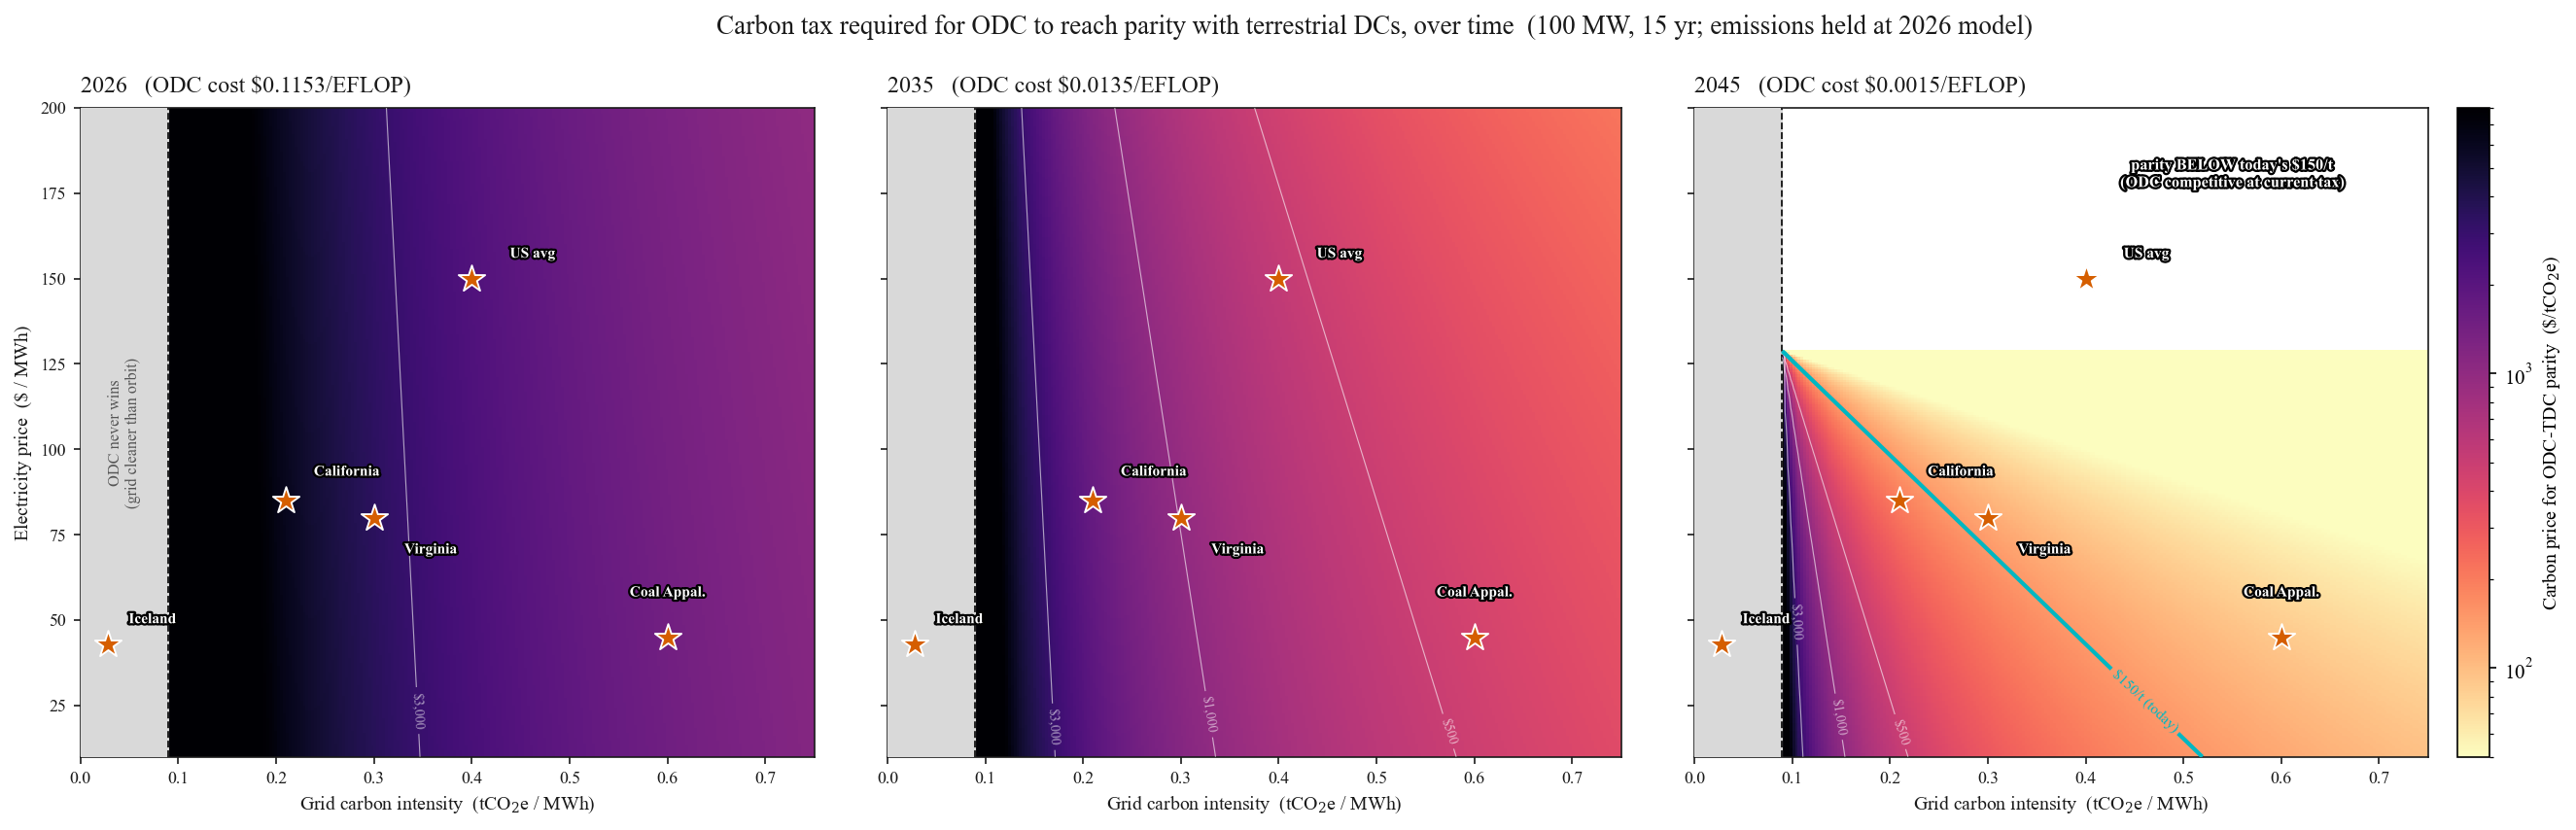

Parity carbon price at archetypes ($/t):
  2026: Iceland:never   California:$6,004   Virginia:$3,472   US:$2,246   Coal:$1,478
  2035: Iceland:never   California:$1,684   Virginia:$983   US:$548   Coal:$445
  2045: Iceland:never   California:$196   Virginia:$126   US:ODC-cheaper   Coal:$89


In [42]:
# =============================================================================
# FIGURE 2: Carbon price for ODC-TDC parity -- 3 snapshots (2026 / 2035 / 2045)
# Break-even $/tCO2e at which orbital LCOC = terrestrial LCOC, over the
# (grid intensity x electricity price) plane. Only techno-economic COSTS evolve
# (launch/PV/IT learning); life-cycle emissions are held at the 2026 model, so
# these parity prices are CONSERVATIVE upper bounds.
#   grey band  : grid so clean that ODC never wins at any carbon price (fixed in time)
#   cyan line  : today's $150/t reference tax -- right of it, parity is already
#                affordable at the current tax (47% of the 2045 map)
# (At the very top of the 2045 panel, p ~ $200/MWh, TDC cost $0.00172 vs ODC $0.00171:
#  ODC is at cost parity with NO tax at all. That is a 2-row sliver at the axis edge,
#  so it is left unshaded rather than drawn as a band.)
#
# CONTOUR FIX: cells where parity <= 0 are set to 0.0 (NOT NaN) before contouring.
# Masking them left a NaN boundary that the $150 contour traced, and filling them
# painted a 2-row band -- together these produced the spurious horizontal line
# across the top of the 2045 panel. Both are gone.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm

_disc = 1.0 / (1 + BASELINE.discount_rate) ** np.arange(LIFETIME_YR)

# ---- carbon totals (2026 model, held fixed across snapshots) -----------------
_odc_t   = float(odc_carbon_result['total'])
_tdc_emb = float(tdc_carbon(carbon_scenario)['embodied_total'])
_Kop     = (carbon_scenario.it_capacity_mw * carbon_scenario.pue * carbon_scenario.load_factor
            * 8760.0 * carbon_scenario.mission_years)
def _tdc_carbon_total(g): return _tdc_emb + _Kop * g
_g_equiv = (_odc_t - _tdc_emb) / _Kop          # grid below which ODC never wins

_G = np.linspace(0.0, 0.75, 260)
_P = np.linspace(10.0, 200.0, 260)
GG, PP = np.meshgrid(_G, _P)

SNAPSHOTS = [('2026', 0), ('2035', 9), ('2045', 19)]
ARCH = [('Iceland', 0.028, 43), ('California', 0.21, 85), ('Virginia', 0.30, 80),
        ('US avg', 0.40, 150), ('Coal Appal.', 0.60, 45)]
ARCH_OFF = {'Iceland': (22, 12), 'California': (30, 14), 'Virginia': (28, -16),
            'US avg': (30, 12), 'Coal Appal.': (0, 22)}
TAX_TODAY = CARBON_PRICE
_HALO = [pe.withStroke(linewidth=2.2, foreground='black')]

def _year_surface(yo):
    """Parity carbon price [$/t] over the plane. NaN where ODC can never win."""
    ev       = evolve_scenario(BASELINE, yo, LR_BASELINE)
    odc_cost = calculate_lcoc(ev)['lcoc']
    npc      = (annual_eflop(ev, k_load=CAPACITY_FACTOR) * _disc).sum()
    gamma_t  = ev.gamma_PFLOPS_per_kW
    facil_t  = FACILITY_COST_PER_KW * (1 - LR_BASELINE.terr_capex) ** yo
    it_t     = BASELINE.it_cost_per_MW * (1 - LR_BASELINE.it_cost) ** yo
    tdc_cost = np.array([terrestrial_lcoc(gamma_t, it_cost_per_MW=it_t,
                                          facility_per_kW=facil_t, p_per_MWh=p)
                         for p in _P])[:, None] * np.ones_like(GG)
    carbon_gap = (_tdc_carbon_total(GG) - _odc_t) / npc      # must be > 0 for parity to exist
    with np.errstate(divide='ignore', invalid='ignore'):
        BE = (odc_cost - tdc_cost) / np.where(carbon_gap > 0, carbon_gap, np.nan)
    return odc_cost, BE

# ---------------------------------------------------------------- figure -----
fig, axes = plt.subplots(1, 3, figsize=(19.5, 6.1), sharey=True)   # wider / less squished
fig.patch.set_facecolor(BG)
fig.subplots_adjust(left=0.045, right=0.905, top=0.86, bottom=0.13, wspace=0.10)
norm = LogNorm(vmin=50, vmax=8000)

im = None
for ax, (yr, yo) in zip(axes, SNAPSHOTS):
    odc_cost, BE = _year_surface(yo)
    # colour surface: only strictly-positive parity prices get a colour
    BEpos = np.where(BE > 0, BE, np.nan)
    im = ax.pcolormesh(GG, PP, np.ma.masked_invalid(BEpos), cmap='magma_r', norm=norm,
                       shading='auto', zorder=2)
    # CONTOUR SOURCE: parity<=0 -> 0.0 (not NaN) so contours don't trace a mask edge
    BEc = np.where(np.isnan(BE), np.nan, np.where(BE <= 0, 0.0, BE))
    BEc = np.ma.masked_invalid(BEc)
    ax.axvspan(0, _g_equiv, color='#D9D9D9', zorder=4)
    ax.axvline(_g_equiv, color=INK, ls='--', lw=0.9, zorder=5)
    cs2 = ax.contour(GG, PP, BEc, levels=[500, 1000, 3000], colors='white',
                     linewidths=0.55, alpha=0.6, zorder=6)
    ax.clabel(cs2, fmt=lambda v: f'${v:,.0f}', fontsize=6.6, inline=True)
    cs = ax.contour(GG, PP, BEc, levels=[TAX_TODAY], colors='#00B7C2', linewidths=2.0, zorder=7)
    ax.clabel(cs, fmt=lambda v: f'${v:.0f}/t (today)', fontsize=7.4, inline=True)
    for name, g_, p_ in ARCH:
        ax.scatter([g_], [p_], marker='*', s=190, facecolor=TDC_COLOR, edgecolor='white',
                   linewidth=0.9, zorder=8)
        ax.annotate(name, (g_, p_), xytext=ARCH_OFF[name], textcoords='offset points',
                    fontsize=7.4, color='white', fontweight='bold', fontfamily=FONT,
                    ha='center', va='center', zorder=9, path_effects=_HALO)
    ax.set_xlim(0, 0.75); ax.set_ylim(10, 200)
    ax.set_xlabel(r'Grid carbon intensity  (tCO$_2$e / MWh)', fontsize=9.5, color=INK, fontfamily=FONT)
    ax.set_title(f'{yr}   (ODC cost ${odc_cost:.4f}/EFLOP)', fontsize=11.5, color=INK,
                 fontfamily=FONT, loc='left', pad=8)
    ax.tick_params(colors=INK, labelsize=8.5)
    for s in ax.spines.values(): s.set_color(INK); s.set_linewidth(0.8)

axes[0].set_ylabel(r'Electricity price  (\$ / MWh)', fontsize=9.5, color=INK, fontfamily=FONT)
axes[0].text(_g_equiv / 2, 105, 'ODC never wins\n(grid cleaner than orbit)', ha='center',
             va='center', fontsize=7.8, color='#555', fontfamily=FONT, rotation=90, zorder=6)
axes[2].text(0.55, 185, 'parity BELOW today\'s \$150/t\n(ODC competitive at current tax)', ha='center',
             va='top', fontsize=7.8, color='white', fontweight='bold', fontfamily=FONT, zorder=9,
             path_effects=_HALO)

cb = fig.colorbar(im, ax=axes, pad=0.012, fraction=0.028)
cb.set_label(r'Carbon price for ODC-TDC parity  (\$/tCO$_2$e)', fontsize=9.5, fontfamily=FONT)
fig.suptitle('Carbon tax required for ODC to reach parity with terrestrial DCs, over time  '
             '(100 MW, 15 yr; emissions held at 2026 model)',
             fontsize=13, color=INK, fontfamily=FONT, y=0.965)
plt.show()

print("Parity carbon price at archetypes ($/t):")
for yr, yo in SNAPSHOTS:
    _, BE = _year_surface(yo)
    row = []
    for name, g_, p_ in ARCH:
        b = BE[np.abs(_P - p_).argmin(), np.abs(_G - g_).argmin()]
        row.append(f"{name.split()[0]}:" + ("never" if np.isnan(b)
                   else ("ODC-cheaper" if b <= 0 else f"${b:,.0f}")))
    print(f"  {yr}: " + "   ".join(row))

MINIMUM LEARNING RATES FOR ODC/TDC PARITY   (TDC held at: facility -2.0%/yr, $150/MWh)

Baseline sits at stretch s = launch: 0.50, pv_cost: 0.50, pv_eff_pp: 0.50, it_mass_dens: 0.60
Baseline ratio in 2045          : 0.950  (parity by 2045 is a RELAXATION problem)
Earliest achievable parity year : 2036  (ratio 0.991 at the optimistic corner)
  -> at 2036 the feasible set is a single corner point: ZERO slack.

--------------------------------------------------------------------------------------------
(A) SOLO-CARRY THRESHOLDS -- parity by 2036   (other three levers at BASELINE)
--------------------------------------------------------------------------------------------
lever                           baseline      required  stretch s*   impl. LR/doubling  verdict
Launch cost decline           12.00 %/yr            --          --                  --  INFEASIBLE alone (even at 4x optimistic)
PV areal cost decline          6.00 %/yr    15.56 %/yr       1.695               45.6%  BEYOND opt

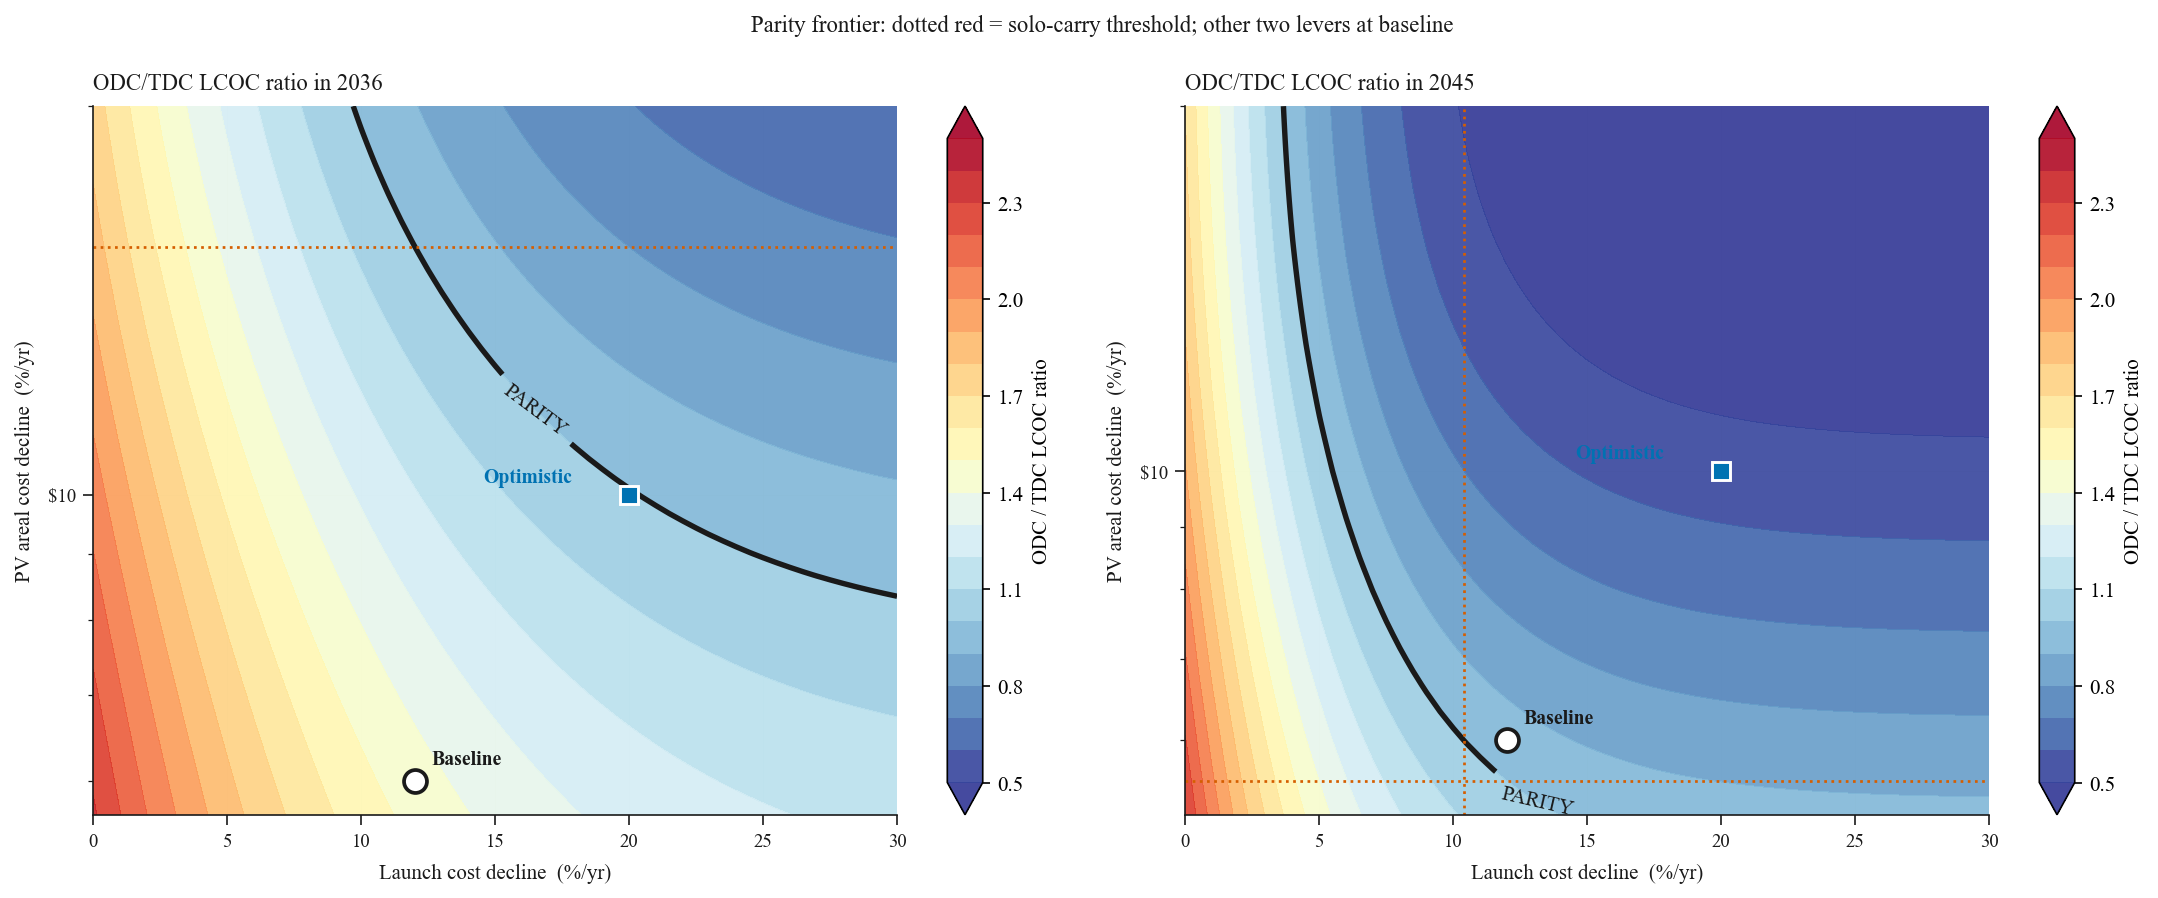

In [43]:
# =============================================================================
# 11. MINIMUM LEARNING RATES REQUIRED FOR ODC/TDC PARITY
# -----------------------------------------------------------------------------
# The set of learning-rate vectors achieving parity by year Y is a REGION whose
# boundary is a hypersurface; "the lowest combination" is undefined until you
# choose a norm on effort. We report three standard scalarizations and let their
# agreement (or disagreement) be the result.
#
#   (A) SOLO-CARRY  : one lever does all the work, other three at baseline.
#                     Classic TEA break-even / cost-target backcast.
#   (B) UNIFORM STRETCH (L-inf): all four levers tied to one scalar s, where
#                     s=0 is pessimistic, s=1 is optimistic. Bisect for min s*.
#   (C) L2 / L1 MINIMUM-EFFORT: lowest-norm point on the parity surface, with
#                     effort measured from s=0 (no learning at all).
#
# ONLY FOUR LEVERS CAN MOVE THE RATIO. gamma_growth and it_cost are shared by
# construction and cancel exactly; terr_capex and elec_price are TDC-side;
# rad_cost is zero. The ratio is monotone decreasing in all four, so the frontier
# is exact by bisection -- no grid search, and no need for PRIM/scenario
# discovery (which earns its keep only on non-monotone response surfaces).
# =============================================================================
from scipy.optimize import brentq, minimize

ODC_LEVERS = ['launch', 'pv_cost', 'pv_eff_pp', 'it_mass_dens']
LEVER_LABEL = {
    'launch':       'Launch cost decline',
    'pv_cost':      'PV areal cost decline',
    'pv_eff_pp':    'PV BOL efficiency gain',
    'it_mass_dens': 'IT mass density decline',
}
LEVER_UNIT = {'launch': '%/yr', 'pv_cost': '%/yr',
              'pv_eff_pp': 'pp/yr', 'it_mass_dens': '%/yr'}
# Wright doubling cadence tau [yr/doubling] from Section 3, for the implied
# progress-ratio column. None = no experience-curve root.
LEVER_TAU = {'launch': 1.3, 'pv_cost': 3.6, 'pv_eff_pp': None, 'it_mass_dens': None}

PES = {k: getattr(LR_PESSIMISTIC, k) for k in ODC_LEVERS}
OPT = {k: getattr(LR_OPTIMISTIC,  k) for k in ODC_LEVERS}
BAS = {k: getattr(LR_BASELINE,    k) for k in ODC_LEVERS}
S_BASE = {k: (BAS[k] - PES[k]) / (OPT[k] - PES[k]) for k in ODC_LEVERS}

# The TDC stance is HELD FIXED. Every number below is conditional on it.
TDC_STANCE = LR_BASELINE          # terr_capex = 2%/yr, elec_price = $150/MWh
S_MAX = 4.0                       # allow up to 4x beyond the optimistic bound

_START = globals().get('START_YEAR', 2026)


def _lr(vals, tdc=None):
    """Build a LearningRates from the 4 ODC levers + a fixed TDC stance."""
    tdc = tdc or TDC_STANCE
    return LearningRates(
        name='probe', rad_cost=0.0, it_cost=IT_COST_LR,
        gamma_growth=LR_BASELINE.gamma_growth,        # cancels in the ratio
        launch=vals['launch'], pv_cost=vals['pv_cost'],
        pv_eff_pp=vals['pv_eff_pp'], it_mass_dens=vals['it_mass_dens'],
        terr_capex=tdc.terr_capex, elec_price=tdc.elec_price)


def ratio_at(yo, vals, tdc=None):
    """ODC/TDC LCOC ratio at year offset yo under lever values `vals`."""
    lr = _lr(vals, tdc)
    odc = calculate_lcoc(evolve_scenario(BASELINE, yo, lr))['lcoc']
    return odc / terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr)


def from_stretch(s):
    """s: scalar or dict of stretch in [0,1] (0=pessimistic, 1=optimistic).
    Linearly extrapolated outside [0,1]."""
    if np.isscalar(s):
        s = {k: float(s) for k in ODC_LEVERS}
    return {k: PES[k] + s[k] * (OPT[k] - PES[k]) for k in ODC_LEVERS}


def _bisect_stretch(f, lo=0.0, hi=S_MAX):
    """Smallest s in [lo,hi] with f(s) <= 0 (f monotone decreasing). None if infeasible."""
    if f(lo) <= 0:
        return lo
    if f(hi) > 0:
        return None
    return brentq(f, lo, hi, xtol=1e-6)


def _fmt(k, v):
    return f'{v*100:5.2f} {LEVER_UNIT[k]}' if k != 'pv_eff_pp' else f'{v*100:5.3f} pp/yr'


def _progress_ratio(k, r_yr):
    """Implied Wright LR per doubling at the Section-3 cadence tau.
    REPORT THIS: a calendar rate is learning x deployment speed, not learning."""
    tau = LEVER_TAU[k]
    if tau is None or r_yr <= 0:
        return None
    return 1.0 - (1.0 - r_yr) ** tau


def is_saturated(k, yo):
    """Does this lever still do anything at year offset yo? PV eff caps at 0.35
    (even the PESSIMISTIC rate hits the cap by ~2041 -> dead lever at 2045);
    IT mass floors at IT_MASS_DENSITY_FLOOR."""
    if k == 'pv_eff_pp':
        return BASELINE.pv_eff_BOL + PES[k] * yo >= 0.35
    if k == 'it_mass_dens':
        return BASELINE.it_mass_density * (1 - OPT[k]) ** yo <= IT_MASS_DENSITY_FLOOR
    return False


# =============================================================================
# Step 0: the earliest year parity is achievable at all (optimistic corner).
# The ratio is monotone in every lever, so the earliest crossing under the box
# constraint is achieved ONLY at the optimistic corner -> zero slack by design.
# =============================================================================
_opt_vals = from_stretch(1.0)
YO_EARLIEST = next((yo for yo in range(0, 41) if ratio_at(yo, _opt_vals) <= 1.0), None)
assert YO_EARLIEST is not None, 'Parity unreachable even at the optimistic corner.'
YEAR_EARLIEST = _START + YO_EARLIEST

YO_2045 = 2045 - _START
TARGETS = [(YEAR_EARLIEST, YO_EARLIEST), (2045, YO_2045)]

print('=' * 92)
print('MINIMUM LEARNING RATES FOR ODC/TDC PARITY   (TDC held at: '
      f'facility -{TDC_STANCE.terr_capex*100:.1f}%/yr, ${TDC_STANCE.elec_price:.0f}/MWh)')
print('=' * 92)
print('\nBaseline sits at stretch s = '
      + ', '.join(f'{k}: {S_BASE[k]:.2f}' for k in ODC_LEVERS))
print(f'Baseline ratio in 2045          : {ratio_at(YO_2045, BAS):.3f}  '
      f'(parity by 2045 is a RELAXATION problem)')
print(f'Earliest achievable parity year : {YEAR_EARLIEST}  '
      f'(ratio {ratio_at(YO_EARLIEST, _opt_vals):.3f} at the optimistic corner)')
print(f'  -> at {YEAR_EARLIEST} the feasible set is a single corner point: ZERO slack.\n')

# =============================================================================
# (A) SOLO-CARRY: one lever does all the work, other three pinned at baseline
# =============================================================================
solo = {}
for year, yo in TARGETS:
    print('-' * 92)
    print(f'(A) SOLO-CARRY THRESHOLDS -- parity by {year}   (other three levers at BASELINE)')
    print('-' * 92)
    print(f'{"lever":<26} {"baseline":>13} {"required":>13} {"stretch s*":>11} '
          f'{"impl. LR/doubling":>19}  verdict')
    solo[year] = {}
    for k in ODC_LEVERS:
        sat = is_saturated(k, yo)

        def f(s, k=k):
            v = dict(BAS)
            v[k] = PES[k] + s * (OPT[k] - PES[k])
            return ratio_at(yo, v) - 1.0

        s_star = None if sat else _bisect_stretch(f)
        if sat:
            verdict, req, pr = 'SATURATED (lever is dead by this year)', None, None
        elif s_star is None:
            verdict, req, pr = f'INFEASIBLE alone (even at {S_MAX:.0f}x optimistic)', None, None
        else:
            req = PES[k] + s_star * (OPT[k] - PES[k])
            pr = _progress_ratio(k, req)
            if s_star <= S_BASE[k]:
                verdict = 'reachable BELOW baseline'
            elif s_star <= 1.0:
                verdict = 'inside the credible band'
            else:
                verdict = f'BEYOND optimistic ({s_star:.2f}x)'
        solo[year][k] = (s_star, req)
        print(f'{LEVER_LABEL[k]:<26} {_fmt(k, BAS[k]):>13} '
              f'{(_fmt(k, req) if req is not None else "--"):>13} '
              f'{(f"{s_star:.3f}" if s_star is not None else "--"):>11} '
              f'{(f"{pr*100:.1f}%" if pr else "--"):>19}  {verdict}')
    print()

# =============================================================================
# (B) UNIFORM STRETCH (L-inf): all four levers tied to one scalar s
# =============================================================================
print('=' * 92)
print('(B) UNIFORM-STRETCH MINIMUM  --  all four levers at the SAME percentile of '
      'their credible band')
print('=' * 92)
uni = {}
for year, yo in TARGETS:
    s_star = _bisect_stretch(lambda s: ratio_at(yo, from_stretch(s)) - 1.0)
    uni[year] = s_star
    if s_star is None:
        print(f'{year}: INFEASIBLE even at {S_MAX:.0f}x optimistic on all levers.')
        continue
    v = from_stretch(s_star)
    tag = ('BELOW baseline (slack exists)' if s_star < min(S_BASE.values())
           else 'inside the band' if s_star <= 1.0 else 'BEYOND optimistic')
    print(f'\n{year}:  s* = {s_star:.3f}   [{tag}]   '
          f'(baseline s ~ {np.mean(list(S_BASE.values())):.2f}, optimistic s = 1.0)')
    for k in ODC_LEVERS:
        note = '   <-- SATURATED, value is irrelevant' if is_saturated(k, yo) else ''
        print(f'    {LEVER_LABEL[k]:<26} {_fmt(k, v[k])}{note}')
    print(f'    -> ratio at {year}: {ratio_at(yo, v):.4f}')

# =============================================================================
# (C) MINIMUM-EFFORT POINTS: L2 (balanced) and L1 (corner)
#     Effort is measured from the PESSIMISTIC corner (s=0 = no learning at all),
#     NOT from baseline -- we want the LOWEST learning rates that still cross,
#     which is a minimum-norm problem, not a nearest-point problem.
#         L-inf  -> (B) above: min of max_i s_i. All live levers end up equal.
#         L2     -> balanced interior point on the parity surface.
#         L1     -> corner solution: names the single most cost-effective lever.
#     Saturated levers are pinned at s=0 (zero effort, zero benefit).
# =============================================================================
print('\n' + '=' * 92)
print('(C) MINIMUM-EFFORT POINTS ON THE PARITY SURFACE  (effort measured from '
      's=0 = no learning)')
print('=' * 92)
for year, yo in TARGETS:
    live = [k for k in ODC_LEVERS if not is_saturated(k, yo)]
    dead = [k for k in ODC_LEVERS if k not in live]

    def unpack(x, live=live):
        v = {k: PES[k] for k in ODC_LEVERS}          # dead levers -> zero effort
        for k, xi in zip(live, x):
            v[k] = PES[k] + xi * (OPT[k] - PES[k])
        return v

    con = [{'type': 'ineq', 'fun': lambda x, live=live: 1.0 - ratio_at(yo, unpack(x, live))}]
    bnds = [(0.0, S_MAX)] * len(live)
    x0 = np.full(len(live), min(1.0, uni[year] if uni[year] else 1.0))

    for norm, obj in [('L2 (balanced)', lambda x: float(np.sum(x ** 2))),
                      ('L1 (corner)',   lambda x: float(np.sum(x)))]:
        r = minimize(obj, x0, method='SLSQP', bounds=bnds, constraints=con,
                     options={'maxiter': 400, 'ftol': 1e-10})
        v = unpack(r.x)
        ok = ratio_at(yo, v) <= 1.0 + 1e-4
        print(f'\n{year}  --  {norm}   [{"parity met" if ok else "CONSTRAINT MISSED"}]'
              + (f'   dead levers pinned at zero effort: {", ".join(dead)}' if dead else ''))
        for k in ODC_LEVERS:
            xi = dict(zip(live, r.x)).get(k, 0.0)
            note = ('  <-- SATURATED, irrelevant' if k in dead else
                    '  <-- lever does the work' if xi > 0.9 * max(list(r.x) + [1e-9]) else '')
            print(f'    {LEVER_LABEL[k]:<26} {_fmt(k, v[k])}   s={xi:.3f}'
                  f'  (baseline s={S_BASE[k]:.2f}){note}')
        print(f'    -> ratio at {year}: {ratio_at(yo, v):.4f}')
        if norm.startswith('L2') and uni[year] is not None:
            spread = float(max(r.x) - min(r.x))
            print(f'    Robustness: L-inf gives s*={uni[year]:.3f} uniformly; L2 lever '
                  f'spread = {spread:.3f}  ->  '
                  + ('ROBUST (no single lever carries parity)' if spread < 0.15
                     else 'the model RIDES one lever -- say which in the paper'))

# =============================================================================
# (D) 2-D PARITY FRONTIER: the two dominant levers, other two at baseline
# =============================================================================
gl = np.linspace(0.0, 0.30, 61)     # launch decline  %/yr
gp = np.linspace(0.0, 0.20, 61)     # PV cost decline %/yr
GL, GP = np.meshgrid(gl, gp)

fig, axes = plt.subplots(1, len(TARGETS), figsize=(7.4 * len(TARGETS), 6.0))
fig.patch.set_facecolor(BG)
for ax, (year, yo) in zip(np.atleast_1d(axes), TARGETS):
    R = np.zeros_like(GL)
    for i in range(GL.shape[0]):
        for j in range(GL.shape[1]):
            v = dict(BAS); v['launch'] = GL[i, j]; v['pv_cost'] = GP[i, j]
            R[i, j] = ratio_at(yo, v)
    cf = ax.contourf(GL * 100, GP * 100, R, levels=np.linspace(0.5, 2.5, 21),
                     cmap='RdYlBu_r', extend='both', alpha=0.9)
    cs = ax.contour(GL * 100, GP * 100, R, levels=[1.0], colors=[INK], linewidths=2.6)
    ax.clabel(cs, fmt={1.0: 'PARITY'}, fontsize=10)
    ax.plot(BAS['launch'] * 100, BAS['pv_cost'] * 100, 'o', ms=11, color='white',
            markeredgecolor=INK, markeredgewidth=1.8, zorder=6)
    ax.annotate('Baseline', (BAS['launch'] * 100, BAS['pv_cost'] * 100),
                xytext=(8, 8), textcoords='offset points', fontsize=9.5,
                fontfamily=FONT, color=INK, fontweight='bold')
    ax.plot(OPT['launch'] * 100, OPT['pv_cost'] * 100, 's', ms=9, color=ODC_COLOR,
            markeredgecolor='white', markeredgewidth=1.4, zorder=6)
    ax.annotate('Optimistic', (OPT['launch'] * 100, OPT['pv_cost'] * 100),
                xytext=(-70, 6), textcoords='offset points', fontsize=9.5,
                fontfamily=FONT, color=ODC_COLOR, fontweight='bold')
    if solo[year]['launch'][1] is not None:
        ax.axvline(solo[year]['launch'][1] * 100, color=ACCENT_R, ls=':', lw=1.3)
    if solo[year]['pv_cost'][1] is not None:
        ax.axhline(solo[year]['pv_cost'][1] * 100, color=ACCENT_R, ls=':', lw=1.3)
    style_axes(ax, fig, title=f'ODC/TDC LCOC ratio in {year}',
               xlabel='Launch cost decline  (%/yr)',
               ylabel='PV areal cost decline  (%/yr)')
    ax.grid(alpha=0.25, color=GRID, lw=0.4)
    fig.colorbar(cf, ax=ax, label='ODC / TDC LCOC ratio')
fig.suptitle('Parity frontier: dotted red = solo-carry threshold; other two levers at baseline',
             fontsize=11, color=INK, fontfamily=FONT, y=0.99)
plt.tight_layout()
plt.show()

# 10. Summary

In [44]:
print('=' * 96)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)')
print('=' * 96)
print(f'\nBaseline ODC parameters (locked initial values, 2026):')
print(f'  gamma           = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW')
print(f'  Launch          = ${BASELINE.launch_cost_per_kg:,.0f}/kg')
print(f'  PV eta_BOL      = {BASELINE.pv_eff_BOL}')
print(f'  PV areal cost   = ${BASELINE.pv_areal_cost:,.0f}/m^2')
print(f'  Rad areal cost  = ${BASELINE.rad_areal_cost:,.0f}/m^2')
print(f'  IT cost         = ${BASELINE.it_cost_per_MW/1e6:.1f}M/MW')
print(f'  alpha_solar     = {BASELINE.alpha_solar_rad}')
print(f'  alpha_IR        = {BASELINE.eps_IR}')
print(f'\nLearning-rate scenarios drive the uncertainty band on plots.')
print()

print(f'{"Year":>6s}  |   {"ODC range $/EFLOP":>32s}     {"TDC range $/EFLOP":>32s}  |  ratio')
print(f'{"":>6s}  |   {"(pes / base / opt)":>32s}     {"(pes / base / opt)":>32s}  |  (base)')
print('-' * 96)
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    odc_range = f'${odc_lo[idx]:.4f} / ${odc_nom[idx]:.4f} / ${odc_hi[idx]:.4f}'
    tdc_range = f'${tdc_lo[idx]:.4f} / ${tdc_nom[idx]:.4f} / ${tdc_hi[idx]:.4f}'
    print(f'{label:>6s}  |   {odc_range:>32s}     {tdc_range:>32s}  |  {odc_nom[idx]/tdc_nom[idx]:.2f}x')

print()
print('Cost breakdown for 2026 baseline ODC:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

print()
print('Key takeaways:')
print('  - Initial parameter values are locked; only the learning rate varies.')
print('  - Launch cost decline drives the ODC trajectory; under baseline LR, launch falls')
print('    below ~$200/kg by 2045, narrowing the gap to TDC substantially.')
print('  - gamma improvement applies to both ODC and TDC equally and shifts both curves')
print('    down in parallel - it does not by itself close the ODC/TDC gap.')
print('  - Compute efficiency (gamma) is the single largest sensitivity, followed by')
print('    PV BOL efficiency, launch cost and PV areal cost ($23,500/m^2).')
print('    Launch is NO LONGER the top lever. See the carbon-inclusive tornado.')

SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)

Baseline ODC parameters (locked initial values, 2026):
  gamma           = 6.0 PFLOPS/kW
  Launch          = $1,500/kg
  PV eta_BOL      = 0.32
  PV areal cost   = $23,500/m^2
  Rad areal cost  = $231/m^2
  IT cost         = $23.0M/MW
  alpha_solar     = 0.05
  alpha_IR        = 0.95

Learning-rate scenarios drive the uncertainty band on plots.

  Year  |                  ODC range $/EFLOP                    TDC range $/EFLOP  |  ratio
        |                 (pes / base / opt)                   (pes / base / opt)  |  (base)
------------------------------------------------------------------------------------------------
  2026  |        $0.1153 / $0.1153 / $0.1153          $0.0539 / $0.0487 / $0.0461  |  2.37x
  2030  |        $0.0548 / $0.0440 / $0.0361          $0.0260 / $0.0226 / $0.0207  |  1.94x
  2035  |        $0.0219 / $0.0135 / $0.0095          $0.0108 / $0.0089 / $0.0077  |  1.52x
  2040  |        $0.0088 / $0.0044 / $0.0